# 0. Setup

In [1]:
# !pip install krippendorff

In [2]:
import pandas as pd
import os 
import json
import re
import copy
import json


def load_json(filename):
    """
    Load a JSON file given a filename
    If the file doesn't exist, then return an empty dictionary instead
    """
    try:
        with open(filename, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        return {}

def write_json(data, filepath):
    # assert isinstance(data, dict), '[ERROR] Expect dictionary data!'
    json_data = data
    if isinstance(data, dict):
        json_data = {str(k): data[k] for k in data} # convert deys into str
    json_string = json.dumps(json_data, indent = 4)
    with open(filepath, 'w') as outfile:
        outfile.write(json_string)

In [3]:
import krippendorff
from sklearn.metrics import cohen_kappa_score, accuracy_score
from statsmodels.stats.inter_rater import fleiss_kappa as sm_fleiss_kappa
from statsmodels.stats.inter_rater import aggregate_raters

In [4]:
def intter_annotator_agreement(mturk_df, col, annotator_col='WorkerId', hidid_col = 'HITId'):
    """Compute inter-annotator agreement using Cohen's Kappa."""
    
    annotators = mturk_df[annotator_col].unique()
    print('Annotators:', annotators)
    if len(annotators) < 2:
        print("Not enough annotators to compute agreement.")
        return None  # Not enough annotators to compute agreement
    scores = []
    for i in range(len(annotators)):
        for j in range(i + 1, len(annotators)):
            ann_i = mturk_df[mturk_df[annotator_col] == annotators[i]][[col, hidid_col]].set_index(hidid_col)
            ann_j = mturk_df[mturk_df[annotator_col] == annotators[j]][[col, hidid_col]].set_index(hidid_col)
            # print(ann_i.shape, ann_j.shape)
            # display(ann_i.head())
            common_indices = ann_i.index.intersection(ann_j.index)
            # print(common_indices[:4])
            if len(common_indices) > 0:

                kappa = cohen_kappa_score(ann_i.loc[common_indices], ann_j.loc[common_indices])
                scores.append(round(kappa, 2))
                acc = round(accuracy_score(ann_i.loc[common_indices], ann_j.loc[common_indices]), 2)
                print(annotators[i], annotators[j], len(common_indices), round(kappa, 2), acc)
                
                print('---')
    if scores:
        return sum(scores) / len(scores)
    else:
        print("No valid scores to compute agreement.")
        return None

import numpy as np

def fleiss_cuzick(table, weights=None, weight_type="quadratic", **kwargs):
    """
    Generalized weighted multi-rater kappa (Fleiss-Cuzick style).

    Parameters
    ----------
    table : array-like, shape (N_items, N_categories)
        Contingency table where table[i, j] is the number of raters
        who assigned item i to category j.
    weights : array-like, shape (N_categories, N_categories), optional
        Symmetric weight matrix w_{jk} in [0, 1], where 1 = perfect agreement
        and 0 = complete disagreement. If None, a weight matrix is constructed
        from `weight_type`.
    weight_type : {"linear", "quadratic", "identity"}, default="quadratic"
        - "identity": nominal categories (equivalent to unweighted Fleiss)
        - "linear":   linear weights (Cohen-style)
        - "quadratic":quadratic weights (Cohen-style)
    **kwargs :
        Ignored. Included so you can call this as a drop-in replacement for
        statsmodels.stats.inter_rater.fleiss_kappa(table, method=...).

    Returns
    -------
    kappa_w : float
        Weighted multi-rater kappa.
    """
    table = np.asarray(table, dtype=float)
    n_items, n_cat = table.shape

    # Total ratings per item
    n_ratings_per_item = table.sum(axis=1)

    # Build default weight matrix if not provided
    if weights is None:
        # indices 0..k-1 are treated as ordinal levels with equal spacing
        i = np.arange(n_cat)
        jj, kk = np.meshgrid(i, i)
        d = np.abs(jj - kk)

        if weight_type == "identity":
            weights = (jj == kk).astype(float)
        elif weight_type == "linear":
            # w_ij = 1 - |i-j| / (k-1)
            denom = max(n_cat - 1, 1)
            weights = 1.0 - d / denom
        elif weight_type == "quadratic":
            # w_ij = 1 - (i-j)^2 / (k-1)^2
            denom = max(n_cat - 1, 1)
            weights = 1.0 - (d ** 2) / (denom ** 2)
        else:
            raise ValueError(f"Unknown weight_type: {weight_type}")
    else:
        weights = np.asarray(weights, dtype=float)
        if weights.shape != (n_cat, n_cat):
            raise ValueError("weights must have shape (n_categories, n_categories)")

    # ---------- Observed weighted agreement ----------
    # For each item i, we consider all ordered pairs of ratings with weights w_{jk}.
    P_i = []
    for row, n_i in zip(table, n_ratings_per_item):
        if n_i <= 1:
            # Can't form pairs; skip this item
            continue

        # counts_{jk}: number of ordered pairs (r1, r2) with categories j,k
        # Off-diagonal: n_j * n_k
        # Diagonal:     n_j * (n_j - 1)
        counts = np.outer(row, row)
        # fix diagonal to n_j (n_j - 1)
        np.fill_diagonal(counts, row * (row - 1))

        # Weighted sum of agreements for this item
        num_i = np.sum(weights * counts)
        den_i = n_i * (n_i - 1)
        P_i.append(num_i / den_i)

    if len(P_i) == 0:
        return np.nan

    P_bar = np.mean(P_i)

    # ---------- Expected weighted agreement ----------
    # Marginal probabilities of each category across all ratings
    total_ratings = n_ratings_per_item.sum()
    p = table.sum(axis=0) / total_ratings

    # Expected agreement: sum_{j,k} w_{jk} p_j p_k
    expected_counts = np.outer(p, p)
    P_e = np.sum(weights * expected_counts)

    # ---------- Weighted kappa ----------
    if np.isclose(1.0 - P_e, 0):
        return np.nan

    kappa_w = (P_bar - P_e) / (1.0 - P_e)
    return kappa_w



# fliess kappa
# def fleiss_kappa(mturk_df, col, annotator_col='WorkerId', hitid_col = 'HITId', method = 'fleiss'): 
#     """Compute Fleiss' Kappa for multiple annotators."""
    
#     # Create a contingency table
#     contingency_table = mturk_df.pivot_table(index=hitid_col, columns=col, aggfunc='size', fill_value=0)
#     # display(contingency_table)
#     # Convert to the format required by statsmodels
#     ratings_matrix = contingency_table.values

#     # Compute Fleiss' Kappa
#     kappa = sm_fleiss_kappa(ratings_matrix, method=method)
#     return kappa, contingency_table

def fleiss_kappa(mturk_df, col, hitid_col='HITId',
                 method='fleiss', use_weighted=False, weight_type='quadratic'):
    """Compute (weighted) Fleiss-style Kappa for multiple annotators."""
    contingency_table = mturk_df.pivot_table(
        index=hitid_col,
        columns=col,
        aggfunc='size',
        fill_value=0
    )
    ratings_matrix = contingency_table.values

    if use_weighted:
        kappa = fleiss_cuzick(ratings_matrix, weight_type=weight_type)
    else:
        kappa = sm_fleiss_kappa(ratings_matrix, method=method)

    return kappa, contingency_table


def get_rating_metrix(mturk_df, col, hitid_col = 'HITId'):
    ratings = []
    for hitid in mturk_df[hitid_col].unique():
        item_ratings = mturk_df[mturk_df[hitid_col] == hitid][col].tolist()
        if len(item_ratings) > 3 and hitid_col == 'Input.problem_id': # for creathive math, limit to 3 annotators
            item_ratings = item_ratings[:3]  # Limit to first 3 annotators for consistency
        ratings.append(item_ratings)
    return ratings

# Krippendorff alpha
def krippendorff_alpha(mturk_df, col, hitid_col = 'HITId'):
    """Compute Krippendorff's Alpha for multiple annotators."""

    # Compute Krippendorff's Alpha
    # print(ratings)
    alpha = krippendorff.alpha(reliability_data=get_rating_metrix(mturk_df, col, hitid_col), level_of_measurement='nominal')
    return alpha 

# 1. Human Agreement

## 1.1. Creative Math

In [22]:
version_list = [
    # 'v3.0', 
    'v2.1',
    # 'v2.0'
]
creative_math = pd.concat([
    pd.read_csv(
        '../data/mturk_anno/creative_math/{version}/{filename}'.format(version=version, filename=f)
    )
    for version in version_list
    for f in os.listdir('../data/mturk_anno/creative_math/{version}/'.format(version=version)) if f.endswith('.csv')
])

exclude_problem_ids = [
    "2009_AMC_10B_Problems_14",  # problematic annotations
    "2015_USAJMO_Problems_6",  # problem is truncated
]

creative_math = copy.deepcopy(creative_math.loc[~creative_math['Input.problem_id'].isin(exclude_problem_ids)])
# remove worker AKERE2HC8Y7H4
# creative_math = creative_math.loc[creative_math['WorkerId'] != "AKERE2HC8Y7H4"]

creative_math['correctness_label'] = creative_math['Answer.correctness.correct'].apply(lambda x: 1 if x else 0)
creative_math['novelty_label'] = creative_math['Answer.novelty.novel'].apply(lambda x: 1 if x else 0)

creative_math.shape

(146, 42)

In [23]:
# creative_math.groupby('Input.problem_id')['correctness_label'].sum()

In [24]:
creative_math.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate', 'Input.problem_id',
       'Input.problem', 'Input.cleaned_references', 'Input.cleaned_response',
       'Input.model', 'Input.image_in_problem', 'Answer.correctness.correct',
       'Answer.correctness.incorrect', 'Answer.novelty.not_novel',
       'Answer.novelty.novel', 'Answer.worker_feedbacks', 'Approve', 'Reject',
       'correctness_label', 'novelty_label'],
      dtype='object')

In [25]:
# creative_math['edited'].sum(), creative_math['too simple'].sum()

In [26]:
creative_math.WorkerId.unique()

array(['AFA0H6QL832IJ', 'A189Q7EDEDSQ34', 'ASQIP0BTUIBHO'], dtype=object)

In [27]:
# print(creative_math['Input.problem'].iloc[0])

In [28]:
# print(creative_math['Input.problem_id'])

In [29]:
id_alvin = 'AFA0H6QL832IJ'
id_joey = 'ASQIP0BTUIBHO'
id_johnny = 'A189Q7EDEDSQ34'

In [30]:
creative_math.query('WorkerId == @id_alvin').shape

(49, 42)

In [31]:
creative_math.query('WorkerId == "AKERE2HC8Y7H4"').shape

(0, 42)

In [32]:
creative_math['Input.problem_id'].nunique()

49

In [33]:
creative_math.query('WorkerId == @id_joey').shape

(49, 42)

In [34]:
creative_math_subset = copy.deepcopy(creative_math.query('WorkerId in [@id_johnny, @id_joey]'))
creative_math_subset.shape

(97, 42)

In [35]:
overlap_ids = list(creative_math_subset.groupby('Input.problem_id')[['WorkerId']].agg('count').query('WorkerId > 1').index)
len(overlap_ids)

48

In [36]:
# creative_math_subset.loc[creative_math_subset['Input.problem_id'].isin(overlap_ids) & creative_math_subset['WorkerId'].isin([id_joey, id_johnny])][['Input.problem_id', 'Answer.novelty.novel']].groupby('Input.problem_id').agg(sum)

In [37]:
# overlap_ids

In [38]:
# intter_annotator_agreement(creative_math, 'correctness_label')

In [22]:
# intter_annotator_agreement(creative_math, 'novelty_label')

In [23]:
# creative_math['correctness_label']

In [24]:
creative_math.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate', 'Input.problem_id',
       'Input.problem', 'Input.cleaned_references', 'Input.cleaned_response',
       'Input.model', 'Input.image_in_problem', 'Answer.correctness.correct',
       'Answer.correctness.incorrect', 'Answer.novelty.not_novel',
       'Answer.novelty.novel', 'Answer.worker_feedbacks', 'Approve', 'Reject',
       'correctness_label', 'novelty_label'],
      dtype='object')

In [25]:
# keep only first two annotations for each problemid 
# creative_math = creative_math.sort_values(by=['Input.problem_id', 'WorkerId'])
# creative_math = creative_math.groupby('Input.problem_id').head(2).reset_index(drop=True)
# creative_math

In [29]:
# creative_math['correctness_label']

### 1.1.1 Correctness

In [25]:
# kappa, contingency_table = fleiss_kappa(creative_math, 'correctness_label', hitid_col='Input.problem_id')
# # int((contingency_table[1] == 3).sum()), float(kappa)
# kappa

In [26]:
# disagree_ids = list(contingency_table[contingency_table[1] < 3].index)
# # disagree_ids

# creative_math_disagree = creative_math[creative_math['HITId'].isin(disagree_ids)][['HITId', 'Input.problem', 'Input.cleaned_references', 'Input.cleaned_response', 'Answer.correctness.correct']]#.drop_duplicates()
# creative_math_disagree.shape

In [27]:
# correctness_count = dict(creative_math_disagree[['HITId', 'Answer.correctness.correct']].groupby('HITId').agg('sum')['Answer.correctness.correct'])

In [28]:
# creative_math_disagree['correctness_count'] = creative_math_disagree['HITId'].apply(lambda x: correctness_count[x])
# creative_math_disagree[['HITId', 'Input.problem', 'Input.cleaned_references', 'Input.cleaned_response', 'correctness_count']].drop_duplicates().shape

In [29]:
# creative_math_disagree = creative_math_disagree[['HITId', 'Input.problem', 'Input.cleaned_references', 'Input.cleaned_response', 'correctness_count']].drop_duplicates()
# creative_math_disagree.to_csv('../data/mturk_anno/creative_math/correctness_disagreements.csv', index=False)

In [85]:
creative_math_disagree_annotated = pd.read_csv('../data/mturk_anno/creative_math/correctness_disagreements_annotated.csv')
creative_math_disagree_annotated.shape

(9, 5)

In [86]:
creative_math_disagree_annotated.columns

Index(['HITId', 'Input.problem', 'Input.cleaned_response', 'correctness_count',
       'correctness'],
      dtype='object')

In [87]:
# creative_math_disagree_annotated
creative_math.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate', 'Input.problem_id',
       'Input.problem', 'Input.cleaned_references', 'Input.cleaned_response',
       'Input.image_in_problem', 'Answer.correctness.correct',
       'Answer.correctness.incorrect', 'Answer.novelty.not_novel',
       'Answer.novelty.novel', 'Approve', 'Reject', 'Answer.worker_feedbacks',
       'Input.model', 'edited', 'too simple', 'correctness_label',
       'novelty_label'],
      dtype='object')

In [88]:
# creative_math_disagree_annotated
# correctness_map = lambda x: 'correct' if x not in 


In [89]:
correctness_map = dict(zip(creative_math_disagree_annotated['Input.cleaned_response'], creative_math_disagree_annotated['correctness']))
correctness_map_full = dict(creative_math[['Input.problem_id', 'Input.cleaned_response', 'correctness_label']].groupby('Input.cleaned_response').apply(
    lambda df: correctness_map[df['Input.cleaned_response'].iloc[0]] if df['Input.cleaned_response'].iloc[0] in correctness_map else df['correctness_label'].mode().iloc[0]
))
creative_math['correctness_label_final'] = creative_math['Input.cleaned_response'].apply(lambda x: correctness_map_full[x] if x in correctness_map_full else -1)

In [90]:
creative_math['correctness_label_final'].sum(), creative_math.shape[0]

(177, 221)

In [91]:
creative_math[['Input.problem_id', 'Input.cleaned_response', 'correctness_label_final']].drop_duplicates().to_csv('../data/mturk_anno/creative_math/correctness_final_labels_v2.csv', index=False)

### 1.1.2 Novelty

In [39]:
# int((contingency_table[1] == 3).sum()) + int((contingency_table[0] == 3).sum())

In [40]:
# for every problem id, only keep the first three annotations
creative_math_cleaned = creative_math.sort_values(
    by=['Input.problem_id', 'WorkerId']
).groupby('Input.problem_id').head(3).reset_index(drop=True)
# creative_math_cleaned = creative_math_cleaned.loc[creative_math_cleaned['too simple'] != 1.0]
creative_math_cleaned.shape

(146, 42)

In [41]:
# keep only problems with at least 3 annotations
creative_math_cleaned = creative_math_cleaned.groupby('Input.problem_id').filter(lambda x: x.shape[0] >= 3)
creative_math_cleaned.shape

(144, 42)

In [42]:
kappa, contingency_table = fleiss_kappa(creative_math_cleaned, 'novelty_label', hitid_col='Input.problem_id')
float(round(kappa, 4))

0.4515

In [45]:
creative_math_cleaned['Input.problem_id'].value_counts()

Input.problem_id
1954_AHSME_Problems_38      3
1962_AHSME_Problems_11      3
2006_AMC_12B_Problems_22    3
2008_AIME_II_Problems_1     3
2008_IMO_Problems_5         3
2010_AIME_II_Problems_4     3
2010_USAJMO_Problems_2      3
2010_USAMO_Problems_6       3
2011_AIME_I_Problems_12     3
2012_AIME_II_Problems_11    3
2013_USAJMO_Problems_2      3
2014_AMC_10A_Problems_3     3
2016_AMC_10A_Problems_16    3
2016_AMC_8_Problems_6       3
2018_USAJMO_Problems_5      3
2019_AMC_8_Problems_20      3
2020_AMC_10A_Problems_1     3
2021_USAJMO_Problems_4      3
2022_AMC_12A_Problems_9     3
2023_AMC_12A_Problems_23    3
2023_AMC_12B_Problems_4     3
2023_USAJMO_Problems_5      3
2024_USAJMO_Problems_3      3
2006_AMC_12B_Problems_10    3
2004_USAMO_Problems_6       3
2003_AMC_8_Problems_18      3
1994_AJHSME_Problems_20     3
1964_AHSME_Problems_40      3
1979_AHSME_Problems_13      3
1984_AHSME_Problems_22      3
1984_AIME_Problems_9        3
1986_AJHSME_Problems_6      3
1987_AIME_Problems_11  

In [43]:
# contingency_table

In [125]:
creative_math.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate', 'Input.problem_id',
       'Input.problem', 'Input.cleaned_references', 'Input.cleaned_response',
       'Input.model', 'Input.image_in_problem', 'Answer.correctness.correct',
       'Answer.correctness.incorrect', 'Answer.novelty.not_novel',
       'Answer.novelty.novel', 'Answer.worker_feedbacks', 'Approve', 'Reject',
       'correctness_label', 'novelty_label'],
      dtype='object')

In [ ]:
# # creative_math_expanded = creative_math.copy()
# # Select relevant columns
# columns_to_keep = [
#     'Input.problem_id', 
#     'Input.problem', 
#     'Input.cleaned_response', 
#     'Input.cleaned_references', 
#     'WorkerId', 
#     'Answer.novelty.novel', 
#     'Answer.novelty.not_novel'
# ]
# df_subset = creative_math[columns_to_keep].copy()

# # Determine the annotation value
# def get_annotation(row):
#     if row['Answer.novelty.novel']:
#         return 'Novel'
#     elif row['Answer.novelty.not_novel']:
#         return 'Not Novel'
#     else:
#         return None

# df_subset['annotation'] = df_subset.apply(get_annotation, axis=1)

# # Drop the raw answer columns
# df_subset = df_subset.drop(columns=['Answer.novelty.novel', 'Answer.novelty.not_novel'])

# # Pivot the table to get one row per problem and columns for each worker
# pivot_index = ['Input.problem_id', 'Input.problem', 'Input.cleaned_response', 'Input.cleaned_references']
# df_pivot = df_subset.pivot_table(index=pivot_index, columns='WorkerId', values='annotation', aggfunc='first')

# # Reset index and rename columns
# df_final = df_pivot.reset_index()
# rename_map = {
#     'Input.problem_id': 'problem_id',
#     'Input.problem': 'problem',
#     'Input.cleaned_response': 'proposed_solution',
#     'Input.cleaned_references': 'reference_solution'
# }
# df_final = df_final.rename(columns=rename_map)
# df_final.to_csv('../data/mturk_anno/creative_math/novelty_annotations.csv', index=False)

In [70]:
# contingency_table

In [127]:
# alpha_novelty = krippendorff_alpha(creative_math, 'novelty_label', hitid_col='Input.problem_id')
# float(round(alpha_novelty, 4))

In [498]:
# multi_label_ids = []
# agree_correctness = []
# agree_novelty = []
# for i in creative_math['Input.problem_id'].unique():
#     tmp_df = creative_math.loc[creative_math['Input.problem_id'] == i]
#     if tmp_df.shape[0] > 1:
#         # display(creative_math[creative_math['Input.problem_id'] == i])
#         multi_label_ids.append(i)
#         if tmp_df['correctness_label'].values[0] == tmp_df['correctness_label'].values[1]:
#             agree_correctness.append(1)
#         if tmp_df['novelty_label'].values[0] == tmp_df['novelty_label'].values[1]:
#             agree_novelty.append(1)

# len(multi_label_ids), sum(agree_correctness), sum(agree_novelty)

In [129]:
# creative_math['Answer.correctness.correct'].unique()

In [168]:
tmp_data = pd.read_csv(
    '../data/mturk_anno/creative_math/{filename}'.format(filename = 'c-math-0-17.csv')
)
tmp_data.WorkerId.nunique()

4

In [169]:
tmp_data.groupby('WorkerId').size()

WorkerId
A189Q7EDEDSQ34    18
AFA0H6QL832IJ      9
AKERE2HC8Y7H4     15
ASQIP0BTUIBHO     11
dtype: int64

In [171]:
tmp_data.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate', 'Input.problem_id',
       'Input.problem', 'Input.cleaned_references', 'Input.cleaned_response',
       'Input.model', 'Input.image_in_problem', 'Answer.correctness.correct',
       'Answer.correctness.incorrect', 'Answer.novelty.not_novel',
       'Answer.novelty.novel', 'Approve', 'Reject'],
      dtype='object')

array(['ASQIP0BTUIBHO', 'A189Q7EDEDSQ34'], dtype=object)

## 1.2. TTCT

In [46]:
version = 'v1.1'

subset = ['2.{i}.csv'.format(i=i) for i in [1, 2, 3, 4, 5]]
# worker_subset = [
#     # 'AKERE2HC8Y7H4', 
#     'AZ30QEAHQKQJ2', # wanzhou 
#     'AYLFOVFYHTV0C' # janet
# ]

# ttct_mturk = pd.concat([
#     pd.read_csv(
#         '../data/mturk_anno/ttct/{version}/{filename}'.format(version=version, filename = f)
#     ) 
#     for f in os.listdir(f'../data/mturk_anno/ttct/{version}/') if f.endswith('.csv') # and f in subset
# ])
ttct_mturk = []
reference_data = []
for f in os.listdir(f'../data/mturk_anno/ttct/{version}/'):
    if f.endswith('.csv'):
        df_tmp = pd.read_csv(
            '../data/mturk_anno/ttct/{version}/{filename}'.format(version=version, filename = f)
        )
        if f in subset:
            # df_tmp = df_tmp[df_tmp['WorkerId'].isin(worker_subset)]
            pass
        else:
            reference_data.append(df_tmp)
        ttct_mturk.append(df_tmp)
        print(f, df_tmp.shape)

ttct_mturk = pd.concat(ttct_mturk)
reference_data = pd.concat(reference_data)

# ttct_input = pd.concat([
#     pd.read_csv(
#         '../data/mturk_input/ttct/{version}/{filename}'.format(version=version, filename = f)
#     )
#     for f in os.listdir(f'../data/mturk_input/ttct/{version}/') if f.endswith('.csv') and f in os.listdir(f'../data/mturk_anno/ttct/{version}/')
# ])
ttct_input = pd.read_csv('../data/mturk_input/ttct/v1.0/ttct_full_data.csv')
ttct_mturk.shape, ttct_input.shape

2.8.csv (21, 54)
2.9.csv (21, 54)
2.7.csv (20, 54)
2.6.csv (21, 54)
2.4.csv (20, 54)
2.5.csv (20, 54)
2.1.csv (21, 54)
2.2.csv (20, 54)
2.3.csv (21, 54)


((185, 54), (63, 9))

In [47]:
reference_data.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate',
       'Input.infer_cot_input', 'Input.infer_cot_pred', 'Input.rubric',
       'Answer.elaboration.1', 'Answer.elaboration.2', 'Answer.elaboration.3',
       'Answer.elaboration.4', 'Answer.elaboration.5', 'Answer.flexibility.1',
       'Answer.flexibility.2', 'Answer.flexibility.3', 'Answer.flexibility.4',
       'Answer.flexibility.5', 'Answer.fluency.1', 'Answer.fluency.2',
       'Answer.fluency.3', 'Answer.fluency.4', 'Answer.fluency.5',
       

In [48]:
trait_rating = {'originality': [], 'flexibility': [], 'elaboration': [], 'fluency': []}
for trait in trait_rating:
    for i, row in reference_data.iterrows():
        for j in range(1, 6):
            if row['Answer.{}.{}'.format(trait, j)]:
                trait_rating[trait].append(j)
                found = True
                break
        if not found:
            trait_rating[trait].append(None)
    # reference_data[trait + '_label'] = reference_data['Answer.{trait}.label'.format(trait=trait)].apply(lambda x: 1 if x == 'high' else 0)
    reference_data[trait + '_label'] = trait_rating[trait]
reference_data = reference_data[['Input.infer_cot_pred', 'originality_label', 'flexibility_label', 'elaboration_label', 'fluency_label']].dropna()
reference_data['Input.infer_cot_pred'] = reference_data['Input.infer_cot_pred'].apply(lambda x: x.strip()[:100])

# reference_data.to_csv('../data/mturk_anno/ttct/reference_data.csv', index=False)

In [49]:
# reference_data

In [50]:
ttct_mturk['Input.infer_cot_pred'].nunique()

62

In [51]:
# pd.read_csv('../data/mturk_anno/ttct/v1.0/2.1.csv')['WorkerId'].unique()

In [52]:
(ttct_input.infer_cot_pred + ttct_input.infer_cot_input).nunique()

62

In [53]:
ttct_input.columns

Index(['infer_cot_input', 'infer_cot_pred', 'eval_cot_input', 'eval_cot_pred',
       'source_file', 'question_type', 'rubric', 'ttct_id', 'tmp_id'],
      dtype='object')

In [54]:
# ttct_input.dropna().infer_cot_pred.nunique()

In [55]:
ttct_mturk.shape

(185, 54)

In [56]:
ttct_mturk_merged = ttct_mturk.merge(
    ttct_input,
    left_on='Input.infer_cot_pred',
    right_on='infer_cot_pred'
).drop_duplicates()

In [57]:
# ttct_mturk_merged.head()

In [58]:
ttct_mturk.HITId.nunique()

63

In [59]:
# ttct_mturk_merged['eval_cot_pred'].isna().sum()

In [60]:
ttct_mturk_merged.shape

(185, 63)

In [61]:
q2id = {q: i for i, q in enumerate(ttct_mturk_merged['Input.infer_cot_pred'].unique())}
ttct_mturk_merged['_id'] = ttct_mturk_merged['Input.infer_cot_pred'].apply(lambda x: q2id[x])
ttct_mturk_merged.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate',
       'Input.infer_cot_input', 'Input.infer_cot_pred', 'Input.rubric',
       'Answer.elaboration.1', 'Answer.elaboration.2', 'Answer.elaboration.3',
       'Answer.elaboration.4', 'Answer.elaboration.5', 'Answer.flexibility.1',
       'Answer.flexibility.2', 'Answer.flexibility.3', 'Answer.flexibility.4',
       'Answer.flexibility.5', 'Answer.fluency.1', 'Answer.fluency.2',
       'Answer.fluency.3', 'Answer.fluency.4', 'Answer.fluency.5',
       

In [62]:
# ttct_mturk_merged.dropna().shape

In [63]:
trait_rating = {
    'fluency': [], 
    'flexibility': [], 
    'originality': [], 
    'elaboration': [], 
    # 'overall': []
}
trait_pred = {
    'fluency': [], 
    'flexibility': [], 
    'originality': [], 
    'elaboration': [], 
    # 'overall': []
}
for trait in trait_rating.keys():
    for i, row in ttct_mturk_merged.iterrows():
        # extract mturk annotations
        found = False
        for j in range(1, 6):
            if row['Answer.{}.{}'.format(trait, j)]:
                trait_rating[trait].append(j)
                found = True
                break
        if not found:
            trait_rating[trait].append(None)

        # extract llm judge predictions
        if 'eval_cot_pred' in row and not pd.isna(row['eval_cot_pred']):
            text = row['eval_cot_pred']
        else:
            text = ''

        pattern = r'([A-Za-z]+):\s*(\d+)'
        matches = re.findall(pattern, text)
        # try:
        #     matches = re.findall(pattern, text)
        # except:
        #     print("Error in regex matching for text:", text)
        # print(matches)
        found = False
        for tmp_trait, rating in matches:
            if tmp_trait.lower().strip() == trait.lower().strip():
                trait_pred[trait].append(int(rating))
                found = True
                break
        if not found:
            trait_pred[trait].append(None)
    ttct_mturk_merged[trait + '_mturk'] = trait_rating[trait]
    ttct_mturk_merged[trait + '_llmj'] = trait_pred[trait]

In [64]:
# ttct_mturk_merged

In [65]:
# intter_annotator_agreement(ttct_mturk_merged, 'fluency_mturk')

In [66]:
required_annotations = 3
# find out ids with only two annotations
ids_2_keep = []
for i in range(len(ttct_mturk_merged['_id'].unique())):
    tmp_df = ttct_mturk_merged.query('_id == @i')
    if tmp_df.shape[0] >= required_annotations:
        ids_2_keep.append(i)


# keep only ids_2_keep
ttct_mturk_merged = ttct_mturk_merged[ttct_mturk_merged['_id'].isin(ids_2_keep)]
ttct_mturk_merged.shape

# ttct_mturk_merged.groupby('Input.infer_cot_pred').agg('count')

(177, 72)

In [67]:
len(ids_2_keep)

59

In [68]:
def combinations(n, r):
    """Generate all combinations of r elements from a set of n elements."""
    if r == 0:
        yield []
    else:
        for i in range(n):
            for cc in combinations(n - i - 1, r - 1):
                yield [i] + [c + i + 1 for c in cc]
                
def keep_only_two_annotations(tmp_df, required_annotations = 2):
    # if worker_ids is not None:
    #     tmp_df = tmp_df[tmp_df['WorkerId'].isin(worker_ids)]
    return tmp_df.iloc[:required_annotations]
    # combination_dists = {}
    # for row_combination in combinations(tmp_df.shape[0], 2):
    #     total_dist = 0
    #     for col in tmp_df.columns:
    #         if '_mturk' in col:
    #             total_dist += abs(tmp_df.iloc[row_combination[0]][col] - tmp_df.iloc[row_combination[1]][col])
    #     combination_dists[tuple(row_combination)] = total_dist
    # best_combination = min(combination_dists, key=combination_dists.get)
    # return tmp_df.iloc[list(best_combination)]

In [69]:
# there are 118 unique problems with at least two annotations, keeping only two annotations per problem for inter-annotator agreement calculation
ttct_mturk_merged_final = pd.DataFrame()

for i in ttct_mturk_merged['_id'].unique():
    tmp_df = ttct_mturk_merged.query('_id == @i')
    # ttct_mturk_merged_final = pd.concat([ttct_mturk_merged_final, tmp_df.iloc[:required_annotations]])
    # ttct_mturk_merged_final = pd.concat([ttct_mturk_merged_final, keep_only_two_annotations(tmp_df)])
    ttct_mturk_merged_final = pd.concat([ttct_mturk_merged_final, keep_only_two_annotations(tmp_df, required_annotations = required_annotations)])
ttct_mturk_merged_final.shape

(177, 72)

In [70]:
ttct_mturk_merged.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate',
       'Input.infer_cot_input', 'Input.infer_cot_pred', 'Input.rubric',
       'Answer.elaboration.1', 'Answer.elaboration.2', 'Answer.elaboration.3',
       'Answer.elaboration.4', 'Answer.elaboration.5', 'Answer.flexibility.1',
       'Answer.flexibility.2', 'Answer.flexibility.3', 'Answer.flexibility.4',
       'Answer.flexibility.5', 'Answer.fluency.1', 'Answer.fluency.2',
       'Answer.fluency.3', 'Answer.fluency.4', 'Answer.fluency.5',
       

In [71]:
# ttct_mturk_merged.columns

In [72]:
# print(ttct_mturk_merged[['_id', 'fluency_mturk', 'fluency_mturk_smooth', 'Input.infer_cot_pred']].query('_id == 4')['Input.infer_cot_pred'].values[0])

In [73]:
# ttct_mturk_merged['question_type'].value_counts()

In [74]:
def run_fleiss_kappa_for_ttct(ttct_data, use_weighted=True, weight_type='quadratic'):
    all_results = []
    for trait in ['fluency', 'flexibility', 'originality', 'elaboration']:
        kappa, contingency_table = fleiss_kappa(ttct_data, '{}_mturk'.format(trait), use_weighted=use_weighted, weight_type=weight_type)
        all_results.append({
            'trait': trait, 'kappa': kappa
        })
    return pd.DataFrame(all_results)

In [75]:
avg_kappas = {}
for question_type in ttct_mturk_merged['question_type'].unique():
    kappa_results = run_fleiss_kappa_for_ttct(ttct_mturk_merged_final.query(f'question_type == "{question_type}"'), use_weighted=True, weight_type='quadratic')
    display(kappa_results)
    avg_kappas[question_type] = kappa_results['kappa'].mean()
    print("Question type:", question_type, 'average kappa:', avg_kappas[question_type])
    print('---')
print("sorted average kappas:", sorted(avg_kappas.items(), key=lambda x: x[1], reverse=True))

,trait,kappa
0,fluency,0.298246
1,flexibility,0.367728
2,originality,-0.018182
3,elaboration,0.095559


Question type: 6_improvement average kappa: 0.18583752849153054
---


,trait,kappa
0,fluency,-0.175510
1,flexibility,0.158598
2,originality,-0.282137
3,elaboration,-0.012245


Question type: 7_story average kappa: -0.07782358352355946
---


,trait,kappa
0,fluency,0.045455
1,flexibility,0.142857
2,originality,-0.210435
3,elaboration,0.238731


...

Question type: 1_unusual_uses average kappa: 0.5300751056012547
---


,trait,kappa
0,fluency,0.211125
1,flexibility,0.126050
2,originality,0.185714
3,elaboration,0.400000


Question type: 5_common_problems average kappa: 0.23072246597754145
---


,trait,kappa
0,fluency,0.014199
1,flexibility,0.082524
2,originality,0.035714
3,elaboration,0.177419


Question type: 2_consequences average kappa: 0.07746417383978006
---
sorted average kappas: [('4_situation', np.float64(0.5351434368069249)), ('1_unusual_uses', np.float64(0.5300751056012547)), ('5_common_problems', np.float64(0.23072246597754145)), ('6_improvement', np.float64(0.18583752849153054)), ('2_consequences', np.float64(0.07746417383978006)), ('3_just_suppose', np.float64(0.05415203110020558)), ('7_story', np.float64(-0.07782358352355946))]


In [108]:
ttct_mturk_merged['question_type'].unique()

array(['6_improvement', '7_story', '3_just_suppose', '4_situation',
       '1_unusual_uses', '5_common_problems', '2_consequences'],
      dtype=object)

In [76]:
problem_type_subset = ['1_unusual_uses', '5_common_problems', '4_situation', '6_improvement', '2_consequences']

ttct_mturk_merged_final_filtered = copy.deepcopy(ttct_mturk_merged_final[ttct_mturk_merged_final['question_type'].isin(problem_type_subset)])
ttct_mturk_merged_final_filtered.shape

(129, 72)

In [77]:
# GitHub Copilot

# Summarize the kept subset and its inter-annotator agreement
kappa_results_filtered = run_fleiss_kappa_for_ttct(ttct_mturk_merged_final_filtered, use_weighted=True, weight_type='quadratic')
avg_kappa_filtered = kappa_results_filtered['kappa'].mean()

subset_types = ttct_mturk_merged_final_filtered['question_type'].unique().tolist()
n_items = ttct_mturk_merged_final_filtered['_id'].nunique()
n_rows = len(ttct_mturk_merged_final_filtered)

desc_lines = [
    "Subset description:",
    f"- Version: {version}",
    f"- Question types kept: {', '.join(subset_types)}",
    f"- Items with ≥2 annotations: {n_items} (rows: {n_rows})",
    "Agreement (weighted Fleiss-style kappa, ordinal 1–5):",
]
for _, row in kappa_results_filtered.iterrows():
    desc_lines.append(f"- {row['trait'].capitalize()}: {row['kappa']:.3f}")

desc_lines.append(f"- Average across traits: {avg_kappa_filtered:.3f}")

report_summary = "\n".join(desc_lines)
print(report_summary)

Subset description:
- Version: v1.1
- Question types kept: 6_improvement, 4_situation, 1_unusual_uses, 5_common_problems, 2_consequences
- Items with ≥2 annotations: 43 (rows: 129)
Agreement (weighted Fleiss-style kappa, ordinal 1–5):
- Fluency: 0.432
- Flexibility: 0.423
- Originality: 0.331
- Elaboration: 0.445
- Average across traits: 0.408


In [78]:
run_fleiss_kappa_for_ttct(ttct_mturk_merged_final_filtered, use_weighted=True, weight_type='quadratic')

,trait,kappa
0,fluency,0.431953
1,flexibility,0.422948
2,originality,0.330767
3,elaboration,0.444611


In [79]:
ttct_mturk_merged_final_filtered.infer_cot_pred.nunique()

42

In [101]:
ttct_mturk_merged_final_filtered.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate',
       'Input.infer_cot_input', 'Input.infer_cot_pred', 'Input.rubric',
       'Answer.elaboration.1', 'Answer.elaboration.2', 'Answer.elaboration.3',
       'Answer.elaboration.4', 'Answer.elaboration.5', 'Answer.flexibility.1',
       'Answer.flexibility.2', 'Answer.flexibility.3', 'Answer.flexibility.4',
       'Answer.flexibility.5', 'Answer.fluency.1', 'Answer.fluency.2',
       'Answer.fluency.3', 'Answer.fluency.4', 'Answer.fluency.5',
       

In [102]:
ttct_mturk_merged_final_filtered['skip'] = 0
ttct_eval_test_input = ttct_mturk_merged_final_filtered[['infer_cot_input', 'infer_cot_pred', 'source_file', 'question_type','skip']].drop_duplicates()
ttct_eval_test_input.shape

(43, 5)

In [81]:
ttct_eval_test_input['infer_cot_input'].nunique()

15

In [447]:
basefile = pd.read_csv('../data/mturk_anno/ttct/basefile.csv')
basefile['unique_id'] = range(basefile.shape[0])
basefile.shape

for source in ttct_eval_test_input['source_file'].unique():
    tmp_base = copy.deepcopy(basefile)
    tmp_base['skip'] = tmp_base.apply(lambda x: 0 if x['infer_cot_input'] in ttct_eval_test_input['infer_cot_input'].values else 1, axis=1)
    print(tmp_base['skip'].sum())
    # tmp_base.to_csv('../data/mturk_anno/ttct/{version}_llmj_input/{source}'.format(version=version, source=source), index=False)
    # print(source, ttct_eval_test_input[ttct_eval_test_input['source_file'] == source].shape[0])
# ttct_eval_test_input

685
685
685


In [455]:
ttct_input2id = {q: i for i, q in enumerate(basefile['infer_cot_input'].unique())}
# ttct_mturk_merged_final_filtered['infer_cot_input'].nunique()
ttct_mturk_merged_final_filtered['_id'] = ttct_mturk_merged_final_filtered\
    .apply(lambda row: "{}-{}".format(ttct_input2id[row['infer_cot_input']], row['question_type']), axis=1)
# ttct_mturk_merged_final_filtered[['infer_cot_input', 'infer_cot_pred', '_id']].drop_duplicates().shape

In [456]:
ttct_mturk_merged_final_filtered.to_csv(
    '../data/mturk_anno/ttct/{version}_llmj_input/ttct_mturk_merged_final_filtered.csv'.format(version=version),
    index=False
)

- **Sample Demostrations**

In [457]:
ttct_mturk_merged_final_filtered.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate',
       'Input.infer_cot_input', 'Input.infer_cot_pred', 'Input.rubric',
       'Answer.elaboration.1', 'Answer.elaboration.2', 'Answer.elaboration.3',
       'Answer.elaboration.4', 'Answer.elaboration.5', 'Answer.flexibility.1',
       'Answer.flexibility.2', 'Answer.flexibility.3', 'Answer.flexibility.4',
       'Answer.flexibility.5', 'Answer.fluency.1', 'Answer.fluency.2',
       'Answer.fluency.3', 'Answer.fluency.4', 'Answer.fluency.5',
       

In [485]:
demo_source = ttct_mturk_merged_final_filtered[[
    '_id', 'infer_cot_input', 'infer_cot_pred', 'question_type', 'source_file',
    'fluency_mturk', 'flexibility_mturk', 'originality_mturk', 'elaboration_mturk' 
]]
demo_avg = demo_source.groupby(['_id', 'source_file'])[
    ['fluency_mturk', 'flexibility_mturk', 'originality_mturk', 'elaboration_mturk' ]].agg(np.mean).round()
demo_avg['question_type'] = demo_source.groupby(['_id', 'source_file'])['question_type'].first()
demo_avg['infer_cot_input'] = demo_source.groupby(['_id', 'source_file'])['infer_cot_input'].first()
demo_avg['infer_cot_pred'] = demo_source.groupby(['_id', 'source_file'])['infer_cot_pred'].first()
demo_avg = demo_avg.dropna()
demo_avg.shape

/var/folders/d5/5prsm7lx46zd_rbpq02ct2m80000gn/T/ipykernel_82492/652059084.py:5: FutureWarning: The provided callable <function mean at 0x1072490d0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  demo_avg = demo_source.groupby(['_id', 'source_file'])[


(42, 7)

In [486]:
demo_avg.dropna().shape

(42, 7)

In [487]:
demo_data = {
    question_type: {}
    for question_type in demo_avg['question_type'].unique()
}

# demo_avg
for question_type in demo_avg['question_type'].unique():
    # print("Question type:", question_type)
    # display(demo_avg[demo_avg['question_type'] == question_type].head(3))
    
    # select 3 examples: overall highest, overall median, overall lowest
    # save their (infer_cot_input, infer_cot_pred)
    demo_subset = copy.deepcopy(demo_avg[demo_avg['question_type'] == question_type])
    demo_subset['overall'] = demo_subset[['fluency_mturk', 'flexibility_mturk', 'originality_mturk', 'elaboration_mturk']].mean(axis=1)
    demo_subset = demo_subset.sort_values(by='overall')
    highest_example = demo_subset.iloc[-1]
    median_example = demo_subset.iloc[len(demo_subset) // 2]
    lowest_example = demo_subset.iloc[0]
    demo_data[question_type]['highest'] = {
        'question': highest_example['infer_cot_input'], 'answer': highest_example['infer_cot_pred'],
        'fluency_score': highest_example['fluency_mturk'],
        'flexibility_score': highest_example['flexibility_mturk'],
        'originality_score': highest_example['originality_mturk'],
        'elaboration_score': highest_example['elaboration_mturk'],
    }
    demo_data[question_type]['median'] = {
        'question': median_example['infer_cot_input'], 'answer': median_example['infer_cot_pred'],
        'fluency_score': median_example['fluency_mturk'],
        'flexibility_score': median_example['flexibility_mturk'],
        'originality_score': median_example['originality_mturk'],
        'elaboration_score': median_example['elaboration_mturk'],
    }
    demo_data[question_type]['lowest'] = {
        'question': lowest_example['infer_cot_input'], 'answer': lowest_example['infer_cot_pred'],
        'fluency_score': lowest_example['fluency_mturk'],
        'flexibility_score': lowest_example['flexibility_mturk'],
        'originality_score': lowest_example['originality_mturk'],
        'elaboration_score': lowest_example['elaboration_mturk'],
    }

In [488]:
demo_data.keys()

dict_keys(['2_consequences', '6_improvement', '5_common_problems', '4_situation', '1_unusual_uses'])

In [489]:
write_json(demo_data, '../data/mturk_anno/ttct/{version}_llmj_input/ttct_demo_data.json'.format(version=version))

## 1.3. NeoCoder

In [104]:
# load neocoder data
# neocoder_mturk = pd.concat([
#     pd.read_csv(
#         '../data/mturk_anno/neocoder/{filename}'.format(filename = f)
#     )
#     for f in os.listdir('../data/mturk_anno/neocoder/') if f.endswith('.csv')
# ])

# neocoder_input = pd.concat([
#     pd.read_csv(
#         '../data/mturk_input/neocoder/{filename}'.format(filename = f)
#     )
#     for f in os.listdir('../data/mturk_input/neocoder/') if f.endswith('.csv')
# ])
# neocoder_mturk.shape, neocoder_input.shape


neocoder_mturk_dfs = [
    pd.read_csv(
        '../data/mturk_anno/neocoder/mturk_{}.csv'.format(i)
    )
    for i in range(1, 4)
]

neocoder_input_dfs = [
    pd.read_csv(
        '../data/mturk_input/neocoder/neocoder_sampled_{}.csv'.format(i)
    )
    for i in range(1, 4)
]

for i in range(len(neocoder_input_dfs)):
    neocoder_input_dfs[i]['machine_techniques'] = neocoder_input_dfs[i]['machine_techniques'].apply(lambda x: eval(x))
    neocoder_input_dfs[i]['machine_techniques'] = neocoder_input_dfs[i]['machine_techniques'].apply(lambda x: [tech.replace(' ', '_') for tech in x])

In [105]:
# add original index for mturk dfs 

for i in range(3):
    all_tmp_idx = []
    original_idx = []
    for j in range(20):
        # tmp_idx = []
        for k in range(3):
            # tmp_idx.append(k)
            original_idx.append(i * 20 + j)
            all_tmp_idx.append(k)
    neocoder_mturk_dfs[i]['original_idx'] = original_idx
    neocoder_mturk_dfs[i]['tmp_idx'] = all_tmp_idx

# add original index for input dfs
for i in range(3):
    neocoder_input_dfs[i]['original_idx'] = [i * 20 + j for j in range(20)]

In [106]:
neocoder_input = pd.concat(neocoder_input_dfs)
neocoder_mturk = pd.concat(neocoder_mturk_dfs)

In [107]:
neocoder_mturk_merged = neocoder_mturk.merge(
    neocoder_input,
    on = 'original_idx'
)
neocoder_mturk_merged.query('tmp_idx == 0').shape, neocoder_mturk_merged.query('tmp_idx == 1').shape

((60, 77), (60, 77))

In [9]:
# neocoder_mturk_merged.query('tmp_idx == 0').merge(
#     neocoder_mturk_merged.query('tmp_idx == 1'),
#     on = 'original_idx'
# ).shape

In [10]:
pass_str = ''' 
def solve():
    pass
'''.replace(' ', '').strip()
# pass_str

neocoder_mturk_merged['drop'] = neocoder_mturk_merged.machine_solutions.apply(lambda x: x.strip().replace(' ', '') == pass_str)

In [11]:
mturk_techniques = []
for i, row in neocoder_mturk_merged.iterrows():
    # extract mturk annotations
    techniques = []
    for col in neocoder_mturk_merged.columns:
        if 'Answer.technique' in col and row[col]:
            tmp_technique = col.replace('Answer.technique.', '')
            techniques.append(tmp_technique)
    mturk_techniques.append(techniques)
neocoder_mturk_merged['mturk_techniques'] = mturk_techniques

In [20]:
neocoder_mturk_merged[['mturk_techniques', 'WorkerId']]

,mturk_techniques,WorkerId
0,[misc],ASQIP0BTUIBHO
1,[],A3D6HNGN48D9H9
2,[misc],A189Q7EDEDSQ34
3,[misc],A189Q7EDEDSQ34
4,[misc],ASQIP0BTUIBHO
...,...,...
175,[pass_statement],A3D6HNGN48D9H9
176,[],ASQIP0BTUIBHO
177,[pass_statement],A3D6HNGN48D9H9
178,[pass_statement],ASQIP0BTUIBHO


In [ ]:
import pandas as pd
import ast
from typing import List, Optional, Dict, Tuple

def _parse_list_cell(x):
    """
    Robustly parse a cell that should represent a list of techniques.
    Handles:
      - actual Python lists
      - string repr like "['for_loop','if']" or "[misc]"
      - empty / NaN
    """
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s == "[]":
            return []
        # Try Python literal eval first
        try:
            v = ast.literal_eval(s)
            if isinstance(v, list):
                return v
        except Exception:
            pass
        # Fallback: handle bracketed tokens like "[misc]" or "[pass_statement]"
        # remove [ ] and split by comma if needed
        if s.startswith("[") and s.endswith("]"):
            inner = s[1:-1].strip()
            if inner == "":
                return []
            # might be "misc" or "'misc'" or "misc, if_statement"
            parts = [p.strip().strip("'").strip('"') for p in inner.split(",")]
            return [p for p in parts if p]
        # Last resort: treat as single token
        return [s]
    # Unknown type -> treat as empty
    return []

def make_presence_absence_long_df(
    raw_df: pd.DataFrame,
    techniques_col: str = "mturk_techniques",
    hitid_col: str = "HITId",
    worker_col: str = "WorkerId",
    technique_list: Optional[List[str]] = None,
    normalize: bool = True,
) -> pd.DataFrame:
    """
    Transform multi-label raw annotations into a long-form dataframe suitable
    for Fleiss-style kappa per technique, using presence/absence labels.

    Output columns:
      - HITId
      - WorkerId
      - technique
      - label  (either "present" or "absent")
    """
    df = raw_df.copy()

    # Parse list-like column
    df[techniques_col] = df[techniques_col].apply(_parse_list_cell)

    if normalize:
        def norm_token(t):
            t = str(t).strip()
            return t.lower()
        df[techniques_col] = df[techniques_col].apply(lambda lst: [norm_token(t) for t in lst if str(t).strip() != ""])

    # Decide technique universe
    if technique_list is None:
        all_techs = set()
        for lst in df[techniques_col]:
            all_techs.update(lst)
        technique_list = sorted(all_techs)
    else:
        technique_list = [t.lower().strip() if normalize else t for t in technique_list]

    # Ensure 1 row per (HITId, WorkerId); if you have multiple rows per pair,
    # we union their selected techniques.
    grouped = (
        df.groupby([hitid_col, worker_col], as_index=False)[techniques_col]
          .agg(lambda series: sorted(set(t for lst in series for t in lst)))
    )

    # Cross-join with technique list to create one binary decision per technique
    tech_df = pd.DataFrame({"technique": technique_list})
    grouped["_tmp"] = 1
    tech_df["_tmp"] = 1
    long_df = grouped.merge(tech_df, on="_tmp", how="outer").drop(columns=["_tmp"])

    # Presence/absence label for each (HITId, WorkerId, technique)
    long_df["label"] = long_df.apply(
        lambda r: "present" if r["technique"] in set(r[techniques_col]) else "absent",
        axis=1
    )

    # Keep only what we need for your fleiss_kappa() pivot
    long_df = long_df[[hitid_col, worker_col, "technique", "label"]]

    # Sanity check: each (HITId, WorkerId, technique) should appear exactly once
    dup = long_df.duplicated(subset=[hitid_col, worker_col, "technique"]).any()
    if dup:
        raise ValueError("Duplicate (HITId, WorkerId, technique) rows detected after transform.")

    return long_df

def fleiss_kappa_per_technique(
    raw_df: pd.DataFrame,
    fleiss_kappa_fn,  # your fleiss_kappa(mturk_df, col, hitid_col=...)
    techniques_col: str = "mturk_techniques",
    hitid_col: str = "HITId",
    worker_col: str = "WorkerId",
    technique_list: Optional[List[str]] = None,
    method: str = "fleiss",
) -> Tuple[pd.DataFrame, float]:
    """
    Computes Fleiss kappa separately for each technique (presence/absence),
    and returns a dataframe of kappas + the macro-average across techniques.
    """
    long_df = make_presence_absence_long_df(
        raw_df,
        techniques_col=techniques_col,
        hitid_col=hitid_col,
        worker_col=worker_col,
        technique_list=technique_list,
        normalize=True,
    )

    rows = []
    for tech, sub in long_df.groupby("technique"):
        # IMPORTANT: your fleiss_kappa() pivot_table ignores WorkerId,
        # but that's fine because each worker contributes exactly one "label"
        # per (HITId, technique) now.
        kappa, contingency = fleiss_kappa_fn(sub, col="label", hitid_col=hitid_col, method=method)
        rows.append({
            "technique": tech,
            "kappa": float(kappa),
            "n_items": contingency.shape[0],   # number of HITIds
            "n_categories": contingency.shape[1],  # should be 2 ("absent","present") if both appear
        })

    out = pd.DataFrame(rows).sort_values("technique").reset_index(drop=True)
    macro_avg = out["kappa"].mean() if len(out) else float("nan")
    return out, macro_avg

# -------------------------
# Example usage
# -------------------------
kappas_df, macro_kappa = fleiss_kappa_per_technique(
    raw_df=neocoder_mturk_merged,
    fleiss_kappa_fn=fleiss_kappa,   # <- your function from the screenshot
    techniques_col="mturk_techniques",
    hitid_col="HITId",
    worker_col="WorkerId",
    technique_list=None,            # or pass your predefined list
    method="fleiss",
)
print(kappas_df)
print("Macro-average kappa:", macro_kappa)

              technique     kappa  n_items  n_categories
0       break_statement  0.668356       60             2
1    continue_statement  1.000000       60             2
2            dictionary  0.177143       60             2
3      divide_&_conquer -0.011236       60             2
4   dynamic_programming  1.000000       60             2
5              for_loop  0.888669       60             2
6      greedy_algorithm  0.322034       60             2
7               hashmap  0.322034       60             2
8          if_statement  0.908907       60             2
9           linked_list -0.139241       60             2
10      match_statement -0.005587       60             2
11     matrix_operation -0.005587       60             2
12              minimax  0.177143       60             2
13                 misc  0.154135       60             2
14       pass_statement  0.907097       60             2
15                queue  0.744318       60             2
16            recursion  1.0000

In [13]:
# for f in os.listdir('../data/mturk_anno/neocoder/'):
#     if f.endswith('.csv'):
#         tmp_df = pd.read_csv(
#             '../data/mturk_anno/neocoder/{filename}'.format(filename = f)
#         )
#         print(f, tmp_df.shape)
#         print(tmp_df['Input.machine_solutions'].nunique())

In [14]:
neocoder_mturk_merged[['machine_techniques', 'mturk_techniques']]

,machine_techniques,mturk_techniques
0,[hashmap],[misc]
1,[hashmap],[]
2,[hashmap],[misc]
3,[for_loop],[misc]
4,[for_loop],[misc]
...,...,...
175,[pass_statement],[pass_statement]
176,[pass_statement],[]
177,[pass_statement],[pass_statement]
178,[pass_statement],[pass_statement]


In [15]:
def recall(M, H):
    # M, H = set(row[col_1]), set(row[col_2])
    M, H = set(M), set(H)
    if len(H) == 0:
        return None  # avoid divide-by-zero
    if H == {"misc"}:
        return None
    return len(M & H) / len(H)

neocoder_mturk_merged["recall"] = neocoder_mturk_merged.apply(lambda row: recall(row["machine_techniques"], row["mturk_techniques"]), axis=1)

# Average recall (macro)
# macro_recall = neocoder_mturk_merged.query('drop == False')["recall"].dropna().mean()
macro_recall = neocoder_mturk_merged["recall"].dropna().mean()

# print(neocoder_mturk_merged)
print(f"Macro recall: {macro_recall:.3f}")

Macro recall: 0.779


In [16]:
neocoder_mturk_merged.tmp_idx.unique()

array([0, 1, 2])

In [17]:

for i in range(3):
    for j in range(3):
        if i == j:
            continue
        recall_lst = []
        for k in neocoder_mturk_merged.original_idx.unique():
            tmp_data = neocoder_mturk_merged.query('original_idx == {}'.format(k))
            # display(tmp_data)
            # break
            
            anno_i = tmp_data.query('tmp_idx == {}'.format(i))['mturk_techniques'].values[0]
            anno_j = tmp_data.query('tmp_idx == {}'.format(j))['mturk_techniques'].values[0]
            r = recall(set(anno_i), set(anno_j))
            recall_lst.append(r)
        avg_recall = sum([r for r in recall_lst if r is not None]) / len([r for r in recall_lst if r is not None])
        print(f"Recall between annotator {i} and {j}: {avg_recall:.3f}")


        # neocoder_mturk_merged["recall_{}_{}".format(i, j)] = neocoder_mturk_merged.apply(
        #     lambda row: recall(row, col_1="recall_{}_{}".format(i, j)), axis=1)
# neocoder_mturk_merged["recall"] = neocoder_mturk_merged.apply(lambda row: recall(row), axis=1)


Recall between annotator 0 and 1: 0.756
Recall between annotator 0 and 2: 0.733
Recall between annotator 1 and 0: 0.816
Recall between annotator 1 and 2: 0.756
Recall between annotator 2 and 0: 0.814
Recall between annotator 2 and 1: 0.787


In [ ]:
# neocoder_mturk_merged

In [76]:
# idx = []

In [77]:
# neocoder_mturk_merged

In [14]:
# all_machine_techniques = []
# all_mturk_techniques = []

# for l in neocoder_mturk_merged['machine_techniques']:
#     all_machine_techniques.extend(l)
# for l in neocoder_mturk_merged['mturk_techniques']:
#     all_mturk_techniques.extend(l)


In [60]:
neocoder_mturk_merged.sort_values(by = 'recall')[
    ['machine_solutions', 'machine_techniques', 'mturk_techniques', 'recall', 'original_idx']].head(20)

,machine_solutions,machine_techniques,mturk_techniques,recall,original_idx
89,def solve():\n import sys\n input = sys....,[dictionary],[linked_list],0.000000,29
111,def solve():\n import sys\n input = sys....,[recursion],[linked_list],0.000000,37
124,"from math import sqrt\n\ndef solve(w: int, d: ...",[if_statement],[sorting],0.000000,41
125,"from math import sqrt\n\ndef solve(w: int, d: ...",[if_statement],[minimax],0.000000,41
126,"def solve(case_index, s):\n def check_palin...",[recursion],"[linked_list, misc]",0.000000,42
72,import sys\n\ndef solve():\n pi_digits = '3...,[tuple],[linked_list],0.000000,24
81,def solve():\n import sys\n input = sys....,"[set, for_loop]",[if_statement],0.000000,27
107,def solve():\n import sys\n input = sys....,"[if_statement, for_loop]",[linked_list],0.000000,35
140,"def solve():\n n, sticks = map(int, input()...","[if_statement, recursion]","[misc, sorting]",0.000000,46
139,"def solve():\n n, sticks = map(int, input()...","[if_statement, recursion]",[sorting],0.000000,46


In [61]:
print(neocoder_mturk_merged.query('original_idx == 41')['machine_solutions'].iloc[0])

from math import sqrt

def solve(w: int, d: int, h: int, a: int, b: int, f: int, g: int) -> int:
    # Calculate the minimum cable length by summing distances along the edges
    # Distance from laptop (a, b) to the wall closer to the x-axis
    dist_a = min(a, w - a)
    # Distance from laptop (a, b) to the wall closer to the y-axis
    dist_b = min(b, d - b)
    
    # Distance from projector (f, g) on the ceiling to the wall closer to the x-axis
    dist_f = min(f, w - f)
    # Distance from projector (f, g) on the ceiling to the wall closer to the y-axis
    dist_g = min(g, d - g)
    
    # Total cable length
    cable_length = sqrt(dist_a**2 + dist_b**2) + sqrt(dist_f**2 + dist_g**2) + (w - (a + dist_a)) + (d - (b + dist_b))
    
    return int(cable_length)



## 1.4. AUT

In [86]:
version = 'v1.0'

aut_mturk = pd.read_csv('../data/mturk_anno/aut/aut_cleaned_v1.0.csv')
aut_input = pd.read_csv('../data/mturk_input/aut/aut_cleaned.csv')

aut_mturk.shape, aut_input.shape

((58, 61), (20, 7))

In [87]:
def get_aut_annotations(row, tool_count = 5):
    annotations = []
    for tool_idx in range(tool_count):
        # trait = 'tool_{}'.format(tool_idx + 1)
        for j in range(1, 6):
            if row['Answer.tool_{}.{}'.format(tool_idx + 1, j)]:
                annotations.append(j)
    return annotations
get_aut_annotations(aut_mturk.loc[0])

[2, 3, 3, 4, 1]

In [88]:
aut_mturk['mturk_scores'] = aut_mturk.apply(lambda row: get_aut_annotations(row, tool_count=5), axis=1)

In [97]:
# aut_mturk['mturk_scores']
aut_mturk_transformed = []
for i, row in aut_mturk.iterrows():
    scores = row['mturk_scores']
    worker_id = row['WorkerId']
    tool_uses = [row['Input.tool_{}'.format(j + 1)] for j in range(5)]
    tool_name = row['Input.tool_name']
    hit_id = row['HITId']
    for score, tool_use in zip(scores, tool_uses):
        aut_mturk_transformed.append({
            'WorkerId': worker_id,
            'tool_name': tool_name,
            'tool_use': tool_use,
            'score': score,
            'HITId': hit_id
        })
aut_mturk_transformed_df = pd.DataFrame(aut_mturk_transformed).drop_duplicates()
aut_mturk_transformed_df

,WorkerId,tool_name,tool_use,score,HITId
0,A3HYKKPRFXIOMS,paperclip,use to unlock door,2,3EKTG13I0DJEJZVAMEO4G5HXMNYMLE
1,A3HYKKPRFXIOMS,paperclip,to unhook and scrape the ground around flowers,3,3EKTG13I0DJEJZVAMEO4G5HXMNYMLE
2,A3HYKKPRFXIOMS,paperclip,Use as self locking anchor in stonework,3,3EKTG13I0DJEJZVAMEO4G5HXMNYMLE
3,A3HYKKPRFXIOMS,paperclip,ornaments,4,3EKTG13I0DJEJZVAMEO4G5HXMNYMLE
4,A3HYKKPRFXIOMS,paperclip,clip,1,3EKTG13I0DJEJZVAMEO4G5HXMNYMLE
...,...,...,...,...,...
285,ASBYNQFL8H55W,ball,making it a monster,5,3OB6JN3AA95PMXQNRYL02HQWSFNMR4
286,ASBYNQFL8H55W,ball,to roll on it,1,3OB6JN3AA95PMXQNRYL02HQWSFNMR4
287,ASBYNQFL8H55W,ball,getting clear strings and taping it to a ceili...,4,3OB6JN3AA95PMXQNRYL02HQWSFNMR4
288,ASBYNQFL8H55W,ball,you can bounce it so high like a bounce ball,1,3OB6JN3AA95PMXQNRYL02HQWSFNMR4


In [98]:
aut_mturk_transformed_df.drop_duplicates()['tool_use'].value_counts().values

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       2, 2, 2, 2, 2, 2, 2, 2, 2])

In [99]:
# only keep tool_use with 3 annotations
aut_mturk_transformed_df = aut_mturk_transformed_df[aut_mturk_transformed_df['tool_use'].map(aut_mturk_transformed_df['tool_use'].value_counts()) == 3]

In [101]:
aut_kappa, contingency_table = fleiss_kappa(
    aut_mturk_transformed_df, 
    'score', 
    # annotator_col='WorkerId', 
    hitid_col='tool_use',
    method='fleiss', 
    use_weighted=True, 
    weight_type='quadratic'
)
aut_kappa

np.float64(0.6544291254297021)

In [103]:
aut_mturk_transformed_df.shape[0] / 3

88.0

## 1.5 CS4

In [59]:
# read from ../data/mturk_anno/cs4/mturk.csv
cs4_annotations = pd.read_csv('../data/mturk_anno/cs4/mturk.csv')
cs4_annotations.head(2)

,HITId,HITTypeId,Title,Description,Keywords,Reward,CreationTime,MaxAssignments,RequesterAnnotation,AssignmentDurationInSeconds,...,Answer.ic_6,Answer.ic_7,Answer.ic_8,Answer.ic_9,Answer.int1,Answer.int2,Answer.oa1,Answer.oa2,Approve,Reject
0,3S1L4CQSG7HLK3LFNGXMWRPML7MFA3,31VHXET8Y2DW8AFTL2W86XEQ4YJHNS,Evaluating the quality of stories generated by AI,You will be given two stories and you will jud...,"story, evaluation, natural language processing",$3.50,Fri Mar 07 08:15:04 PST 2025,1,BatchId:5299716;OriginalHitTemplateId:920937340;,7200,...,on,on,on,on,4.2,4.4,4.5,4.3,NaN,NaN
1,3ZRKL6Z1FIFVYZ34F0PVZCJ48SSSGA,31VHXET8Y2DW8AFTL2W86XEQ4YJHNS,Evaluating the quality of stories generated by AI,You will be given two stories and you will jud...,"story, evaluation, natural language processing",$3.50,Fri Mar 07 08:15:04 PST 2025,1,BatchId:5299716;OriginalHitTemplateId:920937340;,7200,...,on,NaN,on,on,4.0,4.1,4.2,4.3,NaN,NaN


In [60]:
# cs4_annotations['Answer.coh1']

### 1.5.1 Constraint Satisfaction


In [61]:
for col in cs4_annotations.columns:
    if 'Answer.ic' in col:
        cs4_annotations[col] = cs4_annotations[col].fillna('').apply(lambda x: 1 if x.strip() == 'on' else 0)

In [62]:
cs4_annotations['Input.story_id'].nunique()

15

In [63]:
cs4_annotations.shape

(30, 150)

In [64]:
all_ic_annotations = []
for i in range(1, 40):
    col_name = 'Answer.ic_{}'.format(i)
    if col_name in cs4_annotations.columns:
        tmp_data = copy.deepcopy(cs4_annotations[[col_name, 'Input.story_id']])
        tmp_data = tmp_data.rename(columns={col_name: 'ic_annotation', 'Input.story_id': 'story_id'})
        tmp_data['ic_idx'] = i
        tmp_data['dp_id'] = tmp_data['story_id'].apply(lambda x: '{}_{}'.format(x, i))
        all_ic_annotations.append(tmp_data)
all_ic_annotations_df = pd.concat(all_ic_annotations)
all_ic_annotations_df.shape

(1170, 4)

In [65]:
# import copy
# # all_kappa = []
# all_matrix = []
# for i in range(1, 40):
#     col = "Answer.ic_"+str(i)
#     tmp_rating_matrix = copy.deepcopy(all_ans[[col, 'story_id']]).pivot_table(index='story_id', columns=col, aggfunc='size', fill_value=0).values
#     # print(tmp_rating_matrix)
#     all_matrix.extend(tmp_rating_matrix.tolist())
# kappa = sm_fleiss_kappa(tmp_rating_matrix)
# kappa

In [66]:
all_ic_annotations_df.head()

,ic_annotation,story_id,ic_idx,dp_id
0,1,345,1,345_1
1,1,335,1,335_1
2,1,325,1,325_1
3,1,415,1,415_1
4,0,265,1,265_1


In [76]:
fleiss, table = fleiss_kappa(
    all_ic_annotations_df, 
    'ic_annotation', 
    hitid_col='dp_id', 
    method='randolph'
)
round(fleiss, 3)

0.398

In [68]:
all_ic_annotations_df

,ic_annotation,story_id,ic_idx,dp_id
0,1,345,1,345_1
1,1,335,1,335_1
2,1,325,1,325_1
3,1,415,1,415_1
4,0,265,1,265_1
...,...,...,...,...
25,1,280,39,280_39
26,0,450,39,450_39
27,0,450,39,450_39
28,1,385,39,385_39


In [91]:
all_ic_annotations_df['ic_annotation'].sum() / all_ic_annotations_df.shape[0]

0.5965811965811966

In [72]:
all_ic_annotations_df['dp_id'].nunique()

585

In [69]:
((table[0] == 2).sum() + (table[1] == 2).sum()) / table.shape[0]  # proportion of complete agreement

0.6991452991452991

### 1.5.2 Coherent

In [389]:
# col_columns = []
# for col in cs4_annotations.columns:
#     if 'coh' in col:
#         col_columns.append(col)
# cs4_annotations[col_columns]

# for col in ['Answer.coh1', 'Answer.coh2']:
#     cs4_annotations[col] = cs4_annotations[col].round()

# cs4_annotations.columns

- **Simple Correlation**

In [77]:
cs4_annotations[[col for col in cs4_annotations.columns if 'coh' in col]]

,Input.coherence_score_a,Input.coherence_score_b,Input.coherence_pref,Input.coherence_score,Input.coherence_win,Answer.coh1,Answer.coh2
0,4.0,3.0,A,3.0,0,4.0,4.4
1,4.0,3.5,A,4.0,1,4.4,4.5
2,2.0,4.0,B,4.0,1,4.4,4.0
3,5.0,3.0,A,3.0,0,4.7,5.0
4,3.0,4.0,B,4.0,1,4.4,4.6
5,3.0,2.0,A,2.0,0,4.5,4.8
6,2.0,4.0,B,4.0,1,3.8,4.1
7,2.0,4.0,B,4.0,1,4.0,4.6
8,4.0,3.0,A,3.0,0,4.0,5.0
9,4.0,3.5,A,4.0,1,4.0,5.0


In [78]:
coherent_data_agreement = copy.deepcopy(cs4_annotations[['Input.story_id', 'Answer.coh1', 'Answer.coh2']])
# coherent_data_agreement = pd.concat([
#     coherent_data_agreement[['Input.story_id', 'Answer.coh1']].rename(columns={'Answer.coh1': 'coherence_label'}),
#     coherent_data_agreement[['Input.story_id', 'Answer.coh2']].rename(columns={'Answer.coh2': 'coherence_label'})
# ]).reset_index(drop = True)
# coherent_data_agreement
coherent_data_agreement.head()
coherent_data_agreement['coh_judgement'] = coherent_data_agreement.apply(
    lambda row: 1 if row['Answer.coh1'] > row['Answer.coh2'] else 0,
    axis=1
)

# for story_id in coherent_data_agreement['Input.story_id'].unique():
#     tmp_df = coherent_data_agreement.loc[coherent_data_agreement['Input.story_id'] == story_id]
#     display(tmp_df)
correct = total = 0
for story_id in coherent_data_agreement['Input.story_id'].unique():
    tmp_df = coherent_data_agreement.loc[coherent_data_agreement['Input.story_id'] == story_id]
    if tmp_df['coh_judgement'].nunique() == 1:
        correct += 1
    total += 1
correct, total, correct / total
# coherent_data_agreement

(9, 15, 0.6)

In [79]:
coherent_data_agreement['Input.story_id'].nunique()

15

In [80]:
coherent_data_agreement

,Input.story_id,Answer.coh1,Answer.coh2,coh_judgement
0,345,4.0,4.4,0
1,335,4.4,4.5,0
2,325,4.4,4.0,1
3,415,4.7,5.0,0
4,265,4.4,4.6,0
5,355,4.5,4.8,0
6,465,3.8,4.1,0
7,390,4.0,4.6,0
8,345,4.0,5.0,0
9,335,4.0,5.0,0


- **Fleiss Kappa**

In [ ]:
coherent_data_agreement = pd.concat([
    coherent_data_agreement[['Input.story_id', 'Answer.coh1']].rename(columns={'Answer.coh1': 'coherence_label'}),
    coherent_data_agreement[['Input.story_id', 'Answer.coh2']].rename(columns={'Answer.coh2': 'coherence_label'})
]).round().reset_index()

fleiss_coh, table_coh = fleiss_kappa(
    coherent_data_agreement, 
    'coherence_label', 
    hitid_col='Input.story_id', 
    method='fleiss',
    use_weighted=True,
    weight_type='quadratic'
)
fleiss_coh

0.09619686800894713

In [86]:
coherent_data_agreement.head()

,index,Input.story_id,coherence_label
0,0,345,4.0
1,1,335,4.0
2,2,325,4.0
3,3,415,5.0
4,4,265,4.0


In [90]:
coherent_data_agreement = copy.deepcopy(cs4_annotations[['Input.story_id', 'Answer.coh1', 'Answer.coh2']])

# coherent_data_agreement.head()
coherent_data_agreement['coh_judgement'] = coherent_data_agreement.apply(
    lambda row: 1 if row['Answer.coh1'] > row['Answer.coh2'] else 0,
    axis=1
)
fleiss_coh, table_coh = fleiss_kappa(
    coherent_data_agreement, 
    'coh_judgement', 
    hitid_col='Input.story_id', 
    method='randolph',
    # use_weighted=True,
    # weight_type='quadratic'
)
fleiss_coh

0.19999999999999996

In [89]:
coherent_data_agreement[['Input.story_id', 'coh_judgement']]

,Input.story_id,coh_judgement
0,345,0
1,335,0
2,325,1
3,415,0
4,265,0
5,355,0
6,465,0
7,390,0
8,345,0
9,335,0


# 2. LLM-J as alternative Annotator

In [ ]:
def accuracy_metric(ans, true_ans):
    return 1 if ans == true_ans else 0

def neocoder_metric(ans, true_ans):
    # Compute the agreement between two sets of annotations
    M, H = set(ans), set(true_ans)
    if len(H) == 0:
        return 0  # avoid divide-by-zero
    return len(M & H) / len(H)

def distance_metric(ans, true_ans):
    # compute negative of the quadratic distance between two numerical numbers
    # return (ans - true_ans) ** 2
    return abs(ans - true_ans)

In [6]:
import math
import numpy as np
from scipy import stats

def dp_metric(anno_dp, metric_func, anno_count = 3):
    # llm_j_perf = {}
    summary = {j: {} for j in range(anno_count)}
    for j in range(anno_count): # we try to exclude i in this round
          
        llm_j_perf = [
            metric_func(
                anno_dp['llm_judge'],
                anno_dp['human_anno_{}'.format(i)]
            ) for i in range(anno_count) if j != i
        ]
        
        human_perf = [
            metric_func(
                anno_dp['human_anno_{}'.format(j)],
                anno_dp['human_anno_{}'.format(i)]
            ) for i in range(anno_count) if j != i
        ]
        avg_llm_j = sum(llm_j_perf) / len(llm_j_perf) if llm_j_perf else 0
        avg_human = sum(human_perf) / len(human_perf) if human_perf else 0
        if metric_func == distance_metric:
            avg_llm_j = -(avg_llm_j ** 0.5)
            avg_human = -(avg_human ** 0.5)
        summary[j]['f'] = 1 if avg_llm_j >= avg_human else 0
        summary[j]['h'] = 1 if avg_human >= avg_llm_j else 0
    return summary


def calc_d_hat_and_d(all_anno_data, task_metric, anno_count=3):
    rou_all = {j: {} for j in range(anno_count)}
    dp_count = len(all_anno_data)
    for dp in all_anno_data:
        # print(dp['original_idx'], dp_metric(dp))
        dp_summary = dp_metric(dp, task_metric, anno_count=anno_count)
        for j in dp_summary.keys():
            for key in dp_summary[j].keys():
                if key not in rou_all[j]:
                    rou_all[j][key] = []
                rou_all[j][key].append(dp_summary[j][key])

    d = {i: {j: None for j in range(anno_count)} for i in range(dp_count)}
    for i in range(dp_count):
        for j in range(anno_count):
            d[i][j] = rou_all[j]['h'][i] - rou_all[j]['f'][i]

    for j in rou_all.keys():
        for key in rou_all[j].keys():
            rou_all[j][key] = sum(rou_all[j][key]) / len(rou_all[j][key])

    d_hat = {j: rou_all[j]['h'] - rou_all[j]['f'] for j in rou_all.keys()}
    # d_hat
    return d_hat, d


def benjamini_yekutieli(pvals, q=0.05):
    """
    Benjamini–Yekutieli FDR control (Benjamini & Yekutieli, 2001)
    Works even under arbitrary dependence among tests.

    Parameters
    ----------
    pvals : array-like
        List or array of p-values from m hypothesis tests.
    q : float
        Desired false discovery rate (e.g., 0.05).

    Returns
    -------
    reject : np.ndarray of bool
        True for hypotheses rejected under BY.
    p_adj : np.ndarray
        Adjusted BY p-values (so you can see how close they are to threshold).
    """
    pvals = np.asarray(pvals)
    m = len(pvals)
    if m == 0:
        return np.array([], dtype=bool), np.array([])

    # 1. Sort p-values
    idx = np.argsort(pvals)
    p_sorted = pvals[idx]

    # 2. Harmonic term c(m)
    c_m = np.sum(1.0 / np.arange(1, m + 1))

    # 3. Compute BY thresholds
    thresholds = (np.arange(1, m + 1) / m) * (q / c_m)

    # 4. Find largest i where p_(i) <= threshold(i)
    reject_sorted = np.zeros(m, dtype=bool)
    i_max = np.where(p_sorted <= thresholds)[0]
    if i_max.size > 0:
        max_i = i_max.max()
        reject_sorted[:max_i + 1] = True

    # 5. Map rejections back to original order
    reject = np.zeros(m, dtype=bool)
    reject[idx] = reject_sorted

    # Optional: compute adjusted p-values
    # (monotonic step-up)
    p_adj_sorted = np.minimum.accumulate((p_sorted * m * c_m) / np.arange(1, m + 1)[::-1])[::-1]
    p_adj_sorted = np.clip(p_adj_sorted, 0, 1)
    p_adj = np.empty_like(p_adj_sorted)
    p_adj[idx] = p_adj_sorted

    return reject, p_adj

def test_replacement(all_anno_data, task_metric, anno_count=3, epsilon=0.15, alpha = 0.05, verbose=True):
    n = len(all_anno_data)              
    df = n - 1              
    if verbose: print(f"Number of data points (n): {n}, degrees of freedom (df): {df}")
    t_stats = []
    p_vals  = []
    rejects = []
    d_hat, d = calc_d_hat_and_d(all_anno_data, task_metric, anno_count=anno_count)
    for j in range(anno_count):
        # --- sample std (correct formula!) ---
        # your code was: sum(d[i][j] - d_hat[j]) ...  <-- missing **2
        var_j = sum((d[i][j] - d_hat[j])**2 for i in range(n)) / (n - 1)
        s_j = math.sqrt(var_j)
        if s_j == 0:
            if d_hat[j] < epsilon:
                # all points below epsilon → maximal evidence for H1
                p_j = 0.0
                T_j = -math.inf
                reject = True
            elif d_hat[j] == epsilon:
                # identical equal-to-epsilon → no evidence
                p_j = 1.0
                T_j = 0.0
                reject = False
            else:  # d_hat[j] > epsilon
                # all points above epsilon → cannot support H1
                T_j = math.inf
                p_j = 1.0
                reject = False
        else:

            # --- t-stat for one-sided test H0: mean_diff >= epsilon vs H1: mean_diff < epsilon
            T_j = (d_hat[j] - epsilon) / (s_j / math.sqrt(n))

            # --- one-sided p-value = left tail ---
            p_j = stats.t.cdf(T_j, df=df)

            # --- decision ---
            reject = p_j < alpha

        t_stats.append(T_j)
        p_vals.append(p_j)
        rejects.append(reject)

    # If you want the critical value too:
    if verbose: print('Before Benjamini-Yekutieli adjustment:')
    t_crit = stats.t.ppf(alpha, df=df)   # reject H0 if T_j < t_crit
    if verbose: print(f"[t critical (alpha={alpha}, df={df}): {t_crit:.3f}]")

    # Pretty print
    for j, (T_j, p_j, rj) in enumerate(zip(t_stats, p_vals, rejects)):
        if verbose: print(f"Annotator {j}: t = {T_j:.3f}, p(one-sided) = {p_j:.4g}, reject H0 = {rj}")
    
    # adjust p-values using Benjamini-Yekutieli procedure
    # reject_by, p_adj_by = benjamini_yekutieli(np.array(p_vals), q=alpha)
    # if verbose: print("\nAfter Benjamini-Yekutieli adjustment:")
    # for j, (p, p_adj, r) in enumerate(zip(p_vals, p_adj_by, reject_by)):
    #     if verbose: print(f"Annotator {j}: p = {p:.4f}, p_adj(BY) = {p_adj:.4f}, reject H0 = {r}")
    return t_stats, p_vals, rejects

## 2.1 NeoCoder

- Data transformation 

In [350]:
neocoder_mturk_dfs = [
    pd.read_csv(
        '../data/mturk_anno/neocoder/mturk_{}.csv'.format(i)
    )
    for i in range(1, 4)
]

neocoder_input_dfs = [
    pd.read_csv(
        '../data/mturk_input/neocoder/neocoder_sampled_{}.csv'.format(i)
    )
    for i in range(1, 4)
]

for i in range(len(neocoder_input_dfs)):
    neocoder_input_dfs[i]['machine_techniques'] = neocoder_input_dfs[i]['machine_techniques'].apply(lambda x: eval(x))
    neocoder_input_dfs[i]['machine_techniques'] = neocoder_input_dfs[i]['machine_techniques'].apply(lambda x: [tech.replace(' ', '_') for tech in x])

# add original index for mturk dfs 

for i in range(3):
    all_tmp_idx = []
    original_idx = []
    for j in range(20):
        # tmp_idx = []
        for k in range(3):
            # tmp_idx.append(k)
            original_idx.append(i * 20 + j)
            all_tmp_idx.append(k)
    neocoder_mturk_dfs[i]['original_idx'] = original_idx
    neocoder_mturk_dfs[i]['tmp_idx'] = all_tmp_idx

# add original index for input dfs
for i in range(3):
    neocoder_input_dfs[i]['original_idx'] = [i * 20 + j for j in range(20)]

neocoder_input = pd.concat(neocoder_input_dfs)
neocoder_mturk = pd.concat(neocoder_mturk_dfs)

neocoder_mturk_merged = neocoder_mturk.merge(
    neocoder_input,
    on = 'original_idx'
)

mturk_techniques = []
for i, row in neocoder_mturk_merged.iterrows():
    # extract mturk annotations
    techniques = []
    for col in neocoder_mturk_merged.columns:
        if 'Answer.technique' in col and row[col]:
            tmp_technique = col.replace('Answer.technique.', '')
            techniques.append(tmp_technique)
    mturk_techniques.append(techniques)
neocoder_mturk_merged['mturk_techniques'] = mturk_techniques

neocoder_mturk_merged.query('tmp_idx == 0').shape, neocoder_mturk_merged.query('tmp_idx == 1').shape

((60, 78), (60, 78))

In [351]:
neocoder_input_dfs[1].head()

,problem_id,dp,constraints,machine_techniques,human_techniques,machine_solutions,correctness,follow_constraints,new_techniques,new_techniques_ratio,model,original_idx
0,1796A,1,['for loop'],"[for_loop, tuple]","['K', ' ', '=', 'i', 'n', 't', '(', 'p', 'u', ...",def solve():\n import sys\n input = sys....,False,False,2,1.0,gpt-4.1_creativity,20
1,1831A,2,"['if statement', 'sorting']","[for_loop, matrix_operation]","['f', 'o', 'r', ' ', 'i', 'n', 'a', 'g', 'e', ...",import sys\nimport numpy as np\n\ndef solve():...,False,True,2,1.0,gpt-4.1_creativity,21
2,1716B,4,"['for loop', 'if statement', 'recursion', 'tup...","[while_loop, dictionary]","['f', 'o', 'r', ' ', 'i', 'n', 'a', 'g', 'e', ...",def solve():\n import sys\n input = sys....,False,True,2,1.0,gpt-4.1_creativity,22
3,1744A,0,['this is the og problem'],"[for_loop, dictionary, if_statement, break_sta...","['f', 'o', 'r', ' ', 'i', 'n', 'a', 'g', 'e', ...",def solve():\n import sys\n input = sys....,False,True,4,1.0,gpt-4.1_creativity,23
4,1790A,5,"['break statement', 'for loop', 'recursion', '...",[tuple],"['f', 'o', 'r', ' ', '_', 'i', 'n', 'a', 'g', ...",import sys\n\ndef solve():\n pi_digits = '3...,False,True,1,1.0,gpt-4.1_creativity,24


In [352]:
all_anno_data = []
for _id in neocoder_mturk_merged.original_idx.unique():
    tmp_data = neocoder_mturk_merged.query('original_idx == {}'.format(_id))
    llm_judge_techniques = tmp_data.machine_techniques.values[0]
    # print(llm_judge_techniques)
    # break
    human_anno_techniques = [list(l) for l in tmp_data.mturk_techniques.values]
    tmp_anno = {}
    tmp_anno['original_idx'] = int(_id)
    tmp_anno['llm_judge'] = llm_judge_techniques
    for i in range(len(human_anno_techniques)):
        tmp_anno['human_anno_{}'.format(i)] = human_anno_techniques[i]
    tmp_anno['dp_data'] = {
        'problem_id': tmp_data.problem_id.values[0],
        'machine_solutions': tmp_data.machine_solutions.values[0],
        'constraints': eval(tmp_data.constraints.values[0]),
        'correctness': bool(tmp_data.correctness.values[0]),
        # 'machine_techniques': llm_judge_techniques
    }
    all_anno_data.append(tmp_anno)
    # print(human_anno_techniques)
    # break

In [353]:
all_anno_data[0]

{'original_idx': 0,
 'llm_judge': ['hashmap'],
 'human_anno_0': ['misc'],
 'human_anno_1': [],
 'human_anno_2': ['misc'],
 'dp_data': {'problem_id': '1702B',
  'machine_solutions': 'def solve():\n    from collections import Counter\n',
  'constraints': ['if statement', 'set'],
  'correctness': False}}

- Replacement Test

In [354]:
t_stats, p_vals, rejects = test_replacement(all_anno_data, neocoder_metric)

Number of data points (n): 60, degrees of freedom (df): 59
Before Benjamini-Yekutieli adjustment:
[t critical (alpha=0.05, df=59): -1.671]
Annotator 0: t = -3.060, p(one-sided) = 0.001664, reject H0 = True
Annotator 1: t = -1.821, p(one-sided) = 0.03686, reject H0 = True
Annotator 2: t = -2.443, p(one-sided) = 0.008785, reject H0 = True

After Benjamini-Yekutieli adjustment:
Annotator 0: p = 0.0017, p_adj(BY) = 0.0031, reject H0 = True
Annotator 1: p = 0.0369, p_adj(BY) = 0.0031, reject H0 = False
Annotator 2: p = 0.0088, p_adj(BY) = 0.0031, reject H0 = True


## 2.2 Creative Math

In [169]:
version_list = [
    'v3.0',
    'v2.1',
    # 'v2.0',
]
creative_math = pd.concat([
    pd.read_csv(
        '../data/mturk_anno/creative_math/{version}/{filename}'.format(version=version, filename=f)
    )
    for version in version_list for f in os.listdir('../data/mturk_anno/creative_math/{version}/'.format(version=version)) if f.endswith('.csv')
])

correctness_label = pd.read_csv('../data/mturk_anno/creative_math/correctness_final_labels_v2.csv')
# correctness_label.index = correctness_label['Input.problem_id']
correctness_label_dict = dict(
    zip(
        correctness_label['Input.problem_id'],
        correctness_label['correctness_label_final']
    )
)
exclude_problem_ids = [
    "2009_AMC_10B_Problems_14",  # problematic annotations
    "2015_USAJMO_Problems_6",  # problem is truncated
]
creative_math = creative_math.loc[~creative_math['Input.problem_id'].isin(exclude_problem_ids)]
# creative_math = copy.deepcopy(creative_math.loc[creative_math['Input.problem_id'] != "2009_AMC_10B_Problems_14"])

creative_math['correctness_human'] = creative_math['Answer.correctness.correct'].apply(lambda x: 1 if x else 0)
creative_math['novelty_human'] = creative_math['Answer.novelty.novel'].apply(lambda x: 1 if x else 0)
creative_math['correctness_label'] = creative_math['Input.problem_id'].apply(lambda x: int(correctness_label_dict[x]) if x in correctness_label_dict else None)
creative_math.shape

(183, 43)

In [170]:
# # correctness_label
# print({'correctness': {'claude-3-7-sonnet-20250219': ['YES\n\nThe new solution arrives at the same final result as both reference solutions: the median length is 4 (answer choice B).\n\nThe']}, 'coarse-grained': {'gpt-4.1': ['YES'], 'claude-3-7-sonnet-20250219': ['YES'], 'gemini-2.0-flash': ['YES\n']}, 'fine-grained': {}})

In [171]:
creative_math['Input.problem_id'].nunique()

76

In [196]:
llm_judge_suffix = '_gpt41'
# llm_judge_suffix = ''

c_math_llm_judge = []
for version in version_list:
    c_math_llm_judge.append(pd.read_csv(f'../data/mturk_anno/creative_math/{version}_llmj/llm_judges{llm_judge_suffix}.csv'))
c_math_llm_judge = pd.concat(c_math_llm_judge)

if llm_judge_suffix != '':
    c_math_llm_judge['correctness'] = c_math_llm_judge['judge_decision'].apply(lambda x: str({'final_decision': x}))

c_math_llm_judge.head()

,problem,problem_id,question_number,dataset,k,n,ground_truth_solutions,response,raw_cleaned_response,extraction_status,cleaned_response,all_solutions,correctness,reasons,solution_provided,coarse_grained_novelty,fine_grained_novelty,model,judge_decision,judge_explanation
0,Nicolas is planning to send a package to his f...,2023_AMC_8_Problems_14,18,creative_math,1,2,"[""Let's use the most stamps to make $7.10.$ We...",To find the greatest number of stamps Nicolas...,START\nTo find the greatest number of stamps N...,extracted,To find the greatest number of stamps Nicolas ...,"[""Let's use the most stamps to make $7.10.$ We...",{'final_decision': 'NO'},{'correctness': {'claude-3-7-sonnet-20250219':...,{},{'final_decision': 'NO'},{},v3.0.json,NO,NO\n\n**Explanation:** \nThe new solution arr...
1,"Let $a,b,c$ be positive real numbers such that...",2018_USAJMO_Problems_2,334,creative_math,2,2,['WLOG let $a \\leq b \\leq c$. Add $2(ab+bc+c...,The solution should be detailed and clearly p...,START\nGiven the condition \(a + b + c = 4\sqr...,extracted,Given the condition \(a + b + c = 4\sqrt[3]{ab...,['WLOG let $a \\leq b \\leq c$. Add $2(ab+bc+c...,{'final_decision': 'YES'},{'correctness': {'claude-3-7-sonnet-20250219':...,{},{'final_decision': 'NO'},{},v3.0.json,YES,**YES**\n\n**Explanation:** \nThe new solutio...
2,The tower function of twos is defined recursiv...,2009_AMC_12A_Problems_24,114,creative_math,1,2,['Testing the first two (or three) positive in...,The solution should be detailed and well-expl...,"START\nTo solve the problem, we need to determ...",extracted,"To solve the problem, we need to determine the...",['Testing the first two (or three) positive in...,{'final_decision': 'YES'},{'correctness': {'claude-3-7-sonnet-20250219':...,{},{'final_decision': 'NO'},{},v3.0.json,YES,**YES**\n\n**Explanation:** \nThe new solutio...
3,Let $ABC$ be a scalene triangle with circumcir...,2017_USAMO_Problems_3,188,creative_math,1,1,"[""Let $X$ be the point on circle $\\Omega$ opp...",The solution should be detailed and well-expl...,START\n\n### Solution 2:\n\n1. **Identify Key ...,extracted,### Solution 2:\n\n1. **Identify Key Points an...,"[""Let $X$ be the point on circle $\\Omega$ opp...",{'final_decision': 'YES'},{'correctness': {'claude-3-7-sonnet-20250219':...,{},{'final_decision': 'NO'},{},v3.0.json,YES,**YES**\n\n**Explanation:**\n\nThe new solutio...
4,Let $ABCD$ be an isosceles trapezoid with $\ov...,2008_AIME_I_Problems_10,267,creative_math,2,2,['$AD = 20\\sqrt{7}$.\n By the triangle inequa...,To find a novel solution for the given proble...,START\n### Step-by-Step Solution:\n\n1. **Set ...,extracted,### Step-by-Step Solution:\n\n1. **Set up the ...,['$AD = 20\\sqrt{7}$.\n By the triangle inequa...,{'final_decision': 'YES'},{'correctness': {'claude-3-7-sonnet-20250219':...,{},{'final_decision': 'NO'},{},v3.0.json,YES,**YES**\n\n**Explanation:** \nThe new solutio...


In [197]:
# c_math_llm_judge_claude[['problem_id', 'correctness']]

In [198]:
# c_math_llm_judge_gpt_41['judge_decision']

In [199]:
# gpt_41_judgement = dict(zip(c_math_llm_judge_gpt_41['problem_id'], c_math_llm_judge_gpt_41['judge_decision']))
# claude_judgement = dict(zip(c_math_llm_judge_claude['problem_id'], [eval(v)['final_decision'] for v in c_math_llm_judge_claude['correctness'].values]))

In [200]:
c_math_llm_judge.shape

(80, 20)

In [201]:
# convert the c_math_llm_judge into dictionary for looking up
c_math_llm_judge_dict = {}
for i, row in c_math_llm_judge.iterrows():
    c_math_llm_judge_dict[row['problem_id']] = {
        'correctness': eval(row['correctness']),
        'novelty': eval(row['coarse_grained_novelty'])
    }
# c_math_llm_judge_dict['2016_AMC_8_Problems_15']

In [202]:
# c_math_llm_judge_dict.values()


In [203]:
creative_math.head()

,HITId,HITTypeId,Title,Description,Keywords,Reward,CreationTime,MaxAssignments,RequesterAnnotation,AssignmentDurationInSeconds,...,Answer.correctness.incorrect,Answer.novelty.not_novel,Answer.novelty.novel,Approve,Reject,Answer.worker_feedbacks,Input.model,correctness_human,novelty_human,correctness_label
0,3UY4PIS8RA17BAC655LL95XJTGEN12,36I764H9FR05M4CQ2M6I9EWUWYZVB7,CreativityPrism - CreativeMath,Is this solution creative?,survey,$0.01,Sun Dec 28 18:35:54 PST 2025,3,BatchId:420181;OriginalHitTemplateId:921587278;,3600,...,True,True,False,NaN,NaN,NaN,NaN,0,0,0
1,3GITHABADH1E0VU2O9LZEO7OLMSN2J,36I764H9FR05M4CQ2M6I9EWUWYZVB7,CreativityPrism - CreativeMath,Is this solution creative?,survey,$0.01,Sun Dec 28 18:35:54 PST 2025,3,BatchId:420181;OriginalHitTemplateId:921587278;,3600,...,True,True,False,NaN,NaN,NaN,NaN,0,0,0
0,3FHTJGYT96G4IAEM33JGKH6KVKYGPR,36I764H9FR05M4CQ2M6I9EWUWYZVB7,CreativityPrism - CreativeMath,Is this solution creative?,survey,$0.01,Sun Dec 28 18:35:10 PST 2025,3,BatchId:420179;OriginalHitTemplateId:921587278;,3600,...,True,True,False,NaN,NaN,NaN,NaN,0,0,0
1,39KV3A5D2RNI29JD2HJG99Y2J1MS7G,36I764H9FR05M4CQ2M6I9EWUWYZVB7,CreativityPrism - CreativeMath,Is this solution creative?,survey,$0.01,Sun Dec 28 18:35:10 PST 2025,3,BatchId:420179;OriginalHitTemplateId:921587278;,3600,...,True,True,False,NaN,NaN,NaN,NaN,0,0,0
2,3A3KKYU7QMXUUT79QSV6PGYDK3DMW0,36I764H9FR05M4CQ2M6I9EWUWYZVB7,CreativityPrism - CreativeMath,Is this solution creative?,survey,$0.01,Sun Dec 28 18:35:10 PST 2025,3,BatchId:420179;OriginalHitTemplateId:921587278;,3600,...,True,True,False,NaN,NaN,NaN,NaN,0,0,1


In [204]:
# too_simple_q_ids = [row['Input.problem_id'] for i, row in creative_math.iterrows() if row['too simple'] == 1.0]
# np.unique(too_simple_q_ids)

In [205]:
creative_math.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate', 'Input.problem_id',
       'Input.problem', 'Input.cleaned_references', 'Input.cleaned_response',
       'Input.image_in_problem', 'Answer.correctness.correct',
       'Answer.correctness.incorrect', 'Answer.novelty.not_novel',
       'Answer.novelty.novel', 'Approve', 'Reject', 'Answer.worker_feedbacks',
       'Input.model', 'correctness_human', 'novelty_human',
       'correctness_label'],
      dtype='object')

In [206]:
creative_math['Input.problem_id'].nunique()

76

In [207]:
# too simple ids 

tmp_too_simple_data_1 = pd.read_csv(
    '../data/mturk_anno/creative_math/v2.0/all copy.csv'
)
too_simple_ids_1 = dict(zip(
    tmp_too_simple_data_1['Input.problem_id'],
    tmp_too_simple_data_1['too simple']
))

In [208]:
judges = {}
for k in c_math_llm_judge_dict.keys():
    judges_key = tuple((c_math_llm_judge_dict[k]['novelty']).keys())
    if judges_key not in judges:
        judges[judges_key] = 0
    judges[judges_key] += 1

In [209]:
judges

{('final_decision',): 27,
 ('gpt-4.1',
  'claude-3-7-sonnet-20250219',
  'gemini-2.0-flash',
  'final_decision'): 50}

### 2.2.1 Correctness

In [210]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

In [211]:
correctness_judge = ''
creative_math['correctness_llmj'] = creative_math['Input.problem_id'].apply(
    lambda x: 1 if c_math_llm_judge_dict[x]['correctness']['final_decision'] == 'YES' else 0
    if x in c_math_llm_judge_dict else None
)
correctness_df = creative_math[['Input.problem_id', 'correctness_llmj', 'correctness_label']].drop_duplicates()

# get scores 
print('Accuracy', round(accuracy_score(correctness_df['correctness_label'], correctness_df['correctness_llmj']), 2))
print('Recall', round(recall_score(correctness_df['correctness_label'], correctness_df['correctness_llmj']), 2))
print('Precision', round(precision_score(correctness_df['correctness_label'], correctness_df['correctness_llmj']), 2))

Accuracy 0.74
Recall 0.98
Precision 0.71


In [ ]:
correctness_judge = ''
creative_math['correctness_llmj'] = creative_math['Input.problem_id'].apply(
    lambda x: 1 if c_math_llm_judge_dict[x]['correctness']['final_decision'] == 'YES' else 0
    if x in c_math_llm_judge_dict else None
)
correctness_df = creative_math[['Input.problem_id', 'correctness_llmj', 'correctness_label']].drop_duplicates()

# get scores 
print('Accuracy', round(accuracy_score(correctness_df['correctness_label'], correctness_df['correctness_llmj']), 2))
print('Recall', round(recall_score(correctness_df['correctness_label'], correctness_df['correctness_llmj']), 2))
print('Precision', roun.   d(precision_score(correctness_df['correctness_label'], correctness_df['correctness_llmj']), 2))

Accuracy 0.91
Recall 0.94
Precision 0.92


In [152]:
correctness_df['correctness_label'].value_counts()

correctness_label
1    48
0    28
Name: count, dtype: int64

In [153]:
correctness_df['correctness_llmj'].value_counts()

correctness_llmj
1    49
0    27
Name: count, dtype: int64

In [108]:
correctness_df.shape

(76, 3)

In [ ]:
# creative_math_anno_data_correctness = []
# # all_anno_data = []
# for _id in creative_math['Input.problem_id'].unique():
#     tmp_data = creative_math.loc[creative_math['Input.problem_id'] == _id]
#     llm_judge = list(c_math_llm_judge_dict[_id]['correctness'].values())[0]
#     if llm_judge == 'YES':
#         llm_judge = 1
#     else:
#         llm_judge = 0
#     correctness = [l for l in tmp_data.correctness_human.values]
#     tmp_anno = {}
#     tmp_anno['original_idx'] = _id
#     tmp_anno['llm_judge'] = llm_judge
#     for i in range(len(correctness)):
#         tmp_anno['human_anno_{}'.format(i)] = int(correctness[i])
#     tmp_anno['dp_data'] = {
#         'problem_id': _id
#         # 'machine_solutions': tmp_data.machine_solutions.values[0],
#         # 'constraints': eval(tmp_data.constraints.values[0]),
#         # 'correctness': bool(tmp_data.correctness.values[0]),
#         # 'machine_techniques': llm_judge_techniques
#     }
#     creative_math_anno_data_correctness.append(tmp_anno)
#     # print(human_anno_techniques)
#     # break

In [408]:
# len(creative_math_anno_data_correctness)
# creative_math_anno_data_correctness[0]

In [428]:
# t_stats, p_vals, rejects = test_replacement(creative_math_anno_data_correctness, accuracy_metric)

### 2.2.2 Novelty

In [233]:
too_simple_q_ids = []

In [234]:
creative_math_w_llmj = pd.read_csv(f'../data/mturk_anno/creative_math/{version}_with_llm_judge copy.csv')
creative_math_w_llmj.head()
# creative_math_w_llmj.shape

,Answer.worker_feedbacks,correctness_human,novelty_human,WorkerId,Input.problem_id,llm_judge_novelty,edited,too simple
0,Computationally different,1,1,alvin,1954_AHSME_Problems_38,1,NaN,NaN
1,mildly easy but the proposed solution is diffe...,1,1,johnny,1954_AHSME_Problems_38,1,NaN,NaN
2,NaN,1,1,joey,1954_AHSME_Problems_38,1,NaN,NaN
3,NaN,1,1,johnny,1962_AHSME_Problems_11,1,NaN,NaN
4,NaN,1,1,alvin,1962_AHSME_Problems_11,1,NaN,NaN


In [239]:
c_math_llm_judge_dict['2013_USAJMO_Problems_2']['novelty'].keys()

dict_keys(['gpt-4.1', 'claude-3-7-sonnet-20250219', 'gemini-2.0-flash', 'final_decision'])

In [277]:
novelty_llm_judge = 'final_decision'

creative_math_anno_data_novelty = []
incorrect_ids = []
too_simple_q_ids = []
# all_anno_data = []
for _id in creative_math_w_llmj['Input.problem_id'].unique():
    tmp_data = creative_math_w_llmj.loc[creative_math_w_llmj['Input.problem_id'] == _id]
    
    # llm_judge = list(c_math_llm_judge_dict[_id]['novelty'].values())[0]
    llm_judge = c_math_llm_judge_dict[_id]['novelty'][novelty_llm_judge]

    if 'too simple' in tmp_data.columns and tmp_data['too simple'].sum() > 0:
        too_simple_q_ids.append(_id)
        llm_judge = 0
    if llm_judge == 'YES':
        llm_judge = 1
    else:
        llm_judge = 0
    novelty = [l for l in tmp_data.novelty_human.values]
    
    tmp_anno = {}
    tmp_anno['original_idx'] = _id
    tmp_anno['llm_judge'] = llm_judge
    for i in range(len(novelty)):
        tmp_anno['human_anno_{}'.format(i)] = int(novelty[i])
    if len(novelty) < 3:
        continue
    correctness = [l for l in tmp_data.correctness_human.values]
    if sum(correctness) <= 2:
        incorrect_ids.append(_id)
        tmp_anno['incorrect'] = True
    else:
        tmp_anno['incorrect'] = False
    # novelty_anno = dict(zip(tmp_data['WorkerId'], novelty))
    # tmp_anno['human_anno_0'] = novelty_anno['alvin']
    # tmp_anno['human_anno_1'] = novelty_anno['joey']
    # tmp_anno['human_anno_2'] = novelty_anno['johnny']

    tmp_anno['dp_data'] = {
        'problem_id': _id
    }
    
    if 'human_anno_0' not in tmp_anno or 'human_anno_1' not in tmp_anno or 'human_anno_2' not in tmp_anno:
        continue
    creative_math_anno_data_novelty.append(tmp_anno)
creative_math_anno_data_novelty[0]

{'original_idx': '1954_AHSME_Problems_38',
 'llm_judge': 1,
 'human_anno_0': 1,
 'human_anno_1': 1,
 'human_anno_2': 1,
 'incorrect': False,
 'dp_data': {'problem_id': '1954_AHSME_Problems_38'}}

In [278]:
for item in creative_math_anno_data_novelty:
    if item['original_idx'] == '1987_AIME_Problems_11':
        print(item)

{'original_idx': '1987_AIME_Problems_11', 'llm_judge': 0, 'human_anno_0': 0, 'human_anno_1': 1, 'human_anno_2': 0, 'incorrect': False, 'dp_data': {'problem_id': '1987_AIME_Problems_11'}}


In [279]:
# creative_math['llm_judge_novelty'] = creative_math['Input.problem_id'].apply(
#     lambda x: 1 if c_math_llm_judge_dict[x]['novelty']['final_decision'] == 'YES' else 0
#     if x in c_math_llm_judge_dict else None 
# )
# tmp_data
len(too_simple_q_ids)

10

In [280]:
# creative_math.to_csv(f'../data/mturk_anno/creative_math/{version}_with_llm_judge.csv', index=False)

In [281]:
sum([1 for d in creative_math_anno_data_novelty if d.get('incorrect', False)])

7

In [282]:
# len(creative_math['Input.problem_id'].unique())

In [283]:
# len(creative_math_anno_data_novelty)

In [284]:
majority_label = [
    1 if sum(
        [
            creative_math_anno_data_novelty[i]['human_anno_{}'.format(j)]
            for j in range(3)
        ]
    ) >= 2 else 0
    for i in range(len(creative_math_anno_data_novelty)) 
    if not creative_math_anno_data_novelty[i]['incorrect']
    # and creative_math_anno_data_novelty[i]['original_idx'] not in too_simple_q_ids
]
llm_judge_label = [
    creative_math_anno_data_novelty[i]['llm_judge']
    for i in range(len(creative_math_anno_data_novelty)) 
    if not creative_math_anno_data_novelty[i]['incorrect']
    # and creative_math_anno_data_novelty[i]['original_idx'] not in too_simple_q_ids
]
accuracy_score(majority_label, llm_judge_label)

0.8780487804878049

In [285]:
t_stats, p_vals, rejects = test_replacement(
    [
        creative_math_anno_data_novelty[i] 
        for i in range(len(creative_math_anno_data_novelty)) 
        if not creative_math_anno_data_novelty[i]['incorrect']
        # and creative_math_anno_data_novelty[i]['original_idx'] not in too_simple_q_ids
    ], 
    accuracy_metric, anno_count=3, epsilon=0.15
)

Number of data points (n): 41, degrees of freedom (df): 40
Before Benjamini-Yekutieli adjustment:
[t critical (alpha=0.05, df=40): -1.684]
Annotator 0: t = -2.148, p(one-sided) = 0.01893, reject H0 = True
Annotator 1: t = -1.926, p(one-sided) = 0.03062, reject H0 = True
Annotator 2: t = -1.118, p(one-sided) = 0.1352, reject H0 = False


## 2.3 TTCW

In [207]:
# read json from human_annotation/data/mturk_anno/ttcw/ttcw_eval_output_cleaned.json 
with open('../data/mturk_anno/ttcw/ttcw_eval_output_cleaned.json', 'r') as f:
    ttcw_qwen = json.load(f)

with open('../data/mturk_anno/ttcw/ttcw_annotations.json', 'r') as f:
    ttcw_anno = json.load(f)

ttcw_idx_map = {}
for i, item in enumerate(ttcw_anno):
    if item['ttcw_idx'] not in ttcw_idx_map:
        ttcw_idx_map[item['ttcw_idx']] = item['category']
# ttcw_qwen, ttcw_anno

In [208]:
ttcw_idx_map

{1: 'Narrative Ending',
 2: 'Understandability and Coherence',
 3: 'Scene vs Summary',
 4: 'Narrative Pacing',
 5: 'Language Proficiency and Literary Devices',
 6: 'Emotional Flexibility',
 7: 'Structural Flexibility',
 8: 'Perspective and Voice Flexibility',
 9: 'Originality in Thought',
 10: 'Originality in Form and Structure',
 11: 'Originality in Theme and Content',
 12: 'Rhetorical Complexity',
 13: 'World Building and Setting',
 14: 'Character Development'}

In [209]:
ttcw_anno[0]

{'story_idx': 0,
 'story_id': '0_Claude',
 'expert_idx': 9,
 'ttcw_idx': 1,
 'category': 'Narrative Ending',
 'binary_verdict': 'No',
 'explanation': "The ending seemed arbitrary. The main action (i.e. the interaction between the woman and the brown-eyed child) happened a while ago, and it isn't clear why the story ends at this vague point in the future."}

In [210]:
ttcw_qwen[0]

{'prompt_id': ['0_Claude', 1],
 'prompt_text': 'You are given a creative short-story. Read it carefully. You are then given some background about specific aspects of creative writing, a binary (Yes/No) question, and sample stories with expert-annotated answers to the same question. Your objective is to use the background information and sample stories to answer the question about the story. Provide your answer in the format of "**Answer**: [Yes/No]". You can optionally then provide a short explanation for your answer.\n\n==========\nQuestion:\n[If the writer ends the piece simply because they are \'tired of writing\', the conclusion might feel abrupt, disjointed, or unfulfilling to the reader. It suggests a rushed ending, where plot threads might be left unresolved and character arcs incomplete.\n\nConversely, if the writer concludes because they\'ve reached \'the moment the entire piece has been leading readers towards\', it implies a well-considered and purposeful ending. The events,

In [211]:
ttcw_anno_data = {}
for dp in ttcw_anno:
    ttcw_idx = dp['ttcw_idx']
    original_idx = dp['story_id']
    if 'NewYorker' in original_idx: continue 
    if ttcw_idx not in ttcw_anno_data:
        ttcw_anno_data[ttcw_idx] = []
    tmp_data = {
        'original_idx': original_idx,
        'dp_data': {
            'story_id': original_idx,
            'category': dp['category']
        }
    }
    existing = False 
    for anno_data in ttcw_anno_data[ttcw_idx]:
        if anno_data['original_idx'] == original_idx:
            tmp_data = anno_data
            existing = True
            break
    if 'human_anno_0' not in tmp_data:
        tmp_data['human_anno_0'] = 1 if dp['binary_verdict'] == 'Yes' else 0
    elif 'human_anno_1' not in tmp_data:
        tmp_data['human_anno_1'] = 1 if dp['binary_verdict'] == 'Yes' else 0
    elif 'human_anno_2' not in tmp_data:
        tmp_data['human_anno_2'] = 1 if dp['binary_verdict'] == 'Yes' else 0
    else:
        print("More than 3 annotators found!")
    if not existing:
        ttcw_anno_data[ttcw_idx].append(tmp_data)

for dp in ttcw_qwen:
    original_idx = dp['prompt_id'][0]
    ttcw_idx = dp['prompt_id'][1]
    llm_judge = dp['cleaned_output']
    for anno_data in ttcw_anno_data[ttcw_idx]:
        if anno_data['original_idx'] == original_idx:
            anno_data['llm_judge'] = llm_judge
            break

In [212]:
len(ttcw_anno_data[1])

36

In [213]:
ttcw_anno_data[1][0]

{'original_idx': '0_Claude',
 'dp_data': {'story_id': '0_Claude', 'category': 'Narrative Ending'},
 'human_anno_0': 0,
 'human_anno_1': 1,
 'human_anno_2': 0,
 'llm_judge': 1}

In [214]:
ttcw_idx_to_include = [1, 8, 9, 10, 11, 12]

In [217]:
for ttcw_idx in ttcw_anno_data.keys():
    if ttcw_idx not in ttcw_idx_to_include:
        continue
    print(f"TTcW Index: {ttcw_idx}, category: {ttcw_idx_map[ttcw_idx]}")
    ttcw_anno_data_list = ttcw_anno_data[ttcw_idx]
    t_stats, p_vals, rejects = test_replacement(ttcw_anno_data_list, accuracy_metric, verbose=False, epsilon=0.2)
    if sum(rejects) > len(rejects) / 2:
        print("******* Replacement test PASSED! *******")
        for j, (T_j, p_j, rj) in enumerate(zip(t_stats, p_vals, rejects)):
            print(f"Annotator {j}: t = {T_j:.3f}, p(one-sided) = {p_j:.4g}, reject H0 = {rj}")
    else:
        print("******* Replacement test FAILED! *******")
    print("\n") 
    # t_stats, p_vals, rejects = test_replacement(creative_math_anno_data_novelty, accuracy_metric)

TTcW Index: 1, category: Narrative Ending
******* Replacement test PASSED! *******
Annotator 0: t = -2.113, p(one-sided) = 0.02091, reject H0 = True
Annotator 1: t = -2.699, p(one-sided) = 0.005314, reject H0 = True
Annotator 2: t = -2.113, p(one-sided) = 0.02091, reject H0 = True


TTcW Index: 8, category: Perspective and Voice Flexibility
******* Replacement test PASSED! *******
Annotator 0: t = -6.600, p(one-sided) = 6.303e-08, reject H0 = True
Annotator 1: t = -5.821, p(one-sided) = 6.653e-07, reject H0 = True
Annotator 2: t = -6.065, p(one-sided) = 3.172e-07, reject H0 = True


TTcW Index: 9, category: Originality in Thought
******* Replacement test PASSED! *******
Annotator 0: t = -5.063, p(one-sided) = 6.639e-06, reject H0 = True
Annotator 1: t = -3.731, p(one-sided) = 0.0003376, reject H0 = True
Annotator 2: t = -3.550, p(one-sided) = 0.0005614, reject H0 = True


TTcW Index: 10, category: Originality in Form and Structure
******* Replacement test PASSED! *******
Annotator 0: t

## 2.4 AUT

In [186]:
# read from ../data/mturk_anno/aut/eval_output_cleaned_qwen.json

# with open('../data/mturk_anno/aut/aut_eval_output_cleaned_qwen.json', 'r') as f:
#     aut_llmj = json.load(f)

# with open('../data/mturk_anno/aut/eval_output_cleaned_gpt4_judge.json', 'r') as f:
# with open('../data/mturk_anno/aut/eval_output_cleaned_gpt4_judge_1.json', 'r') as f:
with open('../data/mturk_anno/aut/eval_output_cleaned_qwen_judge.json', 'r') as f:
    aut_llmj = json.load(f)

# with open('')

# load human annotation from ../data/aut_llmj_eval_fake_input.json
with open('../data/mturk_anno/aut/aut_cleaned_v1.0.csv', 'r') as f:
    aut_human = pd.read_csv(f)

len(aut_llmj), len(aut_human)

(134, 58)

In [187]:
# # aut_human['Input.tool_1']
# # tool_names = []
# counter = 0
# annotated_tools = {}
# for i, row in aut_human.iterrows():
#     # for j in range(5):
#     j = 0
#     tool_use = row['Input.tool_{}'.format(j + 1)]
#     # print(tool_use)
#     try:
#         tool_name = aut_mturk_input.loc[aut_mturk_input['tool_{}'.format(j + 1)] == tool_use]['tool_name'].values[0]
#     except:
#         # tool_name = tool_use.strip()
#         tool_name = 'brick'
#             # print("Tool name not found for tool use:", tool_use)
#     # tool_names.append(tool_name)
#     if tool_name not in annotated_tools:
#         annotated_tools[tool_name] = []
#     for j in range(5):
#         if row['Input.tool_{}'.format(j + 1)] not in annotated_tools[tool_name]:
#             annotated_tools[tool_name].append(row['Input.tool_{}'.format(j + 1)])
#             counter += 1
#         # row['Input.tool_{}'.format(j + 1)] = tool_name  
#     # aut_human.loc[i] = row
# # aut_human['tool_name'] = tool_names
# # annotated_tools

In [188]:
# counter 

In [189]:
# # one time running
# # create fake input for aut llm judges 
# aut_eval_input = load_json('../data/aut_llmj_eval_fake_input.json')
# aut_mturk_input = pd.read_csv('../data/mturk_input/aut/aut_cleaned.csv')
# aut_eval_input_subset = []
# # len(aut_eval_input_subset)
# # aut_mturk_input.shape
# # aut_mturk_input
# # aut_mturk_input
# counter = 0
# for item in aut_eval_input:
#     tool_name = item['meta_data']['id'].split('-')[0]
#     tool_use = item['output']['content']
#     if tool_use in annotated_tools[tool_name] and item not in aut_eval_input_subset:
#         aut_eval_input_subset.append(item)
#         counter += 1
# counter

In [190]:
# write_json(aut_eval_input_subset, '../data/aut_llmj_eval_fake_input_subset.json')

In [191]:
# aut_eval_input_subset[0]

In [192]:
# inference_output = {}
# for item in aut_eval_input_subset:
#     inference_output[item['meta_data']['id']] = {
#         "nc": '- ' + item['output']['content']
#     }
# write_json(inference_output, '../data/inference_output.json')

In [193]:
# "book-23": {
#         "nc": "- place mat  \n"
#     },

In [194]:
# aut_human

In [195]:
# aut_human['Input.tool_1']

In [196]:
for dp in aut_llmj:
    dp['original_idx'] = dp['prompt_id'][0]
    try:
        before = dp['cleaned_output'][0][1]
        dp['cleaned_output'][0][1] = dp['cleaned_output'][0][1]
        # print(dp['cleaned_output'][0][1])
    except:
        continue 
    # print(before, '->', dp['cleaned_output'][0][1])

In [197]:
annotated_dp = []
for i, row in aut_human.iterrows():
    tool_name = row['Input.tool_name']
    for i in range(1, 6):
        tool_use = row['Input.tool_{}'.format(i)]
        mturk_score = -1
        for score in range(1, 6):
            if row['Answer.tool_{}.{}'.format(i, score)]:
                mturk_score = score
                break 
        for dp in aut_llmj:
            if dp['original_idx'].split('-')[0].strip() == tool_name.strip() and dp['output_use_list'][0].strip() == tool_use.strip():
                # if tool_name.strip() == "knife":
                #     print(dp['cleaned_output'], tool_use, mturk_score)
                tmp_data = {
                    'original_idx': dp['original_idx'],
                    'llm_judge': dp['cleaned_output'],
                    'tool_name': tool_name,
                    'tool_use': tool_use,
                    'mturk_score': mturk_score
                }
                annotated_dp.append(tmp_data)
                break 
len(annotated_dp)

248

In [198]:
annotated_dp[0]

{'original_idx': 'paperclip-0',
 'llm_judge': [['use to unlock door', 2.0]],
 'tool_name': 'paperclip',
 'tool_use': 'use to unlock door',
 'mturk_score': 2}

### 2.4.1 Simple Correlation (should not use)

In [199]:
all_llm_judge_scores = []
all_human_scores = []
for human_dp in annotated_dp:
    prompt_id = human_dp['original_idx']
    for llmj_dp in aut_llmj:
        if llmj_dp['prompt_id'][0] == prompt_id:
            if len(llmj_dp['cleaned_output']) == 0:
                continue 
            else:
                all_llm_judge_scores.append([llmj_dp['cleaned_output'][0][1]])
                all_human_scores.append([human_dp['mturk_score']])

In [200]:
len(all_llm_judge_scores), len(all_human_scores)

(248, 248)

In [201]:
# find pearson correlation between llmj and human scores
from scipy.stats import pearsonr    
corr, p_value = pearsonr(
    [score[0] for score in all_llm_judge_scores],
    [score[0] for score in all_human_scores]
)
corr, p_value

(0.49787308538193353, 6.12687224433823e-17)

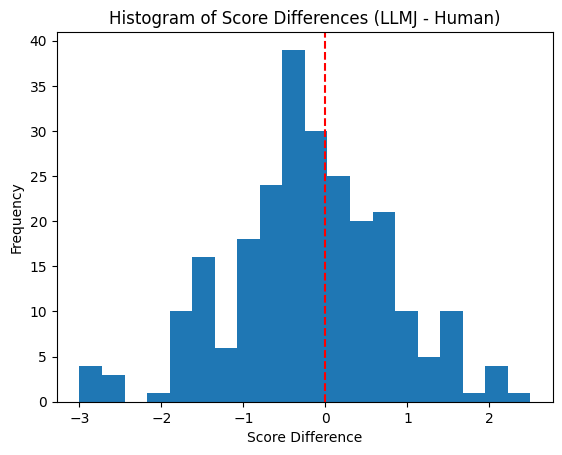

In [202]:
# find the score difference between llmj and human scores
score_differences = []
for llmj_score, human_score in zip(all_llm_judge_scores, all_human_scores):
    score_differences.append(llmj_score[0] - human_score[0])

# plot the histogram of score differences, with red line at 0
import matplotlib.pyplot as plt
plt.hist(score_differences, bins=20)
plt.title('Histogram of Score Differences (LLMJ - Human)')
plt.xlabel('Score Difference')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.show()


In [203]:
np.median(score_differences)

-0.20000000000000018

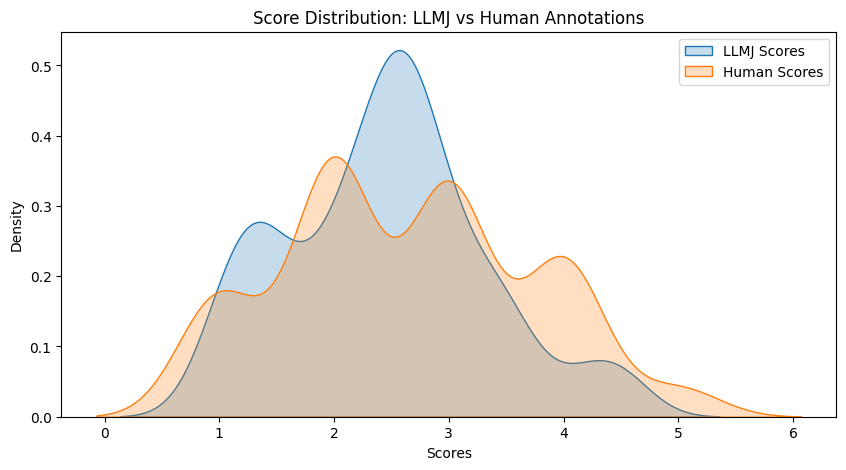

In [204]:
# compare the score distribution for llmj and human annotations
import matplotlib.pyplot as plt
import seaborn as sns
llmj_scores_flat = [score[0] for score in all_llm_judge_scores]
human_scores_flat = [score[0] for score in all_human_scores]
plt.figure(figsize=(10, 5))
sns.kdeplot(llmj_scores_flat, label='LLMJ Scores', fill=True)
sns.kdeplot(human_scores_flat, label='Human Scores', fill=True)
plt.xlabel('Scores')
plt.ylabel('Density')
plt.title('Score Distribution: LLMJ vs Human Annotations')
plt.legend()
plt.show()

### 2.4.2 Replacement Test and Kappa

In [205]:
# annotated_dp[0]
# for dp in annotated_dp:
#     if dp['tool_name'] == 'brick' and dp['tool_use'] == 'something women can carry around as a rape weapon instead of pepper spray':
#         print(dp)

In [206]:
# # create a reference data frame with tool name, tool_use, and two scores
# reference_df = []
# for dp in annotated_dp:
#     # for llmj_score in dp['llm_judge']:
#     reference_df.append({
#         'tool_name': dp['tool_name'],
#         'tool_use': dp['tool_use'],
#         'score': dp['mturk_score'],
#         # 'score2': llmj_score[1]
#     })

# reference_df = pd.DataFrame(reference_df)
# reference_df.to_csv('../data/mturk_anno/aut/references.csv', index=False)
# reference_df.shape

In [207]:
aut_anno_data = []
for dp in aut_llmj:
    tmp_anno_data = {}
    tmp_anno_data['original_idx'] = dp['original_idx']
    # tmp_anno_data['llm_judge'] = dp['llm_judge']
    i = 0
    for mturk_dp in annotated_dp:
        if mturk_dp['original_idx'] == dp['original_idx']:
            tmp_anno_data['human_anno_{}'.format(i)] = mturk_dp['mturk_score']
            i += 1
            if i >= 3:
                # sort human annotation data
                human_annos = sorted([tmp_anno_data['human_anno_{}'.format(j)] for j in range(i)])
                # human_annos = ([tmp_anno_data['human_anno_{}'.format(j)] for j in range(i)])
                for j in range(i):
                    tmp_anno_data['human_anno_{}'.format(j)] = human_annos[j]
                break
    try:
        tmp_anno_data['llm_judge'] = round(dp['cleaned_output'][0][1])
        tmp_anno_data['tool_use'] = dp['cleaned_output'][0][0]
    except:
        tmp_anno_data['llm_judge'] = None
        continue 
    tmp_anno_data['tool_name'] = dp['original_idx'].split('-')[0].strip()

    if i < 3:
        continue # skip if less than 2 human annotations
    
    # # Merge numbers
    # if tmp_anno_data['llm_judge'] >= 2 and tmp_anno_data['llm_judge'] <= 4:
    #     tmp_anno_data['llm_judge'] = 2
    # elif tmp_anno_data['llm_judge'] > 4:
    #     tmp_anno_data['llm_judge'] = 3
    # for j in range(3):
    #     if tmp_anno_data['human_anno_{}'.format(j)] >= 2 and tmp_anno_data['human_anno_{}'.format(j)] <= 4:
    #         tmp_anno_data['human_anno_{}'.format(j)] = 2
    #     elif tmp_anno_data['human_anno_{}'.format(j)] > 4:
    #         tmp_anno_data['human_anno_{}'.format(j)] = 3
    
    tmp_anno_data['human_median'] = int(np.median([tmp_anno_data['human_anno_{}'.format(j)] for j in range(i)]))
    aut_anno_data.append(tmp_anno_data)
len(aut_anno_data)

76

In [208]:
# aut_anno_data

In [209]:
# pd.DataFrame(aut_anno_data).to_csv('../data/mturk_anno/aut/aut_anno_data_v1.0.csv', index=False)

In [210]:
# # t_stats, p_vals, rejects = test_replacement(aut_anno_data, distance_metric, epsilon = 0.25)
# tools = list(set([dp['tool_name'] for dp in aut_anno_data]))
# len(tools)

In [211]:
t_stats, p_vals, rejects = test_replacement(aut_anno_data, distance_metric, epsilon = 0.15)

Number of data points (n): 76, degrees of freedom (df): 75
Before Benjamini-Yekutieli adjustment:
[t critical (alpha=0.05, df=75): -1.665]
Annotator 0: t = -1.305, p(one-sided) = 0.09793, reject H0 = False
Annotator 1: t = 3.298, p(one-sided) = 0.9993, reject H0 = False
Annotator 2: t = -1.557, p(one-sided) = 0.06179, reject H0 = False


In [179]:
# aut_anno_data[0]
weighted_kappa = cohen_kappa_score(
    [dp['llm_judge'] for dp in aut_anno_data],
    [dp['human_median'] for dp in aut_anno_data],
    weights='quadratic'
)
weighted_kappa

0.6817733990147783

## 2.5 CS4

In [464]:
data_path = '../data/mturk_anno/cs4'

### 2.5.0 Script from Haw-shiuan

In [466]:
import pandas as pd
import numpy as np
import math
import scipy.stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#input_f
# eval_mode = 'score'
eval_mode = 'const'  # 'score' or 'const'

if eval_mode == 'const':
    sim_file_path = "{}/D3_all.csv".format(data_path)
else:    
    sim_file_path = "{}/type2_gpt4_mgl.csv".format(data_path)
    satis_col_name = 'GPT4'

grouping_id = 'Input.input_story'

input_file_2_path = "{}/mturk.csv".format(data_path)

num_constraints = 39

if eval_mode == 'score':
    keep_columns = ['FinalGeneratedStory', 'grammar_score_A', 'grammar_score_B', 'coherence_score_A', 'coherence_score_B', 'likability_score_A',  'likability_score_B', 'grammar_score', 'coherence_score', 'likability_score', 'grammar_win', 'coherence_win', 'likability_win', 'win', satis_col_name]
else:
    keep_columns = ['FinalGeneratedStory', 'satisfied']

df_sim = pd.read_csv(sim_file_path)
df_sim = df_sim[keep_columns]
df_sim = df_sim.rename(columns={"FinalGeneratedStory": "Input.input_story"})

df_sim['Input.input_story'] = df_sim['Input.input_story'].str.replace('\n','')


#worker_ids_set = set(['A3DO7XKWE9BAWG'])
#worker_ids_set = set(['A2LMSIDVE4E4IO'])
worker_ids_set = set([])
#worker_ids_set = set(['A2TBXASXZIRNNW'])

df = pd.read_csv(input_file_2_path)
#print(df[ df['Answer.comments'].str.contains("{}")==False ]['Answer.comments'].dropna())
column_names = ["HITId", "AssignmentId","WorkerId", 'Input.input_story', 'Input.order', 'Answer.int1', 'Answer.int2', 'Answer.gr1', 'Answer.gr2', 'Answer.coh1', 'Answer.coh2']

constraint_col_names = []
for i in range(num_constraints):
    constraint_col_names.append("Answer.ic_"+str(i+1))
    
column_names += constraint_col_names

df_subset = df[ column_names ].sort_values(by=[grouping_id])

df_subset['Input.input_story'] = df_subset['Input.input_story'].str.replace('!@#$','')

df_subset = df_subset.fillna(0)

print(len(df_subset))
#df_subset = df_subset[ ['Submitted' == s for s in df_subset['AssignmentStatus']] ]
df_subset = df_subset[ [s not in worker_ids_set for s in df_subset['WorkerId']  ] ]
print('after removing bad workers', len(df_subset))

ans2val = {'on': 1, '': 0}
replace_dict = {}
for i in range(num_constraints):
    replace_dict["Answer.ic_"+str(i+1)] = ans2val

df_subset = df_subset.replace(replace_dict)

#num_summaries = len(df_subset) 

first_ans = df_subset.groupby(grouping_id).nth(0)
second_ans = df_subset.groupby(grouping_id).nth(1)

eval_atts = ['coh', 'int', 'gr']

att_d2_p_corr = {att: [] for att in eval_atts}
att_d2_s_corr = {att: [] for att in eval_atts}
att_d2_acc = {att: [] for att in eval_atts}
acc_arr = []

# print(first_ans)

for i in range( len(first_ans) ):
    first_res = first_ans.iloc[i,:]
    sec_res = second_ans.iloc[i,:]
    acc_scores = [ 1 - abs(first_res['Answer.ic_'+str(j+1) ]-sec_res['Answer.ic_'+str(j+1) ]) for j in range(num_constraints)]
    acc_arr.append( np.mean(acc_scores) )
    
    for att in eval_atts:
        #print(att)
        #print([ (first_res['Answer.'+att+str(j+1) ], sec_res['Answer.'+att+str(j+1) ]) for j in range(num_summaries)] )
        first_att_scores = [ float(first_res['Answer.'+att+str(j+1) ]) for j in range(2)]
        sec_att_scores = [ float(sec_res['Answer.'+att+str(j+1) ]) for j in range(2)]
        #print(first_att_scores, sec_att_scores)
        att_d2_p_corr[att].append( scipy.stats.pearsonr( first_att_scores, sec_att_scores )[0] )
        att_d2_s_corr[att].append( scipy.stats.spearmanr( first_att_scores, sec_att_scores )[0] )
        if first_att_scores[0] == first_att_scores[1] or sec_att_scores[0] == sec_att_scores[1]:
            continue
        if (first_att_scores[0] > first_att_scores[1] and sec_att_scores[0] > sec_att_scores[1]) or (first_att_scores[0] < first_att_scores[1] and sec_att_scores[0] < sec_att_scores[1]):
            att_acc = 1
        else:
            att_acc = 0
        att_d2_acc[att].append(att_acc)

for att in eval_atts:
    first_ans[att+'_pr'] = att_d2_p_corr[att]
    second_ans[att+'_pr'] = att_d2_p_corr[att]
    first_ans[att+'_sr'] = att_d2_s_corr[att]
    second_ans[att+'_sr'] = att_d2_s_corr[att]
    #first_ans[att+'_acc'] = att_d2_acc[att]
first_ans['acc'] = acc_arr
second_ans['acc'] = acc_arr

all_ans = pd.concat( (first_ans, second_ans) )
all_att_pr_names = [att+'_pr' for att in eval_atts]
all_att_sr_names = [att+'_sr' for att in eval_atts]
#all_att_acc_names = [att+'_acc' for att in eval_atts]
#print(all_ans[all_att_pr_names])
for att in eval_atts:
    print('acc', att, np.array(att_d2_acc[att]).mean())
print(all_att_pr_names)
print(first_ans[all_att_pr_names])
print('agreement accuracy', first_ans[all_att_pr_names].mean())
#print('spearman correlation', first_ans[all_att_sr_names].mean())
print('Accuracy', first_ans['acc'].mean())
print(all_ans.groupby("WorkerId")[all_att_pr_names].mean())
#print(all_ans.groupby("WorkerId")[all_att_sr_names].mean())
print(all_ans.groupby("WorkerId")[all_att_sr_names].count())
print(all_ans.groupby("WorkerId")['acc'].mean())


source_d2_coh_1 = {}
source_d2_coh_2 = {}
source_d2_int_1 = {}
source_d2_int_2 = {}
source_d2_gr_1 = {}
source_d2_gr_2 = {}


df_mean = df_subset[column_names[3:]].groupby("Input.input_story").mean()

df_sim = df_sim.set_index('Input.input_story')
df_mean = df_mean.join(df_sim, on='Input.input_story', how='left')


if eval_mode == 'score':
    df_mean['coherence_score_1'] = df_mean['coherence_score_A'].where( df_mean['Input.order']==0, df_mean['coherence_score_B'])
    df_mean['coherence_score_2'] = df_mean['coherence_score_A'].where( df_mean['Input.order']==1, df_mean['coherence_score_B'])
    #df_mean['coherence_score_1'] = df_mean['coherence_score_A']
    #df_mean['coherence_score_2'] = df_mean['coherence_score_B']

    df_mean['likability_score_1'] = df_mean['likability_score_A'].where( df_mean['Input.order']==0, df_mean['likability_score_B'])
    df_mean['likability_score_2'] = df_mean['likability_score_A'].where( df_mean['Input.order']==1, df_mean['likability_score_B'])

    df_mean['grammar_score_1'] = df_mean['grammar_score_A'].where( df_mean['Input.order']==0, df_mean['grammar_score_B'])
    df_mean['grammar_score_2'] = df_mean['grammar_score_A'].where( df_mean['Input.order']==1, df_mean['grammar_score_B'])

    # print(df_mean)
    df_mean = df_mean.dropna()

    #print(df_mean['coherence_score_A'])
    #print(df_mean['coherence_score_1'])
    # print(len(df_mean))

    def compute_acc(df_mean, pred_att_name, llm_att_name, print_name):
        print(df_mean[pred_att_name+'1'].to_numpy() > df_mean[pred_att_name+'2'].to_numpy())
        pred_correct_1 = sum( np.bitwise_and( df_mean[pred_att_name+'1'].to_numpy() > df_mean[pred_att_name+'2'].to_numpy(), df_mean[llm_att_name+'1'].to_numpy() > df_mean[llm_att_name+'2'].to_numpy()) )
        pred_correct_2 = sum( np.bitwise_and( df_mean[pred_att_name+'1'].to_numpy() < df_mean[pred_att_name+'2'].to_numpy(), df_mean[llm_att_name+'1'].to_numpy() < df_mean[llm_att_name+'2'].to_numpy()) )
        pred_total = sum( np.bitwise_and(df_mean[pred_att_name+'1'].to_numpy() != df_mean[pred_att_name+'2'].to_numpy(), df_mean[llm_att_name+'1'].to_numpy() != df_mean[llm_att_name+'2'].to_numpy()) )
        print( print_name, (pred_correct_1+pred_correct_2)/pred_total )
        print( pred_total )

    compute_acc(df_mean, 'coherence_score_', 'Answer.coh', 'coherence_score')
    compute_acc(df_mean, 'likability_score_', 'Answer.int', 'likability_score')
    compute_acc(df_mean, 'grammar_score_', 'Answer.gr', 'grammar_score')
    

    print(scipy.stats.pearsonr( df_mean['coherence_score_1'], df_mean['Answer.coh1'] ))
    print(scipy.stats.pearsonr( df_mean['coherence_score_2'], df_mean['Answer.coh2'] ))
    print(scipy.stats.pearsonr( df_mean['likability_score_1'], df_mean['Answer.int1'] ))
    print(scipy.stats.pearsonr( df_mean['likability_score_2'], df_mean['Answer.int2'] ))
    print(scipy.stats.pearsonr( df_mean['grammar_score_1'], df_mean['Answer.gr1'] ))
    print(scipy.stats.pearsonr( df_mean['grammar_score_2'], df_mean['Answer.gr2'] ))

    print(scipy.stats.spearmanr( df_mean['coherence_score_1'], df_mean['Answer.coh1'] ))
    print(scipy.stats.spearmanr( df_mean['coherence_score_2'], df_mean['Answer.coh2'] ))
    print(scipy.stats.spearmanr( df_mean['likability_score_1'], df_mean['Answer.int1'] ))
    print(scipy.stats.spearmanr( df_mean['likability_score_2'], df_mean['Answer.int2'] ))
    print(scipy.stats.spearmanr( df_mean['grammar_score_1'], df_mean['Answer.gr1'] ))
    print(scipy.stats.spearmanr( df_mean['grammar_score_2'], df_mean['Answer.gr2'] ))

    
    df_mean['avg_const_score']= df_mean[constraint_col_names].sum(axis=1)
    print(len(df_mean))
    print(scipy.stats.pearsonr( df_mean['avg_const_score'], df_mean[satis_col_name] ))
    print(scipy.stats.spearmanr( df_mean['avg_const_score'], df_mean[satis_col_name] ))
else:
    df_mean['avg_const_score']= df_mean[constraint_col_names].sum(axis=1)
    print(len(df_mean))
    print(scipy.stats.pearsonr( df_mean['avg_const_score'], df_mean['satisfied'] ))
    print(scipy.stats.spearmanr( df_mean['avg_const_score'], df_mean['satisfied'] ))



30
after removing bad workers 30
acc coh 0.6363636363636364
acc int 0.6
acc gr 0.8
['coh_pr', 'int_pr', 'gr_pr']
    coh_pr  int_pr  gr_pr
2     -1.0     1.0    NaN
23     NaN     NaN    NaN
5      1.0    -1.0    1.0
19     1.0     1.0    NaN
29     1.0     NaN    1.0
21     NaN     1.0    NaN
25     NaN     NaN    NaN
0      1.0     1.0   -1.0
11    -1.0     1.0    NaN
15    -1.0    -1.0    NaN
4      1.0    -1.0    NaN
26    -1.0     NaN    NaN
6      1.0    -1.0    1.0
9      1.0     1.0    1.0
16     NaN     NaN    NaN
agreement accuracy coh_pr    0.272727
int_pr    0.200000
gr_pr     0.600000
dtype: float64
Accuracy 0.6991452991452991
                  coh_pr    int_pr     gr_pr
WorkerId                                    
A1JI19KPIVNL3Y -1.000000  1.000000       NaN
A1NF6PELRKACS9  1.000000  1.000000  1.000000
A3QZMGTVA4VO44  0.333333  1.000000  1.000000
A3VL1CBZ3BGQK7  0.142857  0.142857  0.333333
AVNP1F3CADQRW   0.333333 -0.111111  0.600000
                coh_sr  int_sr  gr_sr

/var/folders/vm/mfhb6zqd0nv2_ggst23t1ty80000gn/T/ipykernel_78529/2672635872.py:67: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_subset = df_subset.replace(replace_dict)
/var/folders/vm/mfhb6zqd0nv2_ggst23t1ty80000gn/T/ipykernel_78529/2672635872.py:95: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  att_d2_p_corr[att].append( scipy.stats.pearsonr( first_att_scores, sec_att_scores )[0] )
/var/folders/vm/mfhb6zqd0nv2_ggst23t1ty80000gn/T/ipykernel_78529/2672635872.py:96: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  att_d2_s_corr[att].append( scipy.stats.spearmanr( first_att_scores, sec_att_scores )[0] )
/var/folders/vm/mfhb6zqd0nv2_ggst23t1ty80000gn/T/ipykernel

### 2.5.1 Constraint Sati

- Agreement in constrain sati task

In [73]:
# import copy
# # all_kappa = []
# all_matrix = []
# for i in range(1, 40):
#     col = "Answer.ic_"+str(i)
#     tmp_rating_matrix = copy.deepcopy(all_ans[[col, 'story_id']]).pivot_table(index='story_id', columns=col, aggfunc='size', fill_value=0).values
#     # print(tmp_rating_matrix)
#     all_matrix.extend(tmp_rating_matrix.tolist())
# kappa = sm_fleiss_kappa(tmp_rating_matrix)
# kappa

### 2.5.2 Coherent

- Agreement on Coherent task

In [766]:
all_ans[['Answer.coh1']]

NameError: name 'all_ans' is not defined

## 2.6 TTCT

In [268]:
llmj_demo_data = {
    "2_consequences": {
        "highest": {
            "question": "What would happen if the world's deserts suddenly turned into forests?Let's think step by step.",
            "answer": "Absolutely\u2014let\u2019s break down the possible consequences **step by step** if the world\u2019s deserts were to suddenly become forests.\n\n---\n\n**1. Immediate Ecological Disruption**\n\n- **Habitat Loss for Desert Species**  \nDeserts have unique plants and animals adapted to arid conditions (e.g., cacti, camels, scorpions). Sudden transformation would likely wipe out many of these specialized species due to habitat loss and new competition.\n- **Invasive Forest Species**  \nForest ecosystems would introduce entirely different flora and fauna, rapidly overtaking native desert life.\n\n---\n\n**2. Climate Impacts**\n\n- **Global Temperature Change**  \nDeserts are reflective and help cool the planet by reflecting sunlight. Forests are darker, absorb more sunlight, and **could increase surface temperatures** in these regions\u2014but the greater impact might be:\n- **CO\u2082 Absorption**  \nForests are carbon sinks. Turning deserts to forests would remove huge quantities of CO\u2082 from the atmosphere, **slowing climate change**.\n- **Albedo Effect**  \nLower reflectivity (albedo) from forested land could locally warm the area, somewhat offsetting the cooling from CO\u2082 sequestration.\n\n---\n\n**3. Water Cycle and Rainfall**\n\n- **Regional Rainfall Increase**  \nForests transpire water, increasing local humidity and rainfall. Former deserts could become much wetter over time, altering regional weather patterns.\n- **Potential Disruption of Existing Weather Systems**  \nMonsoons, trade winds, and global circulation rely on differences between deserts and forests. Changing all deserts could **disrupt weather on a global scale**, affecting rainfall elsewhere (possibly even reducing rain in current forest areas).\n- **Rivers and Lakes**  \nFormerly dry areas might develop new lakes and rivers, altering geography.\n\n---\n\n**4. Soil and Landscape Changes**\n\n- **Soil Formation**  \nDesert soils are poor and thin. Forest growth would gradually improve soil quality, but initially, new trees might struggle. If they appear instantly, it complicates natural soil-building processes.\n- **Sandstorms Would Cease**  \nWithout exposed sand, the global issue of dust and sandstorms would diminish.\n\n---\n\n**5. Human Consequences**\n\n- **New Habitable Land**  \nRegions previously considered uninhabitable (like the Sahara) could support agriculture, cities, and large populations.\n- **Loss of Unique Cultures**  \nNomadic and oasis-based cultures specific to deserts would face challenges or disappear.\n- **Infrastructure Challenges**  \nSudden vegetation growth could",
            "fluency_score": 4.0,
            "flexibility_score": 4.0,
            "originality_score": 3.0,
            "elaboration_score": 3.0
        },
        "median": {
            "question": "What would happen if plastic could biodegrade as quickly as paper?Let's think step by step.",
            "answer": "Absolutely, let's break this down step by step:\n\n### Step 1: Understand the Current Difference\n- **Paper** typically biodegrades within weeks to a few months.\n- **Plastic** (like polyethylene or PET) can take hundreds or even thousands of years.\n\n### Step 2: Hypothetical Change\n- Imagine **plastic biodegrades as quickly as paper** \u2014 i.e., disappears within weeks to months under common environmental conditions.\n\n---\n\n## Environmental Impacts\n\n1. **Reduced Pollution**\n    - **Dramatic decrease in plastic pollution** on land and in oceans, as plastics wouldn't linger for decades/centuries.\n    - Ghost nets, plastic bags, and microplastics would not accumulate in ecosystems.\n\n2. **Wildlife Protection**\n    - Less risk to marine and terrestrial animals who ingest or become entangled in plastic debris.\n\n3. **Cleaner Landscapes and Waterways**\n    - Less litter in streets, beaches, rivers, and cities.\n\n---\n\n## Waste Management\n\n4. **Easier Management**\n    - Less pressure on landfills, as plastics would break down quickly just like compostable waste.\n    - Composting facilities and home composting could handle a wider variety of waste.\n\n5. **Less Need for Recycling**\n    - The incentive to recycle to prevent long-term environmental harm would be reduced. However, recycling could still be important for resource conservation.\n\n---\n\n## Human Health\n\n6. **Reduced Exposure**\n    - Lower levels of microplastics in water, food, and air, which could help with associated health risks.\n\n---\n\n## Industry and Economy\n\n7. **Product Design Changes**\n    - Companies might need to rethink the shelf life and storage of plastic-packaged goods to prevent unwanted biodegradation.\n    - Some uses (e.g., medical devices, construction) might require newly designed plastics to ensure longevity.\n\n8. **Shifts in Manufacturing**\n    - The push for \"biodegradable\" or \"compostable\" plastics would become the norm or obsolete if all plastics were like this.\n\n---\n\n## Potential Downsides / Challenges\n\n9. **Unintended Degradation**\n    - **Stability:** If plastics degrade too quickly, products could fail before use if not stored properly (e.g., food wrappers breaking down on the shelf).\n    - Engineers would need to tailor degradation rates or develop coatings for products needing long life.\n\n10. **Increased Consumption**\n    - People/companies might use even more plastic, knowing it's no longer a long-term pollutant, possibly leading to other resource and",
            "fluency_score": 4.0,
            "flexibility_score": 4.0,
            "originality_score": 2.0,
            "elaboration_score": 3.0
        },
        "lowest": {
            "question": "What would happen if the world's deserts suddenly turned into forests?Let's think step by step.",
            "answer": " The key points here are: - Deserts currently cover about 1/3 of Earth's land surface. - Forests contribute to oxygen production - and absorb CO2.\n\nDeserts are hot, dry areas. They cover roughly one-third of Earth's land surface and are characterized by little rain and sparse vegetation.\n\nForests play a crucial role in our planet's ecosystem. They produce oxygen and act as carbon sinks, absorbing carbon dioxide (CO2) from the atmosphere and storing it as organic matter, thus mitigating climate change. Trees also support numerous ecological processes, wildlife habitats, and provide resources such as timber and medicinal plants.\n\n### Step 1: Estimating Oxygen Production\n\n- **Desert Plants Contribution**: Deserts are typically dominated by hardy shrubs and short grasses, which do not produce as much oxygen as trees found in forests.\n- **Forest Contribution**: Trees release oxygen through photosynthesis. An average tree can produce around 260 pounds (about 118 kg) of oxygen per year.\n\nAssume there are approximately 1 billion hectares (10 million sq km) of deserts - this is a rough estimate.\n\n**Oxygen Calculation**:\n- **Desert Biomes**: If we assume desert plants produce roughly 10% of the oxygen that trees produce (due to less biomass and photosynthesis), then each hectare produces about 26 pounds (11.8 kg) of oxygen annually.\n- **Annual Oxygen from Deserts**: \\( 1 \\text{ billion hectares} \\times 26 \\text{ pounds/hectare/year} = 26 \\text{ billion pounds/year} \\).\n\n**Forest Biomes**:\n- **Annual Oxygen from Forests**: \\( 1 \\text{ billion hectares} \\times 260 \\text{ pounds/hectare/year} = 260 \\text{ billion pounds/year} \\).\n\n### Step 2: Carbon Dioxide Absorption\n\n- **Deserts**: Since deserts have sparse vegetation, their role in CO2 absorption is minimal compared to forests.\n\n**Carbon Dioxide Absorption**:\n- **Deserts**: Minimal - assume negligible CO2 absorption.\n- **Forests**: A mature forest can absorb between 1 to 10 tons of CO2 per hectare per year. Using an average of 5 tons/hectare/year,\n  - **Annual CO2 Absorption from Forests**: \\( 1 \\text{ billion hectares} \\",
            "fluency_score": 2.0,
            "flexibility_score": 2.0,
            "originality_score": 2.0,
            "elaboration_score": 4.0
        }
    },
    "6_improvement": {
        "highest": {
            "question": "Creativity Improvement Task. You'll be presented with a object, and your task is to suggest as many ways as you can think of to improve the object. Let's think step by step. Here's the object: Shopping Cart",
            "answer": ". The shopping cart is a simple utility that helps customers carry their groceries from the shelves to the checkout counter. To improve the shopping cart, we can consider the following aspects:\n\n1. Ergonomics:\n- Improve the height and design to be more ergonomic for people of different heights\n- Add ergonomic features, such as side handles or back support\n- Make the wheels easier to maneuver and adjust for different surfaces\n\n2. Durability and Quality:\n- Replace or reinforce parts that frequently wear out\n- Use high-quality materials and construction methods to reduce wear and tear\n- Improve the strength of the frame to withstand heavy loads\n\n3. Convenience:\n- Add compartmentalized baskets or containers for different types of goods\n- Include features like quick-release handles for quick access to items\n- Offer different sizes or configurations to fit various needs (e.g., narrow aisles, large families)\n\n4. Sustainability:\n- Upgrade to eco-friendly materials (biodegradable, recycled, or reusable components)\n- Improve the design for easier assembly and disassembly for recycling\n- Encourage the use of reusable carts with customer rewards or discounts\n\n5. Digital Enhancements:\n- Integrate touchscreens for price checking, payment, and coupons\n- Connect carts to the store's POS system for real-time inventory management\n- Add features for smartphone integration, such as app control of certain functions\n\n6. Accessibility:\n- Implement features to help customers with mobility challenges (e.g., easier to maneuver, wheelchair-accessible designs)\n- Offer adjustable seating or backrests for customers who need them\n- Design accessible shopping carts that don't require pushing (e.g., powered or pulled carts)\n\n7. User Experience:\n- Create intuitive designs for easy loading and unloading of items\n- Offer pre-sorted compartments for specific categories (e.g., fresh produce, dairy, bakery)\n- Include safety features like automatic braking or gentle stops to prevent accidental rolling\n\n8. Storage and Travel:\n- Enable collapsible designs for easy storage or stacking\n- Add hooks or storage compartments for bags, umbrellas, or shopping lists\n- Design portable carts that can be easily disassembled for travel or storage\n\n9. Additional Functions:\n- Integrate promotional materials or advertisements for in-store marketing\n- Include hooks or holders for bags, purses, or shopping",
            "fluency_score": 4.0,
            "flexibility_score": 5.0,
            "originality_score": 4.0,
            "elaboration_score": 4.0
        },
        "median": {
            "question": "Creativity Improvement Task. You'll be presented with a object, and your task is to suggest as many ways as you can think of to improve the object. Let's think step by step. Here's the object: Post-it Notes",
            "answer": "Absolutely, let's break this down and brainstorm as many ways as possible to improve the humble Post-it Note!\n\n### 1. **Functionality Improvements**\n- **Stronger Adhesive Options:** Offer Post-its with variable stickiness, from ultra-tacky (for vertical walls/textured surfaces) to easy-peel (for delicate pages).\n- **Reusable Adhesive:** Use a dry-erase sticky backing that retains adhesion after cleaning.\n- **Magnetic Backing:** Add magnetic strips for use on metal surfaces (fridges, whiteboards).\n- **Waterproof & Tear-Resistant Material:** Make notes from waterproof and durable material for outdoor or workshop use.\n- **Printable Post-its:** Post-its that can be run through standard home/office printers for custom printing.\n- **Integrated NFC/QR codes:** Digital-physical bridge for linking to online content.\n\n### 2. **Design & Appearance**\n- **Transparent Post-its:** For annotating over documents without obscuring text.\n- **Color-Customizable:** Color-shifting or user-customizable colors for coding/organization.\n- **Shaped Notes:** Different shapes beyond squares/rectangles: arrows, stars, tabs, etc.\n- **Multipurpose Layouts:** Pre-printed checklist, grid, lined, calendar, or mind map templates.\n\n### 3. **Sustainability**\n- **Recyclable or Compostable Materials:** 100% biodegradable Post-it notes.\n- **Plantable Notes:** Embedded with seeds so used notes can be planted!\n- **Refillable Pads:** Hard cover \u201cPost-it holders\u201d that accept refill sticky packs.\n\n### 4. **Technology Integration**\n- **Bluetooth Locator Chips:** Never lose your notes\u2014track with phone app!\n- **Smart Pen Compatible:** Special surface to digitize your notes when written with a smart pen.\n- **App Integration:** Each note has a scannable code linking to a \u201cvirtual copy\u201d in a cloud app for searchability.\n- **E-Paper Sticky Notes:** Reusable, thin, stickable e-ink screens for digital-physical interaction.\n\n### 5. **New Use Cases & Convenience**\n- **Pre-perforated Edges:** For easy tearing to smaller sizes.\n- **Sticky on Two Sides:** For more versatile mounting.\n- **Expandable/Unfolding Notes:** Larger writing surface when more info is needed.\n- **Integrated Writing Tool:** Mini pen or pencil slot within pad.\n\n### 6. **Accessibility**\n- **Braille Post-its",
            "fluency_score": 4.0,
            "flexibility_score": 4.0,
            "originality_score": 3.0,
            "elaboration_score": 3.0
        },
        "lowest": {
            "question": "Creativity Improvement Task. You'll be presented with a object, and your task is to suggest as many ways as you can think of to improve the object. Let's think step by step. Here's the object: Ear Plugs",
            "answer": ". I will suggest the ways one by one, and you should respond with \"Next suggestion please\". Let's start: 1. **Scented Ear Plugs:** Infusing earplugs with different scents (e.g., lavender, lemon, or jasmine) to help users relax and better fall into a state of sleep or rest. Next suggestion please. Sure! 2. **Noise-Reducing Technology:** Incorporating active noise-canceling technology to block out a wider spectrum of sounds, not just basic white noise. Next suggestion please.",
            "fluency_score": 2.0,
            "flexibility_score": 2.0,
            "originality_score": 2.0,
            "elaboration_score": 1.0
        }
    },
    "5_common_problems": {
        "highest": {
            "question": "Common Problems Task. In this task, you will be presented with a scenario or situation. Your job is to think about it and identify as many potential problems or issues that may arise in connection with each situation. Let's think step by step. The scenario is: Pioneering a mission to the bottom of the ocean.",
            "answer": " \n\nStep 1: Identify the situation and the factors involved.\n- Pioneering a mission to the bottom of the ocean involves a complex set of challenges.\n- These challenges include the intense water pressure, lack of sunlight, extreme temperatures, and potential biological hazards.\n- The mission likely involves specialized equipment such as submersibles, remotely operated vehicles (ROVs), and marine research facilities.\n- The mission aims to explore and potentially establish a presence for scientific research, mining, or communication purposes.\n\nStep 2: Consider the potential problems that could arise from these factors.\n\nStep 3: List each problem individually.\n\nPotential Problems:\n1. **Intense Water Pressure and Structural Integrity:** The immense pressure at the ocean floor could cause structural failures in submersibles and supporting equipment. This could lead to damaged equipment, potential loss of life, and mission failure.\n\n2. **Lack of Sunlight and Energy Sources:** Deeper ocean levels lack sunlight, rendering solar energy impractical. This necessitates relying on alternative power sources like batteries or nuclear reactors, which can fail, run out, or pose risks of radiation leaks.\n\n3. **Extreme Temperatures:** The deep ocean experiences extreme cold, which can affect the operational efficiency of electronics and mechanical systems. Additionally, high-temperature hydrothermal vents could damage equipment or pose risks to human operators.\n\n4. **Biological Hazards:** Unknown or aggressive marine life could damage or infiltrate equipment. Human operators may face threats from these life forms, including pathogens or predators.\n\n5. **Communication Issues:** Deep-sea communications can be unreliable due to the difficulty of signal transmission through water. This can lead to isolation, delayed response times in emergencies, and difficulties in data transmission.\n\n6. **Environmental Impact:** The mission may disrupt the delicate marine ecosystem. This could result in unintended damages to flora and fauna, including habitat destruction and loss of valuable marine life.\n\n7. **Technical Malfunctions:** Advanced technology inherently carries the risk of technical failures. This can include equipment malfunctions, software bugs, or mechanical breakdowns that may jeopardize the mission.\n\n8. **Resource Limitation:** Deep-sea missions are resource-intensive, with limited recovery options if supplies run short. This includes provisions for the",
            "fluency_score": 4.0,
            "flexibility_score": 4.0,
            "originality_score": 3.0,
            "elaboration_score": 4.0
        },
        "median": {
            "question": "Common Problems Task. In this task, you will be presented with a scenario or situation. Your job is to think about it and identify as many potential problems or issues that may arise in connection with each situation. Let's think step by step. The scenario is: Overcoming language barriers in a multicultural workplace.",
            "answer": " When managing multicultural teams, communication problems can lead to failure. Many people only speak English, but others speak different languages as their first language.\n\nNow, let's think of a few possible issues:\n\n* Misinterpretations and misunderstandings due to language differences can occur, leading to projects not being completed on time or to their fullest potential.\n* When English is not a first language for some team members, they might feel less confident to speak up, leading to an underrepresentation of their ideas and opinions, creating an imbalanced team dynamic.\n* If team meetings and important communications are held in English only, non-native English speakers might miss out on critical information or feel alienated.\n* Disagreements or conflicts between team members might arise due to cultural misunderstandings resulting from language barriers.\n* Language barriers could slow down decision-making processes, as multiple translations may be needed, and clarifications have to be frequently sought.\n\nThe solution would involve addressing these barriers through:\n\n* Providing language support through language training, translation services, or hiring multilingual team members.\n* Encouraging everyone to express their ideas freely and valuing all opinions equally to promote a more inclusive environment.\n* Being mindful of communication styles and giving team members the opportunity to express themselves in the language comfortable for them, if practical.\n* Promoting cultural awareness and understanding among team members to reduce misunderstandings and conflicts.\n* Utilizing technology tools such as translation apps and real-time virtual translation services during meetings to ensure inclusivity and accessibility.",
            "fluency_score": 3.0,
            "flexibility_score": 4.0,
            "originality_score": 2.0,
            "elaboration_score": 3.0
        },
        "lowest": {
            "question": "Common Problems Task. In this task, you will be presented with a scenario or situation. Your job is to think about it and identify as many potential problems or issues that may arise in connection with each situation. Let's think step by step. The scenario is: Writing a screenplay for a feature film.",
            "answer": " Sure, let's break down the scenario of writing a screenplay for a feature film and identify potential problems or issues that may arise in the process. I'll go through this step by step:\n\n### 1. Initial Development\n- **Lack of Originality**: Finding a unique idea that hasn't been done to death in the industry.\n- **Market Research**: Insufficient knowledge about current market trends and audience preferences.\n- **Character Development**: Crafting compelling, well-rounded characters.\n- **Plot Structure**: Developing a coherent and engaging plot.\n- **Genre Confusion**: Struggling to define the genre of the film accurately.\n\n### 2. Writing Process\n- **Writer\u2019s Block**: Facing difficulties in generating ideas or structuring scenes.\n- **Excessive Pacing**: Creating a script that moves too quickly or too slowly.\n- **Dialogue**: Writing realistic, engaging, and meaningful dialogue.\n- **Voice and Tone**: Maintaining a consistent voice throughout the script.\n- **Formatting Issues**: Ensuring adherence to proper screenplay format and guidelines.\n\n### 3. Budget Constraints\n- **Funding**: Securing financial support to make the film.\n- **Penny Pinching**: Making choices that compromise quality due to budget limitations.\n- **Resource Allocation**: Efficient distribution of available resources (e.g., crew, equipment, location).\n\n### 4. Team Dynamics\n- **Writer's Block on Collaboration**: Collaborating with a team if the project is for a studio or company.\n- **Creative Differences**: Resolving conflicts with directors, producers, or other writers.\n- **Management**: Balancing creative input with production demands.\n- **Communication**: Ensuring clear and effective communication between all team members.\n\n### 5. Legal and Rights Issues\n- **Copyright Infringement**: Using copyrighted material without proper licensing.\n- **Workshop and Feedback**: Getting feedback from legal professionals or rights holders.\n- **Permits and Clearances**: Obtaining necessary permissions for locations, music, or other elements.\n- **Contractual Obligations**: Adhering to contractual agreements during and after the writing process.\n\n### 6. Thematic and Narrative Issues\n- **Over-Explaining**: Telling the story in a way that feels heavy-handed or",
            "fluency_score": 3.0,
            "flexibility_score": 3.0,
            "originality_score": 3.0,
            "elaboration_score": 2.0
        }
    },
    "4_situation": {
        "highest": {
            "question": "If all musical recordings were lost, how would you listen to music? Let's think step by step.",
            "answer": " To imagine what would happen if all musical recordings were lost, we'd need to consider different ways of experiencing music. Here's a step-by-step approach:\n\n1. **Assessment of Current Situation**: In our current context, we rely heavily on digital recordings to listen to music. Music is often streamed, downloaded, and stored on devices like smartphones, tablets, and computers.\n\n2. **Temporary Response**: In the immediate aftermath, people would seek alternative ways to listen to their favorite music. They may attempt to access existing physical media like CDs, vinyl records, or cassettes if they have any at home. They might also look for analog recordings stored in libraries or museums.\n\n3. **Live Performances**: Concerts, music festivals, and live radio broadcasts would become increasingly popular. Friends, families, and communities might gather to attend live performances or even organize informal music sessions in parks, cafes, or community buildings.\n\n4. **In-Demand for Musicians and Instruments**: The demand for live music would likely lead to an increased number of musicians playing in public spaces or at events. Instruments such as guitars, pianos, drums, and accordions would be in higher demand.\n\n5. **DIY & Home Entertainment**: People might start creating their own music. They could use traditional instruments or modern technology to compose and perform music in their homes. This could lead to a surge in home recording equipment and software sales.\n\n6. **Collaborative Efforts**: There might be a resurgence of community and collaborative music-making. Music clubs, workshops, and jam sessions might become more prevalent as people find ways to share and create music together.\n\n7. **Recovery of Old Media**: Archives, libraries, and historical institutions would likely play a crucial role in preserving and recovering old music recordings. This process would involve digitization and restoration of records, tapes, and other analog media.\n\n8. **New Formats**: Alternative formats for distributing and enjoying music might emerge. Apps for discovering and sharing live music, online platforms for sharing sheet music, and community-based digital libraries for sharing old and new music could become popular.\n\n9. **Educational Initiatives**: There would be an increased focus on music education and teaching. Schools and community centers might offer more classes in music theory, composition, and performance. YouTube and other online platforms could become rich resources for music education.\n\n10. **Cultural Preservation**: In addition to digital recovery, there might be a",
            "fluency_score": 5.0,
            "flexibility_score": 4.0,
            "originality_score": 3.0,
            "elaboration_score": 3.0
        },
        "median": {
            "question": "If all watches and clocks disappeared, how would you schedule your day? Let's think step by step.",
            "answer": "Absolutely, that\u2019s an interesting challenge! Here\u2019s a step-by-step way you could schedule your day without any clocks or watches\u2014just like people did for most of history:\n\n### 1. **Use Natural Light and the Sun**\n- **Sunrise:** Wake up with the light. When you notice the sky turning lighter, start your day.\n- **Sun Movement:** Track the sun\u2019s position to estimate the time. For example:\n    - **Morning:** Sun rises in the east.\n    - **Noon:** Sun is highest in the sky (this is roughly midday).\n    - **Afternoon/Evening:** Sun heads west and eventually sets.\n\n### 2. **Divide Your Day into Segments**\nWithout precise hours, break your day down by notable events:\n- Early morning (dawn)\n- Morning (when sun is well up)\n- Midday (sun overhead)\n- Afternoon (sun moving westward)\n- Evening (as light dims)\n- Night (after sunset)\n\n### 3. **Create Routine Anchored to Natural Events**\nAssign recurring activities to segments:\n- **Wake up:** When sky brightens (dawn)\n- **Breakfast:** After waking, once things are set up\n- **Morning activities/work:** After breakfast, until sun gets high\n- **Meal (lunch):** When sun is overhead and you feel hungry (midday)\n- **Afternoon work:** After lunch until shadows lengthen\n- **Wrap up:** As it gets cooler, sun low in sky\n- **Evening meal:** Before it gets totally dark\n- **Wind down and sleep:** After dark\n\n### 4. **Observe Nature\u2019s Cues**\n- **Birds singing:** Many birds sing at dawn and dusk.\n- **Animal and insect activity:** Farm animals and certain insects have set patterns around day and night.\n- **Flowers:** Some bloom or close at specific parts of the day.\n\n### 5. **Personal Cues and Routine**\n- Use hunger, fatigue, and alertness as rough indicators for meals, breaks, and rest.\n- Body\u2019s circadian rhythm (after adjusting) will help anchor when you feel sleepy or energetic.\n\n### 6. **Use Simple Tools If Needed**\n- **Shadow stick:** Stick a stick in the ground and mark how the shadow moves. It\u2019s shortest at noon.\n- **Candle/Incense clocks:** For more advanced planning, specific-length candles or sticks of incense were used before mechanical clocks.\n\n---\n\n**Example Day (no clocks):**",
            "fluency_score": 3.0,
            "flexibility_score": 3.0,
            "originality_score": 2.0,
            "elaboration_score": 3.0
        },
        "lowest": {
            "question": "If all watches and clocks disappeared, how would you schedule your day? Let's think step by step.",
            "answer": " The relevant sentence in the passage is: For the first time, the modern Olympic Games were no longer held in countries with majority Christian populations. This justifies what answer for what question? Q & A: Has the Modern Olympic Games been canceled due to wars?\nno",
            "fluency_score": 1.0,
            "flexibility_score": 1.0,
            "originality_score": 1.0,
            "elaboration_score": 1.0
        }
    },
    "1_unusual_uses": {
        "highest": {
            "question": "Unusual Uses Task. You will be presented with a common object, and your task is to suggest as many unusual, innovative, or non-traditional uses for each object as you can think of. Let's think step by step. Please list unusual uses of  keyboard",
            "answer": ".\n\nCertainly! Let's think through some unusual uses for a keyboard, considering both the physical keys and the electronic component:\n\n### 1. **Lighting System:**\n   - **LED Light**: Connect LED lights to each key and use the keyboard to control the lighting. For instance, you could create a decorative display or a lamp.\n\n### 2. **Game Controller:**\n   - **Customizable Gameplay**: Turn a keyboard into a custom game controller for PC games. Use the keys to simulate buttons and the arrow keys for movement.\n\n### 3. **Environmental Control:**\n   - **Thermostat Control**: Program your keyboard to control a smart thermostat or HVAC system, allowing you to adjust temperatures with keyboard shortcuts.\n\n### 4. **Robotics Interface:**\n   - **Remote Control**: Use it as a remote control for robots or drones, mapping specific keys to movement commands.\n\n### 5. **Music Synthesis:**\n   - **MIDI Keyboards**: Convert your keyboard into a MIDI controller to make music. Each key can trigger different notes or tones.\n\n### 6. **Data Entry Interface:**\n   - **Custom Data Input**: Program the keyboard to input specific data into a database or spreadsheet. For example, pressing certain keys could automatically enter predefined information.\n\n### 7. **Text Art:**\n   - **Text-To-Art Software**: Use the keyboard in a text-to-art application where key presses map to specific artistic or design elements.\n\n### 8. **Interactive Art Installation:**\n   - **Artist's Tool**: Set up an interactive art installation where visitors can type to create visuals on a screen or other medium.\n\n### 9. **Fitness Tracking:**\n   - **Motion Sensor**: Attach sensors to key switches and use the keyboard as a motion sensor to track user movements.\n\n### 10. **Language Learning Tool:**\n   - **Typing Tutor**: Make a fun and interactive typing tutor where learning a new language involves typing practice.\n\n### 11. **Security Access:**\n   - **Passcode Entry**: Instead of a traditional passcode, use a unique sequence of key presses as a security access code.\n\n### 12. **Sound Effects:**\n   - **Soundboard**: Map keys",
            "fluency_score": 4.0,
            "flexibility_score": 5.0,
            "originality_score": 4.0,
            "elaboration_score": 5.0
        },
        "median": {
            "question": "Unusual Uses Task. You will be presented with a common object, and your task is to suggest as many unusual, innovative, or non-traditional uses for each object as you can think of. Let's think step by step. Please list unusual uses of  carpet",
            "answer": "Absolutely! Here are unusual, innovative, or non-traditional uses for carpet:\n\n1. **Soundproofing Walls:** Attach pieces of carpet to the walls of music studios, home offices, or noisy rooms to absorb sound and reduce echo.\n2. **Pet Scratching Post:** Wrap carpet scraps around a post or board for a DIY cat scratching post.\n3. **Garden Pathways:** Lay old carpet upside down between rows in a garden to prevent weeds and keep your shoes clean.\n4. **Moving Heavy Furniture:** Place carpet under heavy furniture to easily slide it across floors without scratching.\n5. **Pinboard Covering:** Stretch carpet over a pinboard for a soft, durable, and visually interesting pinning surface.\n6. **Temporary Picnic Blanket:** Use a carpet remnant as an outdoor blanket for picnics or seating at concerts.\n7. **Doormat Creation:** Cut old carpet into smaller pieces to make custom doormats for entryways or garages.\n8. **Automobile Mats:** Cut and custom-fit old carpet to use as floor mats in cars, trucks, or boats.\n9. **Upholstery Padding:** Use sheets of carpet as padding underneath upholstery for extra support and cushioning.\n10. **Workout Mat:** Thicker carpet pieces can be used as makeshift yoga or exercise mats.\n11. **Sledding Surface:** In areas with little or no snow, use carpet on a hill as a sliding surface for sledding.\n12. **Art Canvas:** Paint or create murals directly onto carpet for textured, unique art pieces.\n13. **Tree Swing Seat:** Fold and secure carpet to make a soft seat for a homemade swing.\n14. **Playground Surfaces:** Use as cushioning material under play equipment to soften falls.\n15. **Pet Lining:** Place in pet crates or beds for extra warmth and comfort.\n16. **Insulation:** Install on attic walls, basement floors, or garage doors for additional thermal insulation.\n17. **Packing/Moving Protection:** Wrap fragile items in carpet for padding during shipping or moving.\n18. **Draft Stopper:** Roll up strips of carpet and place them at the bottom of doors to prevent drafts.\n19. **Tabletop Protector:** Use as a cushioned surface to protect tables from scratches and hot dishes.\n20. **Climbing Wall Grips:** Attach rollers or chunks of carpet for unique handholds on home climbing walls.\n21. **Crafting Base:** Use carpet as a base for projects involving glue, paint, or cutting.\n22. **Obstacle Course",
            "fluency_score": 4.0,
            "flexibility_score": 4.0,
            "originality_score": 3.0,
            "elaboration_score": 3.0
        },
        "lowest": {
            "question": "Unusual Uses Task. You will be presented with a common object, and your task is to suggest as many unusual, innovative, or non-traditional uses for each object as you can think of. Let's think step by step. Please list unusual uses of  keyboard",
            "answer": ", one per line.\na frisbee\nthrow at people you dont like\na weapon\na mirror to see whats behind you\na plate\na drum\na lid for a jar\na bird bath\na rain hat\nan instrument\na bird feeder\na pot cover\na hammer\na sled (small and slippery)\na shield\na mirror\na picture frame\na weapon\na sled (make a few and race)\na christmas tree ornament\na dog toy\na hammer\na raft\na cutting board\na drum\na hide and seek hiding spot\na fly swat\na light saber\na ninja weapon\na toy\na boat\na chair\na hammer\na toy for pets\na hammer\ndrum\nfly swatter\na lid\na mirror\na painting\nglasses\na hammer\na sled (for a toy train)\na drum\na weapon (for a tiny person)\na christmas tree ornament\na dog toy\na plate\nan instrument\na bird bath\na rain hat\nan instrument\na chopping board\na weapon (for a tiny secret agent)\na toy (for a tiny person)\na toy for pets\na boat\na chair\na snowshoe\na ninja weapon\na shield\na frisbee\na lid\na mirror\nto write on\na sledge (make a few and build a snowman)\na bird feeder\na pot cover\nto hold something down outside\na mask\na christmas wreath\na dog tug-of-war toy\na pizza cutter\nweight for crafting projects\nemergency whistle\nto scare away animals\nto flatten garlic or herbs\na bookmark\njewelry hanger\na hat\na hammer\na toy airplane\na raft\na mirror for periscoping\nbracelet\na snack tray\nto scoop ice cream or mashed potatoes\ndrum\nfrying pan or griddle\nfly swatter\na ninja weapon\nan improvised guitar\nto press flowers\na bird bath\nto crush pills\na makeshift bell",
            "fluency_score": 2.0,
            "flexibility_score": 2.0,
            "originality_score": 3.0,
            "elaboration_score": 2.0
        }
    }
}

In [321]:
curr_llmj = 'gpt41'
# curr_llmj = 'qwen72'
# curr_llmj = 'gemini'
# curr_llmj = 'gpt5'

In [322]:
curr_llmj_input = pd.read_csv('../data/mturk_anno/ttct/v1.1_llmj_input/ttct_mturk_merged_final_filtered.csv')
curr_llmj_input.shape

(129, 73)

In [323]:
import re 
traits = ['Fluency', 'Flexibility', 'Originality', 'Elaboration']

tmp_eval_output = 'Fluency: 5  \nFlexibility: 5  \nOriginality: 4  \nElaboration: 5  \n'
tmp_eval_pairwise = 'Fluency: B  \nFlexibility: A  \nOriginality: A  \nElaboration: A  \n'

def extract_scores(eval_output, pairwise=False):
    if not pairwise:
        pattern = r'(\w+): (\d+)'
        matches = re.findall(pattern, eval_output.split('### Scores ###')[1] if '### Scores ###' in eval_output else eval_output)
        scores = {match[0]: int(match[1]) for match in matches}
        return scores
    else:
        scores = {}
        for trait in traits:
            if trait + ':' not in eval_output:
                print(f"Warning: {trait} not found in eval_output")
            else:

                pattern = f'{trait}: ([A,B])'
                matches = re.findall(pattern, eval_output.split('### Judgement ###')[1] if '### Judgement ###' in eval_output else eval_output)
                # print(matches)
                scores[trait] = matches[0] if matches else None
        return scores
extract_scores(tmp_eval_pairwise, pairwise=True)

{'Fluency': 'B', 'Flexibility': 'A', 'Originality': 'A', 'Elaboration': 'A'}

In [358]:
# curr_model = 'gpt-4.1-2025-04-14'
setting = 'zero_shot'
setting = 'few_shot'
# setting = 'pairwise'
# setting = 'pairwise_high'
# setting = 'pairwise_low'
setting = 'summary'
infer_model_lst = [
    'gpt-4.1-2025-04-14',
    'OLMo-2-1124-13B-Instruct',
    'Qwen2.5-7B-Instruct'
]
curr_llmj_list = [
    'gpt41',
    # 'gpt5',
    'qwen72',
    # 'gemini'
]
traits = ['Fluency', 'Flexibility', 'Originality', 'Elaboration']

all_llmj_output_dict = {}
for curr_model in infer_model_lst:
    if setting == 'pairwise':
        setting_suffix = '_pairwise'
    elif setting == 'pairwise_low':
        setting_suffix = '_pairwise_low'
    elif setting == 'pairwise_high':
        setting_suffix = '_pairwise_high'
    elif setting == 'summary':
        setting_suffix = '_summary'
    else:
        setting_suffix = ''
    
    for curr_llmj in curr_llmj_list:
        curr_llmj_output = load_json(f'../data/mturk_anno/ttct/v1.1_llmj_output/{setting}/{curr_llmj}_judge{setting_suffix}/{curr_model}.json')
        if curr_llmj_output == {}:
            print(f"Warning: No output found for {curr_llmj} with model {curr_model} in setting {setting}")
            continue
        curr_llm_judge_dict = dict(zip(
            [
                (item['input']['text_cot'], curr_model) for item in curr_llmj_output
            ], 
            [
                (
                    extract_scores(
                        item['evaluation']['text_cot'], 
                        pairwise=True if 'pairwise' in setting else False
                    ), 
                    item['eval_input']['target'] if 'target' in item['eval_input'] else None
                )
                for item in curr_llmj_output
            ]
        ))
        for key in curr_llm_judge_dict:
            if key not in all_llmj_output_dict:
                all_llmj_output_dict[key] = {curr_llmj: curr_llm_judge_dict[key]} 
            else:
                all_llmj_output_dict[key][curr_llmj] = curr_llm_judge_dict[key]

total_scores = 0 
invalid_overall_scores = 0
if 'pairwise' not in setting:
    for key in all_llmj_output_dict:
        tmp_value = all_llmj_output_dict[key]
        tmp_value['overall'] = [{trait: None for trait in traits}, None]
        # print(tmp_value['gemini'])
        # break 
        for trait in traits:
            tmp_scores = [
                tmp_value[model][0][trait] 
                for model in curr_llmj_list if trait in tmp_value[model][0]
            ]
            total_scores += 1
            if len(tmp_scores) == 0:
                invalid_overall_scores += 1
                # print(f"Warning: No scores found for trait {trait} in key {key}")
            tmp_value['overall'][0][trait] = np.nanmean(tmp_scores) if len(tmp_scores) > 0 else None
            # tmp_value['overall'][0][trait] = np.median(tmp_scores) if len(tmp_scores) > 0 else None
        # tmp_value['overall']

invalid_overall_scores, total_scores

(0, 180)

In [359]:
list(all_llmj_output_dict.values())[0]

{'gpt41': ({'Fluency': 3,
   'Flexibility': 5,
   'Originality': 2,
   'Elaboration': 2},
  None),
 'qwen72': ({'Fluency': 3,
   'Flexibility': 3,
   'Originality': 3,
   'Elaboration': 3},
  None),
 'overall': [{'Fluency': 3.0,
   'Flexibility': 4.0,
   'Originality': 2.5,
   'Elaboration': 2.5},
  None]}

In [360]:
extract_scores(curr_llmj_output[1]['evaluation']['text_cot'], pairwise=True if 'pairwise' in setting else False)

{'Fluency': 4, 'Flexibility': 4, 'Originality': 3, 'Elaboration': 3}

In [377]:
# curr_llmj_input.columns
fluency_llmj = []
flexibility_llmj = []
originality_llmj = []
elaboration_llmj = []
targets = []

curr_llm_judge = 'overall'
for i, row in curr_llmj_input.iterrows():
    key = (row['infer_cot_input'], row['source_file'].replace('.csv', ''))
    # print(key)
    # break
    if key in all_llmj_output_dict:
        scores, target = all_llmj_output_dict[key][curr_llm_judge]
        # print(scores)
        fluency_llmj.append(scores['Fluency'] if 'Fluency' in scores else None)
        flexibility_llmj.append(scores['Flexibility'] if 'Flexibility' in scores else None)
        originality_llmj.append(scores['Originality'] if 'Originality' in scores else None)
        elaboration_llmj.append(scores['Elaboration'] if 'Elaboration' in scores else None)
        targets.append(target)
    else:
        fluency_llmj.append(None)
        flexibility_llmj.append(None)
        originality_llmj.append(None)
        elaboration_llmj.append(None)
        targets.append(None)

curr_llmj_input['fluency_llmj'] = fluency_llmj
curr_llmj_input['flexibility_llmj'] = flexibility_llmj
curr_llmj_input['originality_llmj'] = originality_llmj
curr_llmj_input['elaboration_llmj'] = elaboration_llmj
curr_llmj_input['target'] = targets
len(fluency_llmj), len(curr_llmj_input), int(curr_llmj_input['fluency_llmj'].isnull().sum())

(129, 129, 0)

In [378]:
# scores

In [379]:
for col in ['fluency_llmj', 'flexibility_llmj', 'originality_llmj', 'elaboration_llmj']:
    # print(col)
    print(curr_llmj_input[col].value_counts())
    # print('\n')
# curr_llmj_input['fluency_llmj'].value_counts()

fluency_llmj
3.5    30
3.0    30
4.0    27
4.5    27
2.5     6
5.0     6
2.0     3
Name: count, dtype: int64
flexibility_llmj
4.5    42
4.0    36
5.0    21
3.5    18
3.0    12
Name: count, dtype: int64
originality_llmj
3.0    63
4.0    45
2.5    12
2.0     9
Name: count, dtype: int64
elaboration_llmj
3.0    96
3.5    18
4.0     9
2.5     6
Name: count, dtype: int64


In [380]:
# curr_llmj_input.shape

### 2.6.1 Simple Correlation

In [381]:
# ttct_mturk_merged_final_filtered

In [382]:
for trait in ['fluency', 'flexibility', 'originality', 'elaboration']:
    # find the pearson correlation between mturk and llmj
    # corr = ttct_mturk_merged_final_filtered[[trait + '_mturk', trait + '_llmj']].corr().iloc[0, 1]
    mturk_scores = curr_llmj_input[trait + '_mturk']
    llmj_scores = curr_llmj_input[trait + '_llmj']
    # corr = mturk_scores.corr(llmj_scores)
    # pearson r 

    corr = mturk_scores.corr(llmj_scores, method='pearson')
    print('{}: {:.4f}'.format(trait, corr))
    # print(ttct_mturk_merged_final_filtered[[trait + '_mturk', trait + '_llmj']].corr())

fluency: 0.2446
flexibility: 0.1520
originality: 0.4613
elaboration: -0.0530


In [383]:
# for trait in ['fluency', 'flexibility', 'originality', 'elaboration']:
#     # find the pearson correlation between mturk and llmj
#     # corr = ttct_mturk_merged_final_filtered[[trait + '_mturk', trait + '_llmj']].corr().iloc[0, 1]
#     mturk_scores = curr_llmj_input[trait + '_mturk']
#     llmj_scores = curr_llmj_input[trait + '_llmj']
#     # corr = mturk_scores.corr(llmj_scores)
#     # pearson r 

#     corr = mturk_scores.corr(llmj_scores, method='pearson')
#     print('{}: {:.4f}'.format(trait, corr))
#     # print(ttct_mturk_merged_final_filtered[[trait + '_mturk', trait + '_llmj']].corr())

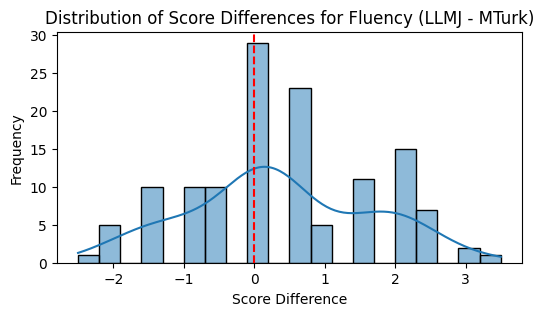

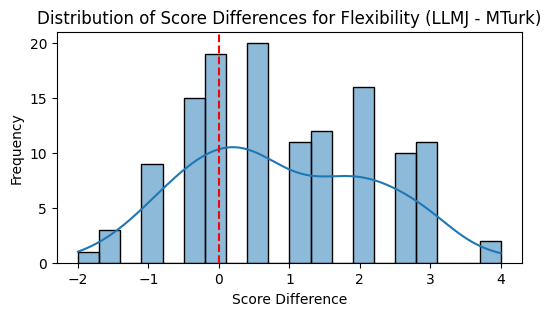

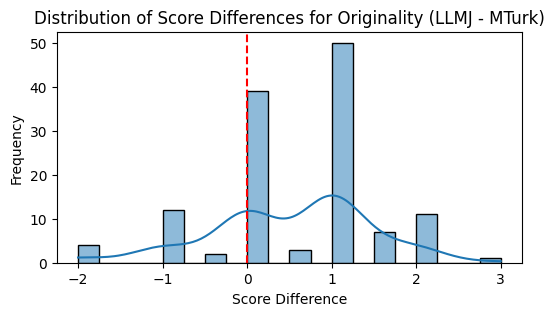

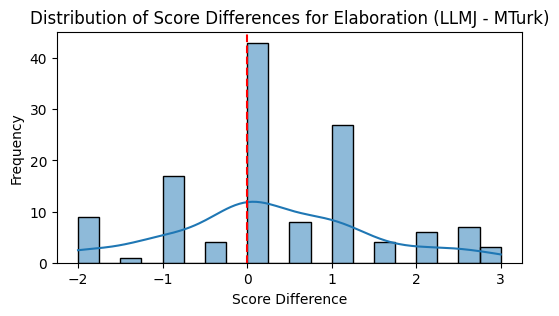

In [384]:
# compare score distrubition in llmj and mturk columns for fluency, flexibility, originality, elaboration
# plot the distribution of score differences (llmj - mturk) for each metric
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['fluency', 'flexibility', 'originality', 'elaboration']
for metric in metrics:
    plt.figure(figsize=(6, 3))
    sns.histplot(curr_llmj_input[f'{metric}_llmj'] - curr_llmj_input[f'{metric}_mturk'], bins=20, kde=True)
    plt.title(f'Distribution of Score Differences for {metric.capitalize()} (LLMJ - MTurk)')
    plt.xlabel('Score Difference')
    plt.ylabel('Frequency')
    plt.axvline(0, color='red', linestyle='--')
    plt.show()

### 2.6.2 Pairwise Accuracy

In [325]:
# llmj_demo_data[item['question_type']]

In [25]:
curr_llmj_input.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate',
       'Input.infer_cot_input', 'Input.infer_cot_pred', 'Input.rubric',
       'Answer.elaboration.1', 'Answer.elaboration.2', 'Answer.elaboration.3',
       'Answer.elaboration.4', 'Answer.elaboration.5', 'Answer.flexibility.1',
       'Answer.flexibility.2', 'Answer.flexibility.3', 'Answer.flexibility.4',
       'Answer.flexibility.5', 'Answer.fluency.1', 'Answer.fluency.2',
       'Answer.fluency.3', 'Answer.fluency.4', 'Answer.fluency.5',
       

In [744]:
pairwise_data = copy.deepcopy(
    curr_llmj_input[[
        'infer_cot_input', 'ttct_id', 'source_file', 'question_type', 'target',
        'fluency_mturk', 'fluency_llmj', 'flexibility_mturk', 'flexibility_llmj', 'originality_mturk', 'originality_llmj', 'elaboration_mturk', 'elaboration_llmj'
    ]].dropna()
)
pairwise_data = pairwise_data.groupby(['ttct_id']).agg({
    'infer_cot_input': 'first',
    'fluency_mturk': 'mean',
    'fluency_llmj': 'first',
    'flexibility_mturk': 'mean',
    'flexibility_llmj': 'first',
    'originality_mturk': 'mean',
    'originality_llmj': 'first',
    'elaboration_mturk': 'mean',
    'elaboration_llmj': 'first',
    'target': 'first',
    'source_file': 'first',
    'question_type': 'first'
})

fluency_reference = [llmj_demo_data[row['question_type']]['median']['fluency_score'] for _, row in pairwise_data.iterrows()]
flexibility_reference = [llmj_demo_data[row['question_type']]['median']['flexibility_score'] for _, row in pairwise_data.iterrows()]
originality_reference = [llmj_demo_data[row['question_type']]['median']['originality_score'] for _, row in pairwise_data.iterrows()]
elaboration_reference = [llmj_demo_data[row['question_type']]['median']['elaboration_score'] for _, row in pairwise_data.iterrows()]

pairwise_data['fluency_reference'] = fluency_reference
pairwise_data['flexibility_reference'] = flexibility_reference
pairwise_data['originality_reference'] = originality_reference
pairwise_data['elaboration_reference'] = elaboration_reference

def get_groundtruth(row, trait):
    if row[trait + '_mturk'] > row[trait + '_reference']:
        return 'A' if row['target'] == 'A' else 'B'
    elif row[trait + '_mturk'] < row[trait + '_reference']:
        return 'B' if row['target'] == 'A' else 'B'
    else:
        # print(1)
        return None

pairwise_data['fluency_true'] = pairwise_data.apply(lambda row: get_groundtruth(row, 'fluency'), axis=1)
pairwise_data['flexibility_true'] = pairwise_data.apply(lambda row: get_groundtruth(row, 'flexibility'), axis=1)
pairwise_data['originality_true'] = pairwise_data.apply(lambda row: get_groundtruth(row, 'originality'), axis=1)
pairwise_data['elaboration_true'] = pairwise_data.apply(lambda row: get_groundtruth(row, 'elaboration'), axis=1)
pairwise_data.head()

,infer_cot_input,fluency_mturk,fluency_llmj,flexibility_mturk,flexibility_llmj,originality_mturk,originality_llmj,elaboration_mturk,elaboration_llmj,target,source_file,question_type,fluency_reference,flexibility_reference,originality_reference,elaboration_reference,fluency_true,flexibility_true,originality_true,elaboration_true
ttct_id,,,,,,,,,,,,,,,,,,,,
0,"Common Problems Task. In this task, you will b...",3.000000,B,3.333333,B,3.333333,A,3.333333,A,A,Qwen2.5-7B-Instruct.csv,5_common_problems,3.0,4.0,2.0,3.0,None,B,A,A
1,"Common Problems Task. In this task, you will b...",3.333333,A,3.333333,B,2.666667,B,2.333333,A,A,Qwen2.5-7B-Instruct.csv,5_common_problems,3.0,4.0,2.0,3.0,A,B,A,B
2,"Common Problems Task. In this task, you will b...",3.000000,B,3.666667,B,2.666667,B,2.666667,A,A,Qwen2.5-7B-Instruct.csv,5_common_problems,3.0,4.0,2.0,3.0,None,B,A,B
3,What would happen if the world's deserts sudde...,3.333333,B,4.000000,B,3.000000,B,3.000000,B,B,Qwen2.5-7B-Instruct.csv,2_consequences,4.0,4.0,2.0,3.0,B,None,B,None
4,What would happen if plastic could biodegrade ...,2.666667,B,2.666667,B,3.000000,B,2.666667,B,B,Qwen2.5-7B-Instruct.csv,2_consequences,4.0,4.0,2.0,3.0,B,B,B,B


In [745]:
# calculate accuracy for each trait
for trait in ['fluency', 'flexibility', 'originality', 'elaboration']:
    tmp_data = pairwise_data[pairwise_data[trait + '_true'].notnull()]
    correct = tmp_data.apply(lambda row: row[trait + '_llmj'] == row[trait + '_true'], axis=1).sum()
    total = tmp_data.shape[0]
    accuracy = correct / total
    print('{} accuracy: {:.4f}'.format(trait, accuracy))

fluency accuracy: 0.7241
flexibility accuracy: 0.6000
originality accuracy: 0.7586
elaboration accuracy: 0.7778


In [746]:
performance_table = {
    'gpt41_low': {
        'fluency': 0.7241,
        'flexibility': 0.6000,
        'originality': 0.7586,
        'elaboration': 0.7778
    },
    'qwen72_low': {
        'fluency': 0.4545,
        'flexibility': 0.3529,
        'originality': 0.5882,
        'elaboration': 0.6129
    },
    'gpt41_high': {
        'fluency': 0.5000,
        'flexibility': 0.3929,
        'originality': 0.6000,
        'elaboration': 0.6538
    },
    'qwen72_high': {
        'fluency': 0.5294,
        'flexibility': 0.4722,
        'originality': 0.6944,
        'elaboration': 0.5455
    },
    'gpt41_median': {
        'fluency': 0.5000,
        'flexibility': 0.4706,
        'originality': 0.6176,
        'elaboration': 0.5161
    },
    'qwen72_median': {
        'fluency': 0.5000,
        'flexibility': 0.4118,
        'originality': 0.6364,
        'elaboration': 0.5806
    }
}
performance_table = pd.DataFrame(performance_table)
performance_table['overall_gpt41'] = performance_table[[col for col in performance_table.columns if 'gpt41' in col]].mean(axis=1)
performance_table['overall_qwen72'] = performance_table[[col for col in performance_table.columns if 'qwen72' in col]].mean(axis=1)
performance_table

,gpt41_low,qwen72_low,gpt41_high,qwen72_high,gpt41_median,qwen72_median,overall_gpt41,overall_qwen72
fluency,0.7241,0.4545,0.5000,0.5294,0.5000,0.5000,0.574700,0.494633
flexibility,0.6000,0.3529,0.3929,0.4722,0.4706,0.4118,0.487833,0.412300
originality,0.7586,0.5882,0.6000,0.6944,0.6176,0.6364,0.658733,0.639667
elaboration,0.7778,0.6129,0.6538,0.5455,0.5161,0.5806,0.649233,0.579667


In [747]:
# llmj_demo_data['1_unusual_uses']['median']

In [748]:
# # collect pairwise data 

# pairwise_data = []
# for i, row in curr_llmj_input.iterrows():
#     reference_dp = llmj_demo_data[row['question_type']]['median']
#     curr_dp = {
#         "question": row['infer_cot_input'],
#         "answer": row['infer_cot_pred'],
#         "fluency_score": row['fluency_llmj'],
#         "flexibility_score": row['flexibility_llmj'],
#         "originality_score": row['originality_llmj'],
#         "elaboration_score": row['elaboration_llmj']
#     }
#     pairwise_data.append((reference_dp, curr_dp))
# len(pairwise_data)

In [749]:
# {'original_idx': 0,
#  'llm_judge': 5,
#  'human_anno_0': 2,
#  'question_type': '6_improvement',
#  'llm_output': ".\n    Start with what's most obvious to you. What's the first thing that comes to mind when you think of Post-it Notes?\n    Maybe they're too small, too expensive, or too hard to peel off. Maybe they don't have enough adhesive, get stuck to each other, or curl up at the edges. Write down everything you think of, even if it seems silly.\n    Now, ask yourself some questions:\n  • Can the design be altered? Post-it Notes could be designed to be triangular or heart-shaped instead of rectangular.\n  • Can the material be changed? Maybe Post-it Notes could be made of a fabric that tears more easily, a biodegradable material, or a glow-in-the-dark paper for when you're working in the dark.\n  • What features could be added? Consider perforations between notes, an odor for when a note is left too long in one place (to alert you to its presence), or built-in lines for taking especially neat notes.\n  • Can it serve more purposes? Perhaps Post-it Notes could have flip sides with two different colors or patterns on each side.\n  • Post-its come in a limited range of colors (usually off-white, pale yellow, and neon colors). Imagine a whole spectrum of pastel colors, tie-dye patterns, metallic finishes, or even ones with glitter embedded for a little extra pizzazz.\n  • How can Post-it Notes become more technologically savvy? They could be RFID (radio-frequency identification) tags that can be tracked through a system, or come with QR (quick-response) codes that link to information when scanned with a smartphone.\n  • Can you make Post-its more useful for particular situations? Say, waterproof Post-it Notes for the shower, or Post-its that disappear after a certain time for tasks with deadlines.\n  • Can you change the usage context? Maybe Post-it Notes could come attached to a small notebook, have built-in rulers, or be made to attach neatly to computer screens (rather than destroying the screen's surface).\n  • Think more broadly. What if Post-it Notes were used as party decorations, came in holiday-themed designs, or were an interactive game (like stickers)?\n    Think outside the box and get abstract. How would you innovate Post-it Notes if no limitations",
#  'human_anno_1': 2,
#  'human_anno_2': 4,
#  'human_median': 2}

In [750]:
traits = ['fluency', 'flexibility', 'originality', 'elaboration']
all_ttct_data_raw = {
    trait: {} for trait in traits
}
counter = 0

if setting == 'pairwise':
    ref_key = 'median'
elif setting == 'pairwise_low':
    ref_key = 'lowest'
elif setting == 'pairwise_high':
    ref_key = 'highest'
else:
    ref_key = 'median'

for i, row in curr_llmj_input.iterrows():
    output = row['infer_cot_pred']
    question_type = row['question_type']
    for trait in traits:
        llm_pref = row[f'{trait}_llmj'] # A or B
        if pd.isna(llm_pref): continue 

        human_score = row[f'{trait}_mturk']        
        ref_score = llmj_demo_data[question_type][ref_key][f'{trait}_score']
        
        if human_score > ref_score:
            human_pref = 'A' if row['target'] == 'A' else 'B'
        elif human_score < ref_score:
            human_pref = 'B' if row['target'] == 'A' else 'A'
        else:
            human_pref = 'T' # tie

        if output not in all_ttct_data_raw[trait]:
            all_ttct_data_raw[trait][output] = {
                'original_idx': counter,
                'llm_judge': llm_pref,
                'human_anno_0': human_pref,
                'question_type': question_type,
                'llm_output': output
            }
            counter += 1
        else:
            if 'human_anno_1' not in all_ttct_data_raw[trait][output]:
                all_ttct_data_raw[trait][output]['human_anno_1'] = human_pref
            elif 'human_anno_2' not in all_ttct_data_raw[trait][output]:
                all_ttct_data_raw[trait][output]['human_anno_2'] = human_pref
            else:
                print("More than 3 annotators found!")
                break 

all_ttct_data = {}
for trait in traits:
    all_ttct_data[trait] = list(all_ttct_data_raw[trait].values())
    print(f"Trait: {trait}, Number of data points: {len(all_ttct_data[trait])}")
    # for dp in all_ttct_data[trait]:
    #     dp['human_median'] = int(np.median([dp[f'human_anno_{i}'] for i in range(3) if f'human_anno_{i}' in dp]))

Trait: fluency, Number of data points: 36
Trait: flexibility, Number of data points: 36
Trait: originality, Number of data points: 36
Trait: elaboration, Number of data points: 36


In [751]:
# write_json(
#     all_ttct_data,
#     f'../data/mturk_anno/ttct/v1.1_llmj_output/replacement_test/{curr_llmj}_{setting}.json'
# )

In [752]:
# load all pairwise data and calculate accuracy for each trait
all_ttct_data = {trait: [] for trait in traits}
curr_llmj = 'gpt41'
for tmp_setting in ['pairwise', 'pairwise_low', 'pairwise_high']:
    tmp_ttct_data = load_json(
        f'../data/mturk_anno/ttct/v1.1_llmj_output/replacement_test/{curr_llmj}_{tmp_setting}.json'
    )
    for trait in traits:
        all_ttct_data[trait].extend(tmp_ttct_data[trait])

In [754]:
for trait in traits:
    print(f"Trait: {trait}")
    t_stats, p_vals, rejects = test_replacement(all_ttct_data[trait], accuracy_metric, epsilon = 0.15)
    print("\n")

Trait: fluency
Number of data points (n): 112, degrees of freedom (df): 111
Before Benjamini-Yekutieli adjustment:
[t critical (alpha=0.05, df=111): -1.659]
Annotator 0: t = 0.034, p(one-sided) = 0.5135, reject H0 = False
Annotator 1: t = -0.133, p(one-sided) = 0.4471, reject H0 = False
Annotator 2: t = -1.571, p(one-sided) = 0.05951, reject H0 = False

After Benjamini-Yekutieli adjustment:
Annotator 0: p = 0.5135, p_adj(BY) = 0.1091, reject H0 = False
Annotator 1: p = 0.4471, p_adj(BY) = 0.1091, reject H0 = False
Annotator 2: p = 0.0595, p_adj(BY) = 0.1091, reject H0 = False


Trait: flexibility
Number of data points (n): 112, degrees of freedom (df): 111
Before Benjamini-Yekutieli adjustment:
[t critical (alpha=0.05, df=111): -1.659]
Annotator 0: t = -0.938, p(one-sided) = 0.1752, reject H0 = False
Annotator 1: t = -1.118, p(one-sided) = 0.1331, reject H0 = False
Annotator 2: t = -0.892, p(one-sided) = 0.1872, reject H0 = False

After Benjamini-Yekutieli adjustment:
Annotator 0: p = 

### 2.6.3 Replacement Test and Kappa (direct prediction)

In [385]:
curr_llmj_input.columns

Index(['HITId', 'HITTypeId', 'Title', 'Description', 'Keywords', 'Reward',
       'CreationTime', 'MaxAssignments', 'RequesterAnnotation',
       'AssignmentDurationInSeconds', 'AutoApprovalDelayInSeconds',
       'Expiration', 'NumberOfSimilarHITs', 'LifetimeInSeconds',
       'AssignmentId', 'WorkerId', 'AssignmentStatus', 'AcceptTime',
       'SubmitTime', 'AutoApprovalTime', 'ApprovalTime', 'RejectionTime',
       'RequesterFeedback', 'WorkTimeInSeconds', 'LifetimeApprovalRate',
       'Last30DaysApprovalRate', 'Last7DaysApprovalRate',
       'Input.infer_cot_input', 'Input.infer_cot_pred', 'Input.rubric',
       'Answer.elaboration.1', 'Answer.elaboration.2', 'Answer.elaboration.3',
       'Answer.elaboration.4', 'Answer.elaboration.5', 'Answer.flexibility.1',
       'Answer.flexibility.2', 'Answer.flexibility.3', 'Answer.flexibility.4',
       'Answer.flexibility.5', 'Answer.fluency.1', 'Answer.fluency.2',
       'Answer.fluency.3', 'Answer.fluency.4', 'Answer.fluency.5',
       

In [386]:
# aut_anno_data[0]

In [387]:
traits = ['fluency', 'flexibility', 'originality', 'elaboration']
all_ttct_data_raw = {
    trait: {} for trait in traits
}
counter = 0
for i, row in curr_llmj_input.iterrows():
    output = row['infer_cot_pred']
    question_type = row['question_type']
    for trait in traits:
        human_score = row[f'{trait}_mturk']
        # print(f"Question Type: {question_type}, Trait: {trait}, Score: {score}, Output: {output}")
        llm_score = row[f'{trait}_llmj']
        if pd.isna(llm_score): continue 
        if output not in all_ttct_data_raw[trait]:
            all_ttct_data_raw[trait][output] = {
                'original_idx': counter,
                'llm_judge': int(llm_score),
                'human_anno_0': human_score,
                'question_type': question_type,
                'llm_output': output
            }
            counter += 1
        else:
            if 'human_anno_1' not in all_ttct_data_raw[trait][output]:
                all_ttct_data_raw[trait][output]['human_anno_1'] = human_score
            elif 'human_anno_2' not in all_ttct_data_raw[trait][output]:
                all_ttct_data_raw[trait][output]['human_anno_2'] = human_score
                # sort human scores
                human_scores = sorted([
                    all_ttct_data_raw[trait][output][f'human_anno_{i}'] for i in range(3)
                ])
                for i in range(3):
                    all_ttct_data_raw[trait][output][f'human_anno_{i}'] = human_scores[i]
            else:
                print("More than 3 annotators found!")
                break 


all_ttct_data = {}
for trait in traits:
    all_ttct_data[trait] = list(all_ttct_data_raw[trait].values())
    print(f"Trait: {trait}, Number of data points: {len(all_ttct_data[trait])}")
    for dp in all_ttct_data[trait]:
        dp['human_median'] = int(np.median([dp[f'human_anno_{i}'] for i in range(3) if f'human_anno_{i}' in dp]))
        dp['human_mean'] = int(np.mean([dp[f'human_anno_{i}'] for i in range(3) if f'human_anno_{i}' in dp]))
        # dp['human_majority'] = int(stats.mode([dp[f'human_anno_{i}'] for i in range(3) if f'human_anno_{i}' in dp])[0][0])

Trait: fluency, Number of data points: 43
Trait: flexibility, Number of data points: 43
Trait: originality, Number of data points: 43
Trait: elaboration, Number of data points: 43


In [388]:
all_ttct_data['fluency'][0]

{'original_idx': 0,
 'llm_judge': 3,
 'human_anno_0': 2,
 'question_type': '6_improvement',
 'llm_output': ".\n    Start with what's most obvious to you. What's the first thing that comes to mind when you think of Post-it Notes?\n    Maybe they're too small, too expensive, or too hard to peel off. Maybe they don't have enough adhesive, get stuck to each other, or curl up at the edges. Write down everything you think of, even if it seems silly.\n    Now, ask yourself some questions:\n  • Can the design be altered? Post-it Notes could be designed to be triangular or heart-shaped instead of rectangular.\n  • Can the material be changed? Maybe Post-it Notes could be made of a fabric that tears more easily, a biodegradable material, or a glow-in-the-dark paper for when you're working in the dark.\n  • What features could be added? Consider perforations between notes, an odor for when a note is left too long in one place (to alert you to its presence), or built-in lines for taking especially

In [389]:
# t_stats, p_vals, rejects = test_replacement(all_ttct_data['fluency'], distance_metric, epsilon = 0.15)

In [390]:
for trait in traits:
    if trait == 'originality': continue
    print(f"Trait: {trait}")
    t_stats, p_vals, rejects = test_replacement(all_ttct_data[trait], distance_metric, epsilon = 0.15)
    print("\n")

Trait: fluency
Number of data points (n): 43, degrees of freedom (df): 42
Before Benjamini-Yekutieli adjustment:
[t critical (alpha=0.05, df=42): -1.682]
Annotator 0: t = -2.675, p(one-sided) = 0.005307, reject H0 = True
Annotator 1: t = 0.945, p(one-sided) = 0.8249, reject H0 = False
Annotator 2: t = -2.721, p(one-sided) = 0.004712, reject H0 = True


Trait: flexibility
Number of data points (n): 43, degrees of freedom (df): 42
Before Benjamini-Yekutieli adjustment:
[t critical (alpha=0.05, df=42): -1.682]
Annotator 0: t = -2.774, p(one-sided) = 0.004118, reject H0 = True
Annotator 1: t = 1.572, p(one-sided) = 0.9382, reject H0 = False
Annotator 2: t = -2.518, p(one-sided) = 0.007844, reject H0 = True


Trait: elaboration
Number of data points (n): 43, degrees of freedom (df): 42
Before Benjamini-Yekutieli adjustment:
[t critical (alpha=0.05, df=42): -1.682]
Annotator 0: t = -2.125, p(one-sided) = 0.01977, reject H0 = True
Annotator 1: t = 1.865, p(one-sided) = 0.9654, reject H0 = Fal

In [124]:
# weighted cohen kappa for each trait
from sklearn.metrics import cohen_kappa_score
for trait in traits:
    weighted_kappa = cohen_kappa_score(
        [dp['llm_judge'] for dp in all_ttct_data[trait]],
        [dp['human_median'] for dp in all_ttct_data[trait]],
        weights='quadratic'
    )
    print(f"Kappa ({trait}): {weighted_kappa:.2f}")

Kappa (fluency): 0.38
Kappa (flexibility): 0.05
Kappa (originality): 0.49
Kappa (elaboration): 0.06
